# Library

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 16.7 MB/s eta 0:00:00


In [ ]:
!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 39.8 MB/s eta 0:00:00


In [ ]:
# Import libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import statsmodels.api as sm
import optuna
from numpy import mean
from numpy import std
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from scipy.spatial import distance_matrix
from sklearn.neighbors import NearestNeighbors
from libpysal.weights import KNN
from esda.moran import Moran
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from optuna.samplers import TPESampler
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import StratifiedKFold, cross_val_score
import matplotlib.patches as patches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors

# Import Data

In [ ]:
# 1) Baca Excel (sheet pertama)
df = pd.read_excel("/content/Data Skripsi Full.xlsx")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1583 entries, 0 to 1582
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Longitude       1583 non-null   float64
 1   Latitude        1583 non-null   float64
 2   periode         1583 non-null   object 
 3   id_wpp_tangkap  1583 non-null   int64  
 4   so              1583 non-null   float64
 5   thetao          1583 non-null   float64
 6   zos             1583 non-null   float64
 7   uo              1583 non-null   float64
 8   vo              1583 non-null   float64
 9   chl             1583 non-null   float64
 10  o2              1583 non-null   float64
 11  mlotst          1583 non-null   float64
 12  nppv            1583 non-null   float64
 13  Kecepatan       1583 non-null   float64
 14  cpue            1583 non-null   float64
dtypes: float64(13), int64(1), object(1)
memory usage: 185.6+ KB


In [ ]:
WPP = pd.read_csv("/content/WPP 572_573.csv", sep =';')

In [ ]:
WPP.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 610 entries, 0 to 609
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         610 non-null    int64  
 1   left       610 non-null    float64
 2   top        610 non-null    float64
 3   right      610 non-null    float64
 4   bottom     610 non-null    float64
 5   row_index  610 non-null    int64  
 6   col_index  610 non-null    int64  
 7   Longitude  610 non-null    float64
 8   Latitude   610 non-null    float64
dtypes: float64(6), int64(3)
memory usage: 43.0 KB


## Missing value


In [ ]:
df.isna().sum()

,0
Longitude,0
Latitude,0
periode,0
id_wpp_tangkap,0
so,0
thetao,0
zos,0
uo,0
vo,0
chl,0


## Statistik Deskriptif

In [ ]:
df.describe()

,Longitude,Latitude,id_wpp_tangkap,so,thetao,zos,uo,vo,chl,o2,mlotst,nppv,Kecepatan,cpue
count,1583.000000,1583.000000,1583.00000,1583.000000,1583.000000,1583.000000,1583.000000,1583.000000,1583.000000,1583.000000,1583.000000,1583.000000,1583.000000,1583.000000
mean,107.438566,-6.699779,572.55338,33.748653,28.665461,0.512219,-0.148165,-0.025906,0.237774,202.593894,19.631813,13.192651,0.221479,9.460825
std,9.551575,4.733729,0.49730,0.529785,1.016045,0.123111,0.221723,0.077974,0.306409,3.883281,6.623713,20.651308,0.169693,17.319075
min,92.250000,-13.750000,572.00000,31.114102,25.918408,0.202413,-0.768959,-0.607629,0.081074,178.812339,10.167482,1.421484,0.001650,0.000072
25%,98.750000,-10.250000,572.00000,33.503919,27.750721,0.443752,-0.338380,-0.059650,0.097566,199.831996,14.537267,2.926775,0.079997,0.423073
50%,106.750000,-8.250000,573.00000,33.787042,28.890697,0.525577,-0.089148,-0.022437,0.117965,200.830212,17.921148,4.364353,0.159137,1.843771
75%,116.250000,-3.250000,573.00000,34.089295,29.334334,0.585140,0.030773,0.020959,0.239142,204.961210,23.394699,13.523554,0.348778,8.691877
max,125.750000,5.750000,573.00000,34.961383,30.496962,0.773223,0.344260,0.263403,3.971957,219.270573,43.532678,215.510166,0.769938,99.604130


## Eksplorasi Scatter Plot

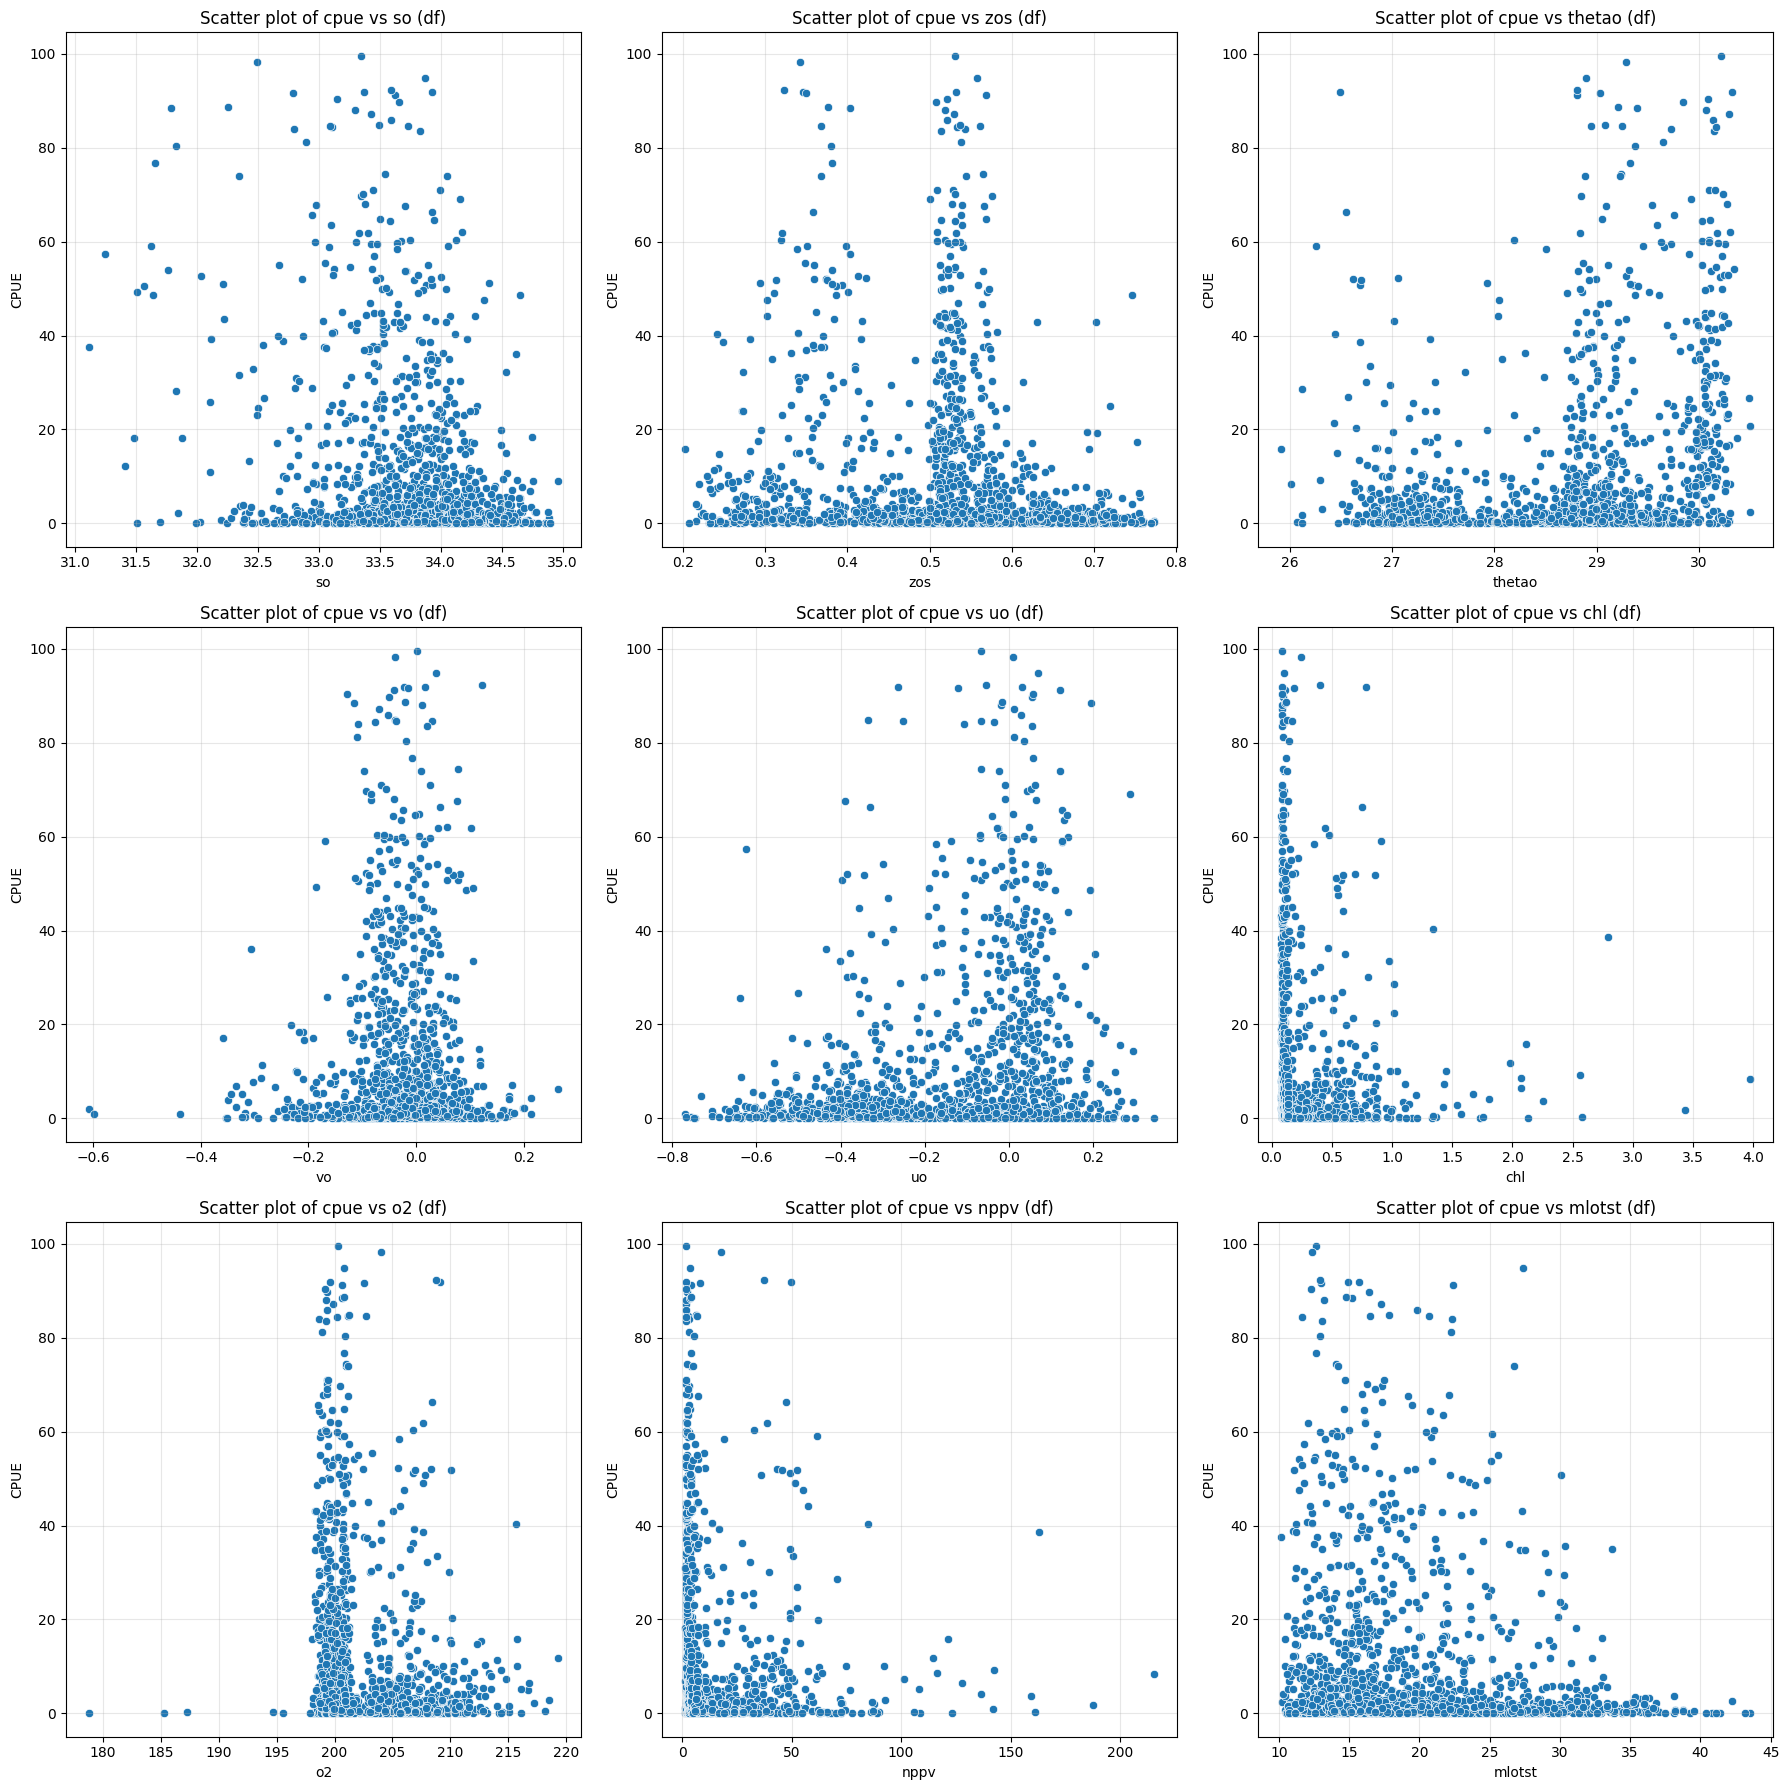

In [ ]:
environmental_vars = ['so', 'zos', 'thetao', 'vo', 'uo', 'chl', 'o2', 'nppv', 'mlotst']

plt.figure(figsize=(18, 18)) # Adjust figure size to accommodate more plots
for i, var in enumerate(environmental_vars):
    plt.subplot(3, 3, i + 1) # Arrange plots in a 3x3 grid
    sns.scatterplot(data=df, x=var, y='cpue')
    plt.title(f'Scatter plot of cpue vs {var} (df)')
    plt.xlabel(var)
    plt.ylabel('CPUE')
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Eksplorasi Boxplot

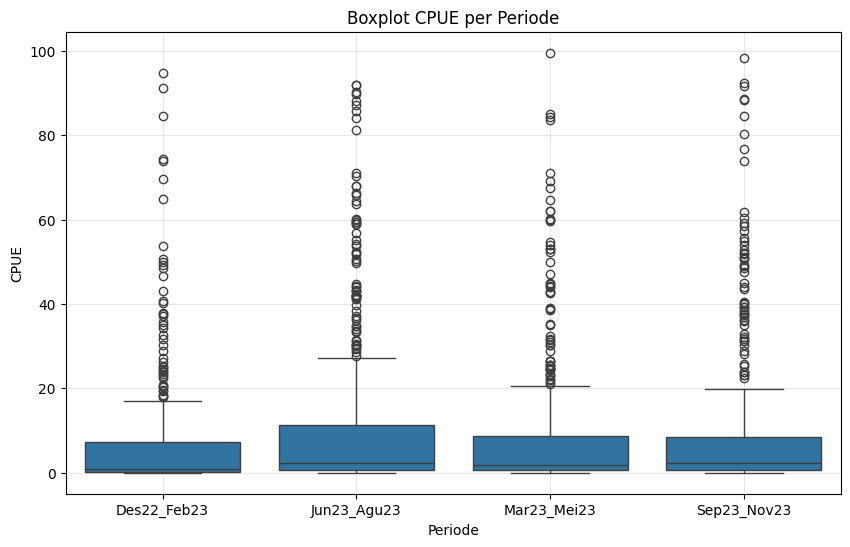

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='periode', y='cpue')
plt.title('Boxplot CPUE per Periode')
plt.xlabel('Periode')
plt.ylabel('CPUE')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
df['cpue_transformed'] = np.log1p(df['cpue'])
df.head()

,Longitude,Latitude,periode,id_wpp_tangkap,so,thetao,zos,uo,vo,chl,o2,mlotst,nppv,Kecepatan,cpue,cpue_transformed
0,92.25,2.75,Des22_Feb23,572,33.962241,28.953252,0.536405,-0.141075,0.010665,0.107391,201.216329,16.318926,4.061032,0.141477,18.318995,2.961089
1,92.25,3.25,Des22_Feb23,572,33.930846,29.062583,0.542085,-0.158578,0.032903,0.100964,201.194042,16.306210,3.584600,0.161955,15.934011,2.829324
2,92.75,1.25,Des22_Feb23,572,34.041546,28.774475,0.531435,0.012558,-0.054329,0.126704,201.143570,18.354906,5.410838,0.055761,9.870458,2.386049
3,93.25,0.75,Des22_Feb23,572,34.077844,28.788351,0.535326,0.112574,-0.022284,0.115972,201.043730,23.588266,4.681760,0.114758,30.287245,3.443210
4,93.25,1.25,Des22_Feb23,572,34.020678,28.805373,0.535775,0.023030,-0.028128,0.117965,201.124162,19.194165,4.774173,0.036353,18.029441,2.945987


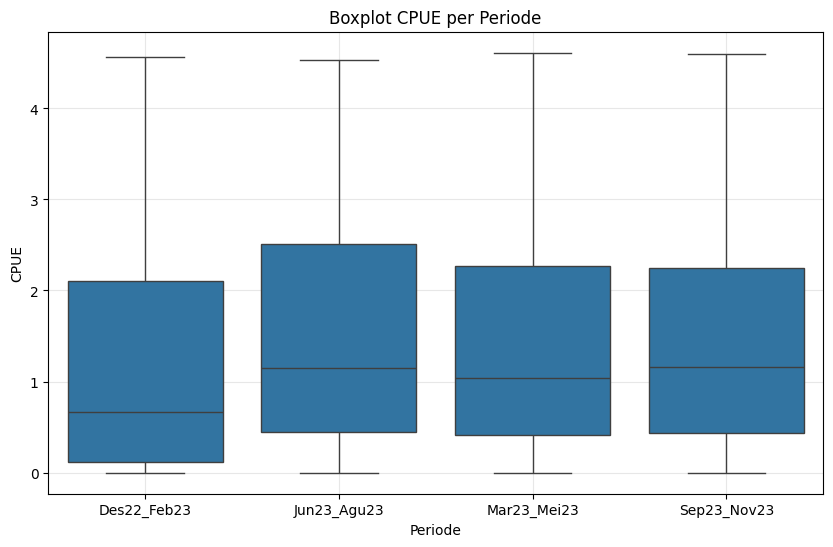

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='periode', y='cpue_transformed')
plt.title('Boxplot CPUE per Periode')
plt.xlabel('Periode')
plt.ylabel('CPUE')
plt.grid(alpha=0.3)
plt.show()

# Maret 2023 - Mei 2023

In [ ]:
# 1) Baca Excel (sheet pertama)
data = pd.read_excel("/content/Maret 2023 -Mei 2023.xlsx")

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 445 entries, 0 to 448
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Longitude       445 non-null    float64
 1   Latitude        445 non-null    float64
 2   periode         445 non-null    object 
 3   id_wpp_tangkap  445 non-null    int64  
 4   cpue            445 non-null    float64
 5   n_trip          445 non-null    int64  
 6   so              445 non-null    float64
 7   thetao          445 non-null    float64
 8   zos             445 non-null    float64
 9   uo              445 non-null    float64
 10  vo              445 non-null    float64
 11  chl             445 non-null    float64
 12  o2              445 non-null    float64
 13  mlotst          445 non-null    float64
 14  nppv            445 non-null    float64
 15  Kecepatan       445 non-null    float64
 16  cpue_new        445 non-null    float64
dtypes: float64(14), int64(2), object(1)
memo

In [ ]:
data.describe()

,Longitude,Latitude,id_wpp_tangkap,cpue,n_trip,so,thetao,zos,uo,vo,chl,o2,mlotst,nppv,Kecepatan,cpue_new
count,445.000000,445.000000,445.000000,445.000000,445.000000,445.000000,445.000000,445.000000,445.000000,445.000000,445.000000,445.000000,445.000000,445.000000,445.000000,445.000000
mean,107.363483,-6.694944,572.543820,12.435013,22.116854,33.595124,29.440158,0.568536,-0.097782,-0.033838,0.106719,200.015982,17.474418,3.743409,0.175416,8.593787
std,9.537092,4.733649,0.498637,45.577067,64.150301,0.470596,0.427230,0.072567,0.179893,0.070038,0.032058,0.711201,4.277925,2.960687,0.130986,15.491544
min,92.250000,-13.750000,572.000000,0.000072,1.000000,31.510632,28.402698,0.485459,-0.503476,-0.438268,0.084667,198.614255,10.180868,1.421484,0.001650,0.000072
25%,98.750000,-10.250000,572.000000,0.514649,3.000000,33.384028,29.123593,0.513316,-0.241266,-0.061276,0.092308,199.602948,14.849516,2.379541,0.067109,0.514649
50%,106.250000,-8.250000,573.000000,1.811713,7.000000,33.643690,29.315934,0.535560,-0.048903,-0.031768,0.097687,199.918557,16.670737,2.920581,0.137556,1.811713
75%,116.250000,-3.250000,573.000000,8.807495,21.000000,33.906869,29.758663,0.611551,0.041149,0.002752,0.108266,200.263147,19.468267,3.836866,0.267962,8.620704
max,125.750000,5.750000,573.000000,710.938808,983.000000,34.663700,30.492773,0.769329,0.295651,0.162353,0.454733,203.631064,36.620800,32.026225,0.571486,99.604130


## Eksplorasi Scatter Plot

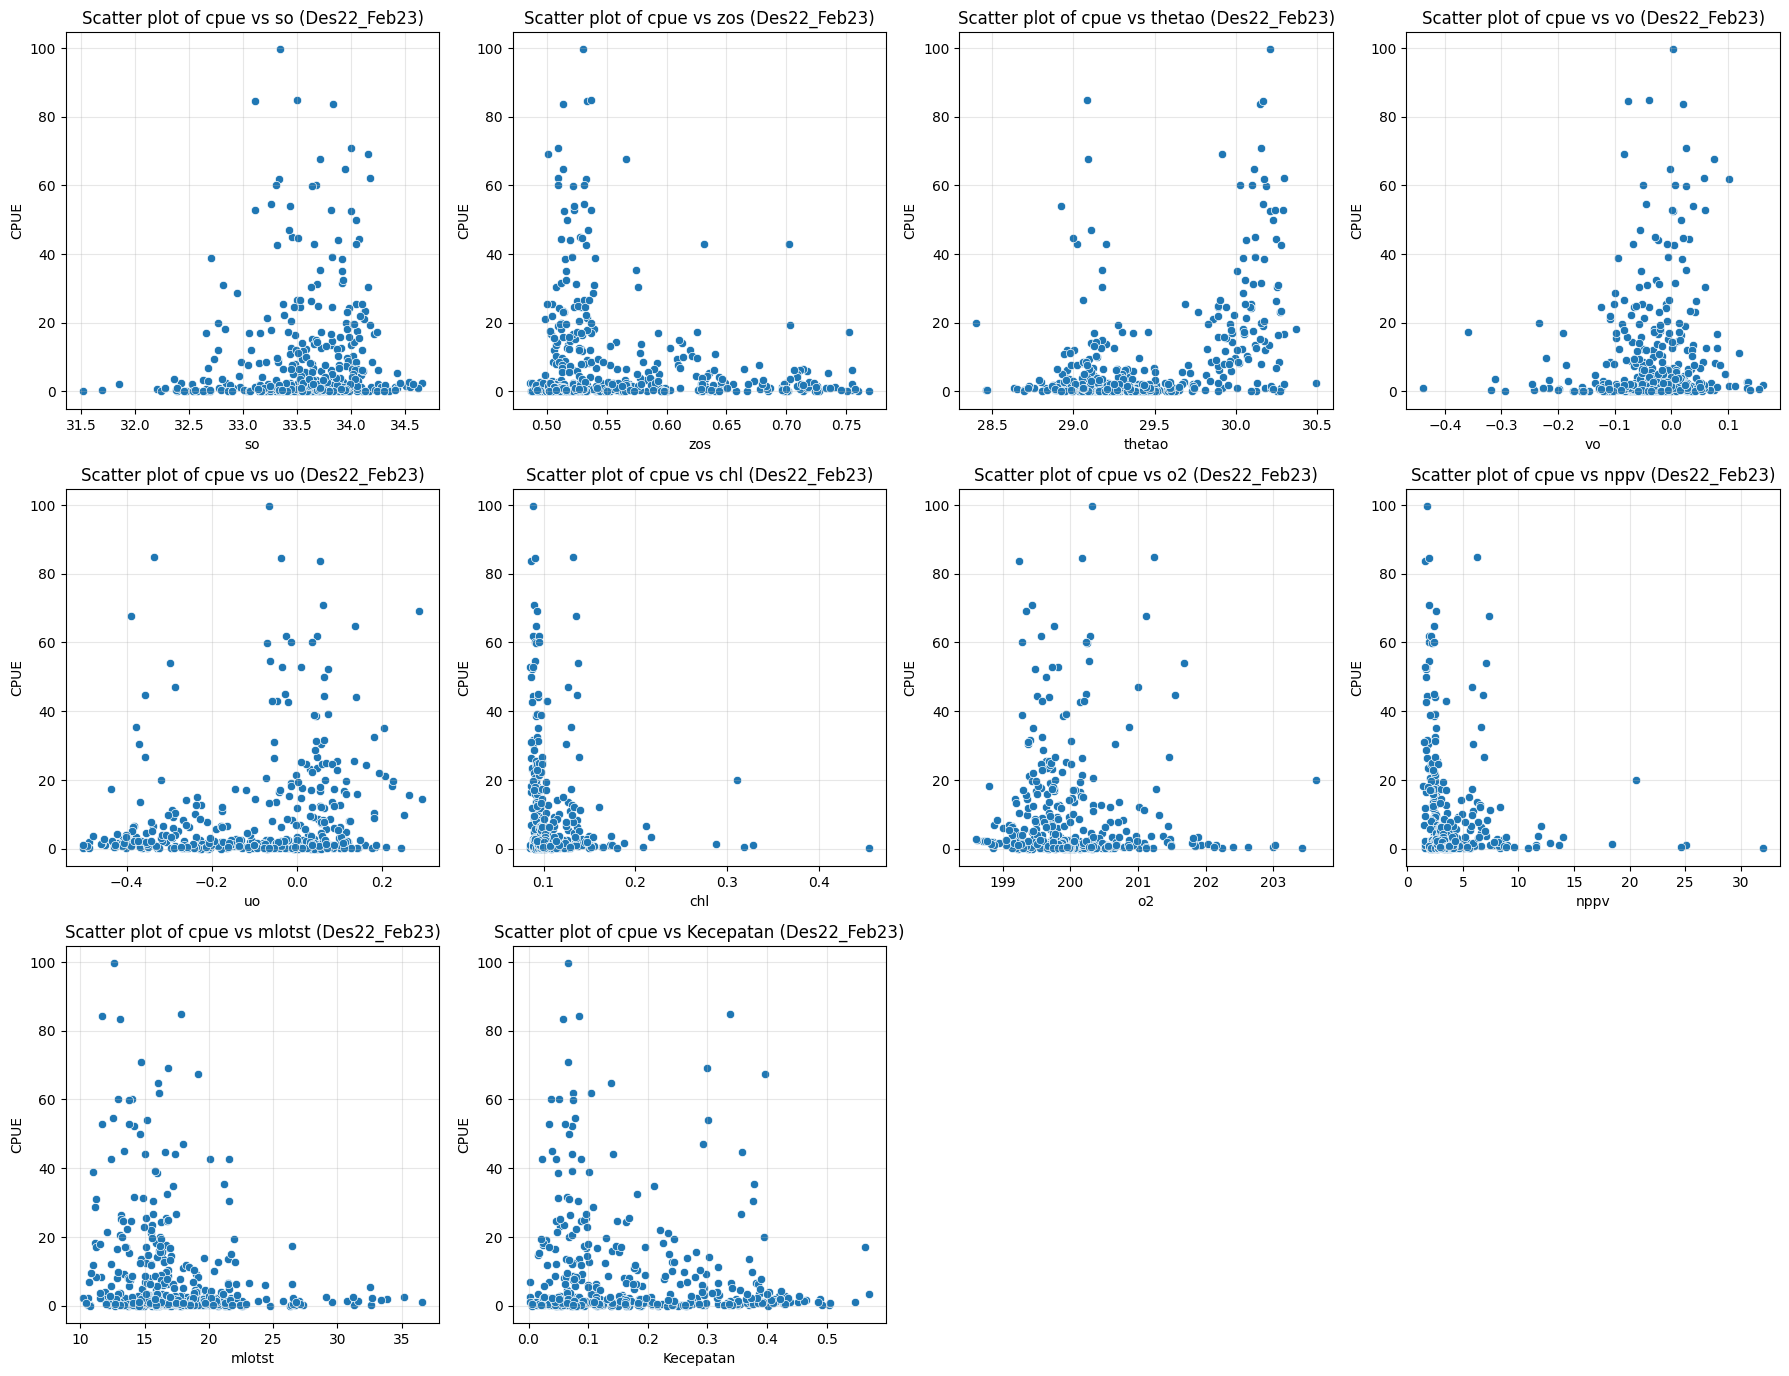

In [ ]:
environmental_vars = ['so', 'zos', 'thetao', 'vo', 'uo', 'chl', 'o2', 'nppv', 'mlotst', 'Kecepatan']

plt.figure(figsize=(18, 18)) # Adjust figure size to accommodate more plots
for i, var in enumerate(environmental_vars):
    plt.subplot(4, 4, i + 1) # Arrange plots in a 3x3 grid
    sns.scatterplot(data=data, x=var, y='cpue_new')
    plt.title(f'Scatter plot of cpue vs {var} (Des22_Feb23)')
    plt.xlabel(var)
    plt.ylabel('CPUE')
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Eksplorasi Peta Spasial

In [ ]:
cpue_mar2 = pd.merge(
    WPP,
    data[['Longitude', 'Latitude', 'cpue_new']],
    on=['Longitude', 'Latitude'],
    how='left'
)

In [ ]:
cpue_mar2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 610 entries, 0 to 609
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         610 non-null    int64  
 1   left       610 non-null    float64
 2   top        610 non-null    float64
 3   right      610 non-null    float64
 4   bottom     610 non-null    float64
 5   row_index  610 non-null    int64  
 6   col_index  610 non-null    int64  
 7   Longitude  610 non-null    float64
 8   Latitude   610 non-null    float64
 9   cpue_new   445 non-null    float64
dtypes: float64(7), int64(3)
memory usage: 47.8 KB


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


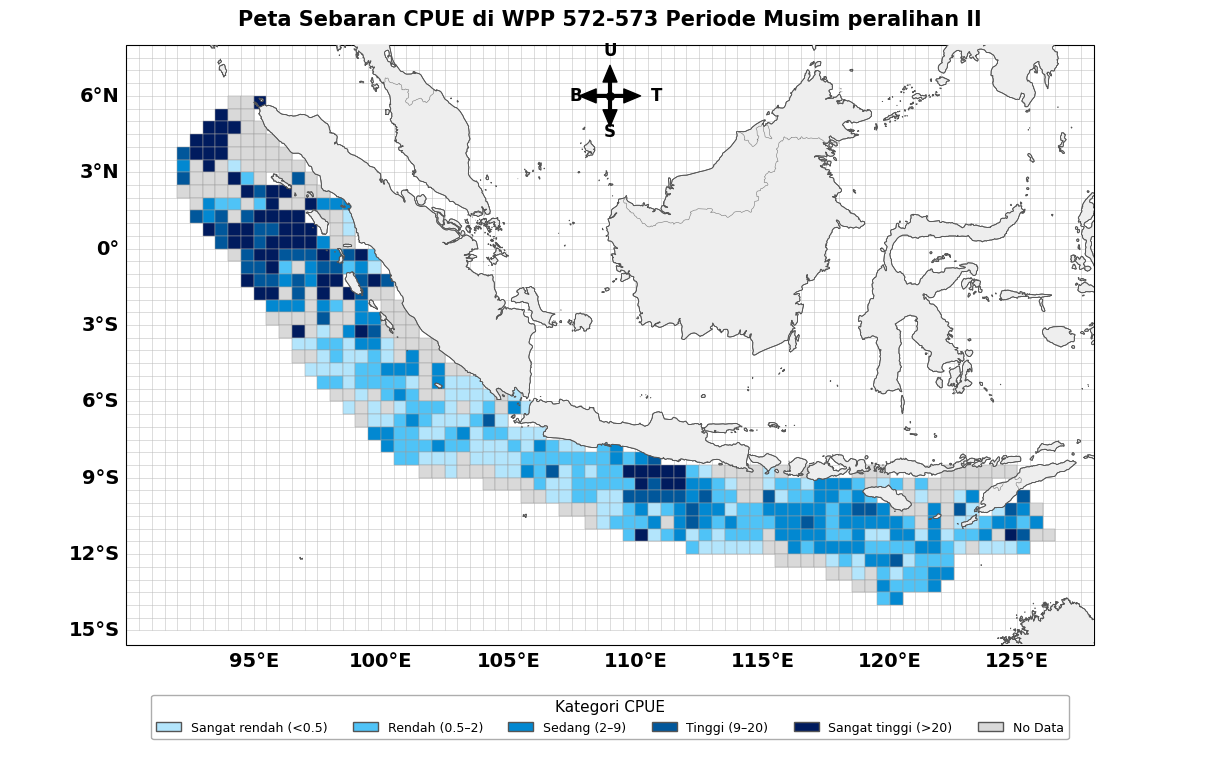

In [ ]:
# =========================
# 1. PARAMETER
# =========================
grid_size = 0.5

lon_min, lon_max = 90, 128
lat_min, lat_max = -15, 8

plot_data = cpue_mar2.copy()

plot_data['cpue_new'] = pd.to_numeric(
    plot_data['cpue_new'],
    errors='coerce'
)

# =========================
# 2. KATEGORI CPUE + NO DATA
# =========================
bins = [0, 0.5, 2, 9, 20, 100]

labels = [
    'Sangat rendah (<0.5)',
    'Rendah (0.5–2)',
    'Sedang (2–9)',
    'Tinggi (9–20)',
    'Sangat tinggi (>20)'
]

plot_data['kategori_cpue'] = pd.cut(
    plot_data['cpue_new'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

plot_data['kategori_cpue'] = (
    plot_data['kategori_cpue']
    .cat.add_categories(['No Data'])
)

plot_data['kategori_cpue'] = (
    plot_data['kategori_cpue']
    .fillna('No Data')
)

# =========================
# 3. WARNA
# =========================
colors_cpue = {
    'Sangat rendah (<0.5)': '#B3E5FC',
    'Rendah (0.5–2)': '#4FC3F7',
    'Sedang (2–9)': '#0288D1',
    'Tinggi (9–20)': '#01579B',
    'Sangat tinggi (>20)': '#001B5E',
    'No Data': '#d9d9d9'
}

# =========================
# 4. FIGURE
# =========================
fig = plt.figure(figsize=(15, 8))

# Peta utama
ax = fig.add_axes(
    [0.05, 0.15, 0.90, 0.75],
    projection=ccrs.PlateCarree()
)

# Legend horizontal bawah
legend_ax = fig.add_axes([0.10, 0.02, 0.80, 0.08])
legend_ax.axis('off')

ax.set_extent([
    lon_min,
    lon_max,
    lat_min,
    lat_max
])

ax.set_facecolor('#ffffff')

# =========================
# 5. GRID 0.5 DERAJAT
# =========================
for lon in np.arange(
    lon_min,
    lon_max + grid_size,
    grid_size
):
    ax.plot(
        [lon, lon],
        [lat_min, lat_max],
        color='#bdbdbd',
        linewidth=0.45,
        alpha=0.8,
        transform=ccrs.PlateCarree(),
        zorder=1
    )

for lat in np.arange(
    lat_min,
    lat_max + grid_size,
    grid_size
):
    ax.plot(
        [lon_min, lon_max],
        [lat, lat],
        color='#bdbdbd',
        linewidth=0.45,
        alpha=0.8,
        transform=ccrs.PlateCarree(),
        zorder=1
    )

# =========================
# 6. PLOT GRID CPUE
# =========================
for _, row in plot_data.iterrows():

    lon = row['Longitude']
    lat = row['Latitude']
    kategori = row['kategori_cpue']

    if pd.isna(lon) or pd.isna(lat):
        continue

    if not (
        lon_min <= lon <= lon_max
        and
        lat_min <= lat <= lat_max
    ):
        continue

    rect = patches.Rectangle(
        (
            lon - grid_size / 2,
            lat - grid_size / 2
        ),
        grid_size,
        grid_size,
        facecolor=colors_cpue[kategori],
        edgecolor='#9e9e9e',
        linewidth=0.35,
        transform=ccrs.PlateCarree(),
        zorder=2
    )

    ax.add_patch(rect)

# =========================
# 7. DARATAN
# =========================
land = cfeature.NaturalEarthFeature(
    category='physical',
    name='land',
    scale='10m',
    facecolor='#eeeeee',
    edgecolor='#555555'
)

ax.add_feature(
    land,
    linewidth=0.6,
    zorder=5
)

ax.add_feature(
    cfeature.COASTLINE.with_scale('10m'),
    linewidth=0.6,
    edgecolor='#555555',
    zorder=6
)

ax.add_feature(
    cfeature.BORDERS.with_scale('10m'),
    linewidth=0.4,
    edgecolor='#777777',
    zorder=6
)

# =========================
# 8. LABEL KOORDINAT
# =========================
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0,
    color='none'
)

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {
    'size': 14,
    'weight': 'bold'
}

gl.ylabel_style = {
    'size': 14,
    'weight': 'bold'
}

# =========================
# 9. LEGENDE HORIZONTAL
# =========================
legend_patches = [
    patches.Patch(
        facecolor=colors_cpue[label],
        edgecolor='#555555',
        label=label
    )
    for label in colors_cpue
]

legend_ax.legend(
    handles=legend_patches,
    title='Kategori CPUE',
    loc='center',
    ncol=6,
    frameon=True,
    edgecolor='#999999',
    fontsize=9,
    title_fontsize=11
)

# =========================
# 10. MATA ANGIN TENGAH ATAS
# =========================
x_c = (lon_min + lon_max) / 2
y_c = lat_max - 2

panjang = 1.2

# Titik tengah
ax.scatter(
    x_c,
    y_c,
    color='black',
    s=30,
    transform=ccrs.PlateCarree(),
    zorder=10
)

# Utara
ax.annotate(
    '',
    xy=(x_c, y_c + panjang),
    xytext=(x_c, y_c),
    arrowprops=dict(
        facecolor='black',
        width=2,
        headwidth=10
    ),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax)
)

ax.text(
    x_c,
    y_c + panjang + 0.4,
    'U',
    ha='center',
    fontsize=12,
    fontweight='bold',
    transform=ccrs.PlateCarree()
)

# Selatan
ax.annotate(
    '',
    xy=(x_c, y_c - panjang),
    xytext=(x_c, y_c),
    arrowprops=dict(
        facecolor='black',
        width=2,
        headwidth=10
    ),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax)
)

ax.text(
    x_c,
    y_c - panjang - 0.4,
    'S',
    ha='center',
    fontsize=12,
    fontweight='bold',
    transform=ccrs.PlateCarree()
)

# Timur
ax.annotate(
    '',
    xy=(x_c + panjang, y_c),
    xytext=(x_c, y_c),
    arrowprops=dict(
        facecolor='black',
        width=2,
        headwidth=10
    ),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax)
)

ax.text(
    x_c + panjang + 0.4,
    y_c,
    'T',
    va='center',
    fontsize=12,
    fontweight='bold',
    transform=ccrs.PlateCarree()
)

# Barat
ax.annotate(
    '',
    xy=(x_c - panjang, y_c),
    xytext=(x_c, y_c),
    arrowprops=dict(
        facecolor='black',
        width=2,
        headwidth=10
    ),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax)
)

ax.text(
    x_c - panjang - 0.4,
    y_c,
    'B',
    va='center',
    fontsize=12,
    fontweight='bold',
    transform=ccrs.PlateCarree()
)

# =========================
# 11. JUDUL
# =========================
ax.set_title(
    'Peta Sebaran CPUE di WPP 572-573 Periode Musim peralihan II',
    fontsize=15,
    fontweight='bold',
    pad=14
)

plt.show()

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


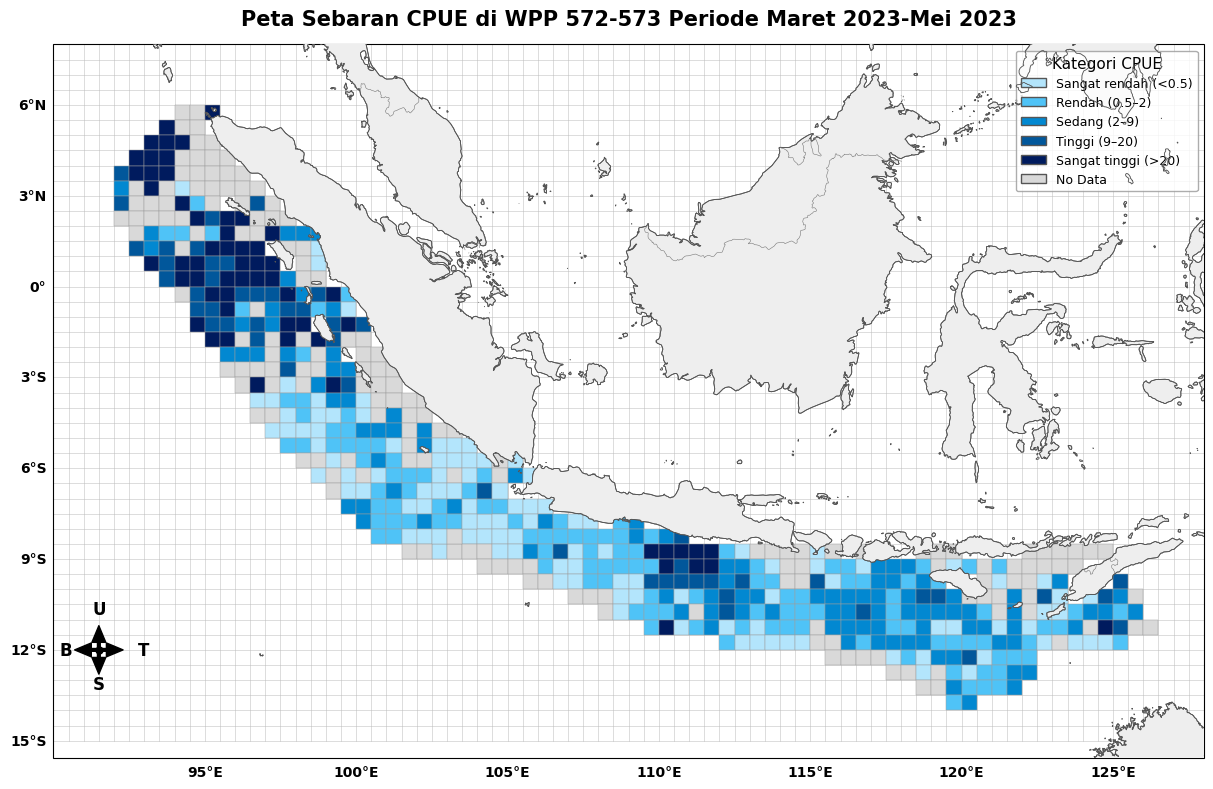

In [ ]:
# =========================
# 1. PARAMETER
# =========================
grid_size = 0.5

lon_min, lon_max = 90, 128
lat_min, lat_max = -15, 8

plot_data = cpue_mar2.copy()
plot_data['cpue_new'] = pd.to_numeric(plot_data['cpue_new'], errors='coerce')

# =========================
# 2. KATEGORI CPUE + NO DATA
# =========================
bins = [0, 0.5, 2, 9, 20, 100]

labels = [
    'Sangat rendah (<0.5)',
    'Rendah (0.5–2)',
    'Sedang (2–9)',
    'Tinggi (9–20)',
    'Sangat tinggi (>20)'
]

plot_data['kategori_cpue'] = pd.cut(
    plot_data['cpue_new'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

plot_data['kategori_cpue'] = plot_data['kategori_cpue'].cat.add_categories(['No Data'])
plot_data['kategori_cpue'] = plot_data['kategori_cpue'].fillna('No Data')

# =========================
# 3. WARNA
# =========================
colors_cpue = {
    'Sangat rendah (<0.5)': '#B3E5FC',
    'Rendah (0.5–2)': '#4FC3F7',
    'Sedang (2–9)': '#0288D1',
    'Tinggi (9–20)': '#01579B',
    'Sangat tinggi (>20)': '#001B5E',
    'No Data': '#d9d9d9'   # abu-abu samar
}

# =========================
# 4. PLOT PETA
# =========================
fig = plt.figure(figsize=(13, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([lon_min, lon_max, lat_min, lat_max])
ax.set_facecolor('#ffffff')

# Grid 0.5 derajat
for lon in np.arange(lon_min, lon_max + grid_size, grid_size):
    ax.plot(
        [lon, lon], [lat_min, lat_max],
        color='#bdbdbd',
        linewidth=0.45,
        alpha=0.8,
        transform=ccrs.PlateCarree(),
        zorder=1
    )

for lat in np.arange(lat_min, lat_max + grid_size, grid_size):
    ax.plot(
        [lon_min, lon_max], [lat, lat],
        color='#bdbdbd',
        linewidth=0.45,
        alpha=0.8,
        transform=ccrs.PlateCarree(),
        zorder=1
    )

# Plot kotak/grid CPUE
for _, row in plot_data.iterrows():
    lon = row['Longitude']
    lat = row['Latitude']
    kategori = row['kategori_cpue']

    if pd.isna(lon) or pd.isna(lat):
        continue

    if not (lon_min <= lon <= lon_max and lat_min <= lat <= lat_max):
        continue

    rect = patches.Rectangle(
        (lon - grid_size / 2, lat - grid_size / 2),
        grid_size,
        grid_size,
        facecolor=colors_cpue[kategori],
        edgecolor='#9e9e9e',
        linewidth=0.35,
        transform=ccrs.PlateCarree(),
        zorder=2
    )

    ax.add_patch(rect)

# Daratan
land = cfeature.NaturalEarthFeature(
    category='physical',
    name='land',
    scale='10m',
    facecolor='#eeeeee',
    edgecolor='#555555'
)

ax.add_feature(land, linewidth=0.6, zorder=5)
ax.add_feature(cfeature.COASTLINE.with_scale('10m'),
               linewidth=0.6, edgecolor='#555555', zorder=6)
ax.add_feature(cfeature.BORDERS.with_scale('10m'),
               linewidth=0.4, edgecolor='#777777', zorder=6)

# Label koordinat
gl = ax.gridlines(draw_labels=True, linewidth=0, color='none')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10, 'weight': 'bold'}
gl.ylabel_style = {'size': 10, 'weight': 'bold'}

# Legend
legend_patches = [
    patches.Patch(
        facecolor=colors_cpue[label],
        edgecolor='#555555',
        label=label
    )
    for label in colors_cpue
]

ax.legend(
    handles=legend_patches,
    title='Kategori CPUE',
    loc='upper right',
    frameon=True,
    edgecolor='#999999',
    fontsize=9,
    title_fontsize=11
)

# =========================
# 5. MATA ANGIN
# =========================
x_c, y_c = 91.5, -12
panjang = 0.8

ax.scatter(
    x_c, y_c,
    color='black',
    s=25,
    transform=ccrs.PlateCarree(),
    zorder=10
)

# U
ax.annotate('', xy=(x_c, y_c + panjang), xytext=(x_c, y_c),
            arrowprops=dict(facecolor='black', width=2, headwidth=10),
            xycoords=ccrs.PlateCarree()._as_mpl_transform(ax))
ax.text(x_c, y_c + panjang + 0.4, 'U',
        ha='center', fontsize=12, fontweight='bold',
        transform=ccrs.PlateCarree())

# S
ax.annotate('', xy=(x_c, y_c - panjang), xytext=(x_c, y_c),
            arrowprops=dict(facecolor='black', width=2, headwidth=10),
            xycoords=ccrs.PlateCarree()._as_mpl_transform(ax))
ax.text(x_c, y_c - panjang - 0.5, 'S',
        ha='center', fontsize=12, fontweight='bold',
        transform=ccrs.PlateCarree())

# T
ax.annotate('', xy=(x_c + panjang, y_c), xytext=(x_c, y_c),
            arrowprops=dict(facecolor='black', width=2, headwidth=10),
            xycoords=ccrs.PlateCarree()._as_mpl_transform(ax))
ax.text(x_c + panjang + 0.5, y_c, 'T',
        va='center', fontsize=12, fontweight='bold',
        transform=ccrs.PlateCarree())

# B
ax.annotate('', xy=(x_c - panjang, y_c), xytext=(x_c, y_c),
            arrowprops=dict(facecolor='black', width=2, headwidth=10),
            xycoords=ccrs.PlateCarree()._as_mpl_transform(ax))
ax.text(x_c - panjang - 0.5, y_c, 'B',
        va='center', fontsize=12, fontweight='bold',
        transform=ccrs.PlateCarree())

# =========================
# 6. JUDUL
# =========================
ax.set_title(
    'Peta Sebaran CPUE di WPP 572-573 Periode Maret 2023-Mei 2023',
    fontsize=15,
    fontweight='bold',
    pad=14
)

plt.tight_layout()
plt.show()

In [ ]:
np.random.seed(42)

# Definisikan koordinat dari DataFrame 'data'
coords_cpue_new = list(zip(data['Longitude'], data['Latitude']))

# Buat matriks bobot spasial K-nearest neighbors (misalnya, k=4)
w_cpue_new = KNN.from_array(coords_cpue_new, k=5)

# Standardisasi baris matriks bobot
w_cpue_new.transform = 'R'

# Hitung Moran's I untuk cpue_new
mi_cpue_new = Moran(data['cpue_new'], w_cpue_new)

print("Moran's I (cpue_new):", mi_cpue_new.I)
print("p-value (cpue_new)  :", mi_cpue_new.p_sim)
print("z-score (cpue_new)  :", mi_cpue_new.z_sim)

Moran's I (cpue_new): 0.5366461142634854
p-value (cpue_new)  : 0.001
z-score (cpue_new)  : 20.24672763072623


## Eksplorasi Boxplot

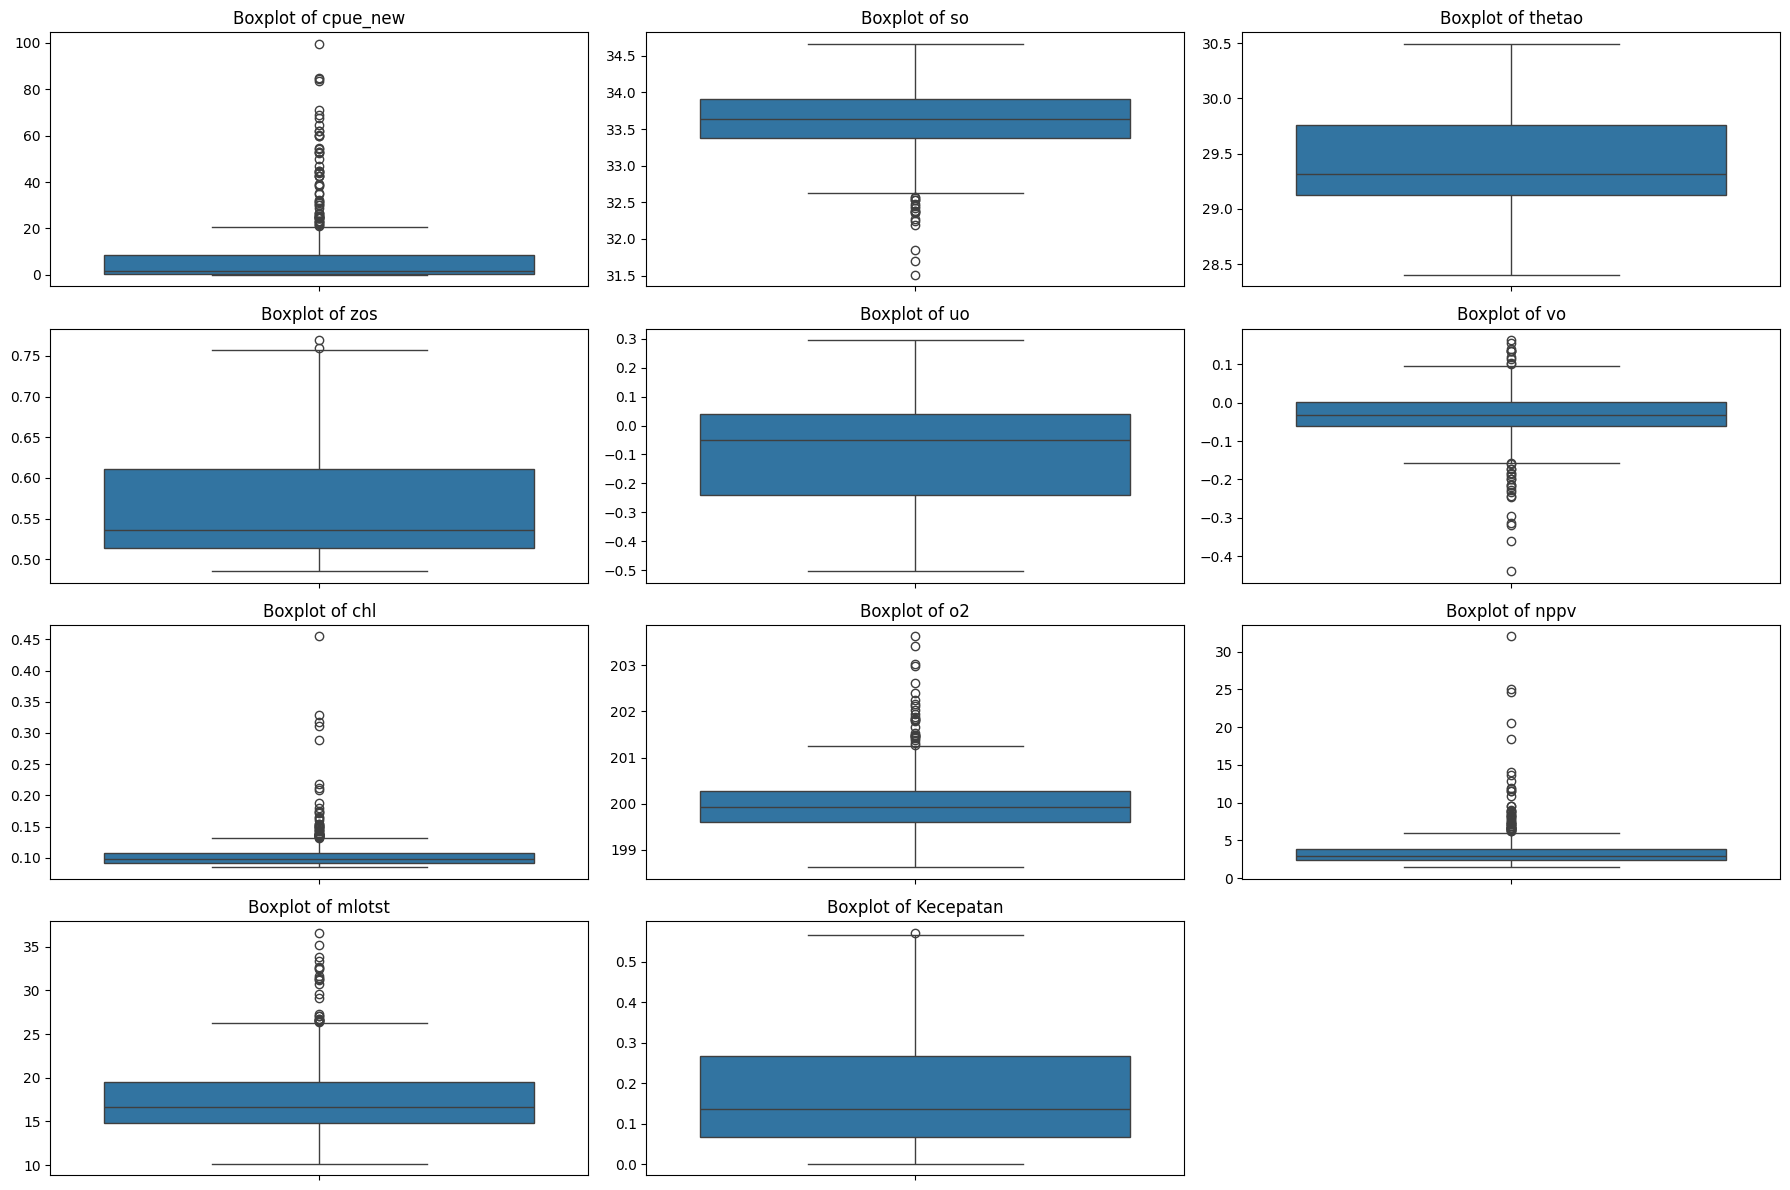

In [ ]:
columns_to_plot = ['cpue_new', 'so', 'thetao', 'zos', 'uo', 'vo', 'chl', 'o2',  'nppv', 'mlotst', 'Kecepatan']

plt.figure(figsize=(18, 12))
for i, col in enumerate(columns_to_plot):
    plt.subplot(4, 3, i + 1) # Arrange plots in a 3x3 grid
    sns.boxplot(y=data[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel('') # Remove y-axis label to avoid clutter
plt.tight_layout()
plt.show()

## Pemodelan Regresi Linear Berganda

In [ ]:
X = data[['so', 'thetao', 'zos','uo', 'vo', 'chl', 'o2', 'mlotst', 'nppv']]
y = data['cpue_new']

# Add a constant (intercept) to the independent variables
X = sm.add_constant(X)
VarNames = X.columns[:]

In [ ]:
# Model regresi
model = sm.OLS(y, X).fit()

# Ringkasan hasil
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               cpue_new   R-squared:                       0.317
Model:                            OLS   Adj. R-squared:                  0.303
Method:                 Least Squares   F-statistic:                     22.46
Date:                Tue, 05 May 2026   Prob (F-statistic):           2.27e-31
Time:                        12:47:07   Log-Likelihood:                -1765.5
No. Observations:                 445   AIC:                             3551.
Df Residuals:                     435   BIC:                             3592.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2507.6941    354.526     -7.073      0.0

In [ ]:
# pastikan X punya konstanta
X_const = sm.add_constant(X, has_constant="add")

# model regresi
model = sm.OLS(y, X_const).fit()

# residual
residual = model.resid

# Breusch-Pagan
bp_test = het_breuschpagan(residual, X_const)

print("Breusch-Pagan Test")
print("LM Statistic:", bp_test[0])
print("LM p-value:", bp_test[1])
print("F Statistic:", bp_test[2])
print("F p-value:", bp_test[3])

if bp_test[1] < 0.05:
    print("Terdapat heteroskedastisitas")
else:
    print("Tidak terdapat heteroskedastisitas")

Breusch-Pagan Test
LM Statistic: 45.32293815151022
LM p-value: 1.9015417418794898e-06
F Statistic: 5.480946710305365
F p-value: 3.762477557083231e-07
Terdapat heteroskedastisitas


In [ ]:
# residual/sisaan dari model OLS
np.random.seed(42)
residual = model.resid

coords = list(zip(data['Longitude'], data['Latitude']))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

# Moran's I residual
moran_resid = Moran(residual, w)

print("Moran's I:", moran_resid.I)
print("Expected I:", moran_resid.EI)
print("p-value:", moran_resid.p_sim)
print("z-score:", moran_resid.z_sim)

if moran_resid.p_sim < 0.05:
    print("Terdapat autokorelasi spasial pada sisaan")
else:
    print("Tidak terdapat autokorelasi spasial pada sisaan")

Moran's I: 0.31510738485018197
Expected I: -0.0022522522522522522
p-value: 0.001
z-score: 11.895597327732789
Terdapat autokorelasi spasial pada sisaan


## XGBoost Global (Tanpa Longitude/Latitude)

### Pemodelan XGBoost Transformasi Log

#### Pembagian data

In [ ]:
X = data[['so', 'thetao', 'zos','uo', 'vo', 'chl', 'o2', 'mlotst', 'nppv']]
y = data['cpue_new']
VarNames = X.columns[:]

In [ ]:
# 1. Stratified binning (pakai y asli)
y_binned = pd.qcut(y, q=5, labels=False)

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y_binned, test_size=0.3, random_state=42
)

In [ ]:
print("TRAIN")
print(pd.Series(y_train).describe())

print("\nTEST")
print(pd.Series(y_test).describe())

TRAIN
count    311.000000
mean       8.955109
std       16.437526
min        0.000072
25%        0.532294
50%        1.793340
75%        9.699669
max       99.604130
Name: cpue_new, dtype: float64

TEST
count    134.000000
mean       7.755197
std       13.052873
min        0.000964
25%        0.485854
50%        2.003057
75%        7.320084
max       69.070554
Name: cpue_new, dtype: float64


In [ ]:
# 3. Transformasi (SETELAH split)
y_train = np.log1p(y_train)
y_test  = np.log1p(y_test)

#### Optuna Tuning Hyperparameter

In [ ]:
def objective(trial):

    params = {
        'objective': 'reg:squarederror',

        'n_estimators': trial.suggest_categorical(
            'n_estimators', [50, 75, 100, 125]
        ),

        'max_depth': trial.suggest_categorical(
            'max_depth', [2, 3, 4]
        ),

        'learning_rate': trial.suggest_categorical(
            'learning_rate', [0.01, 0.03, 0.05, 0.1]
        ),

        'subsample': trial.suggest_categorical(
            'subsample', [0.6, 0.7, 0.8, 0.9]
        ),

        'colsample_bytree': trial.suggest_categorical(
            'colsample_bytree', [0.6, 0.7, 0.8]
        ),

        'gamma': trial.suggest_categorical(
            'gamma', [0.1, 0.3, 0.5, 1]
        ),

        'reg_alpha': trial.suggest_categorical(
            'reg_alpha', [0.1, 0.3, 0.5, 1]
        ),

        'reg_lambda': trial.suggest_categorical(
            'reg_lambda', [1, 2, 3, 5]
        ),

        'min_child_weight': trial.suggest_categorical(
            'min_child_weight', [5, 7, 10, 13]
        ),

        'random_state': 42,
        'n_jobs': 1
    }

    model = XGBRegressor(**params)

    # 🔥 BINNING target untuk stratification
    y_binned = pd.qcut(y_train, q=5, labels=False, duplicates='drop')

    # 🔥 Stratified K-Fold
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        scoring= 'neg_root_mean_squared_error',
        cv=cv.split(X_train, y_binned),  # <- ini kuncinya
        n_jobs=1
    )

    return -scores.mean()

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(objective, n_trials=100)

[I 2026-04-29 10:57:48,632] A new study created in memory with name: no-name-5424cdfd-b27f-4c8f-b885-da276f7b3452
[I 2026-04-29 10:57:49,084] Trial 0 finished with value: 1.0454043327845226 and parameters: {'n_estimators': 75, 'max_depth': 2, 'learning_rate': 0.01, 'subsample': 0.6, 'colsample_bytree': 0.8, 'gamma': 0.5, 'reg_alpha': 1, 'reg_lambda': 3, 'min_child_weight': 13}. Best is trial 0 with value: 1.0454043327845226.
[I 2026-04-29 10:57:49,364] Trial 1 finished with value: 0.940923748896377 and parameters: {'n_estimators': 50, 'max_depth': 2, 'learning_rate': 0.05, 'subsample': 0.6, 'colsample_bytree': 0.7, 'gamma': 0.1, 'reg_alpha': 1, 'reg_lambda': 3, 'min_child_weight': 13}. Best is trial 1 with value: 0.940923748896377.
[I 2026-04-29 10:57:49,845] Trial 2 finished with value: 0.9089931772849387 and parameters: {'n_estimators': 75, 'max_depth': 3, 'learning_rate': 0.03, 'subsample': 0.7, 'colsample_bytree': 0.8, 'gamma': 0.5, 'reg_alpha': 0.5, 'reg_lambda': 1, 'min_child_wei

In [ ]:
best_params = study.best_params
best_params

{'n_estimators': 75,
 'max_depth': 4,
 'learning_rate': 0.05,
 'subsample': 0.8,
 'colsample_bytree': 0.6,
 'gamma': 0.1,
 'reg_alpha': 0.1,
 'reg_lambda': 2,
 'min_child_weight': 7}

In [ ]:
best_model = XGBRegressor(
    **best_params,
    objective='reg:squarederror',
    random_state=42
)

best_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=7, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=75,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_train_log = best_model.predict(X_train)
y_pred_test_log = best_model.predict(X_test)

# inverse transform
y_pred_train = np.expm1(y_pred_train_log)
y_pred_test = np.expm1(y_pred_test_log)

# target asli
y_train_asli = np.expm1(y_train)
y_test_asli = np.expm1(y_test)

#### Evaluasi Model

In [ ]:
def evaluate(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return r2, mae, rmse

# Train
r2_train, mae_train, rmse_train = evaluate(y_train_asli, y_pred_train)

# Test
r2_test, mae_test, rmse_test = evaluate(y_test_asli, y_pred_test)

print("=== TRAIN ===")
print("MAE:", mae_train)
print("RMSE:", rmse_train)

print("\n=== TEST ===")
print("MAE:", mae_test)
print("RMSE:", rmse_test)

=== TRAIN ===
MAE: 4.502600703991848
RMSE: 10.426968755301724

=== TEST ===
MAE: 5.094544651874968
RMSE: 9.8864733555705


In [ ]:
y_pred = best_model.predict(X)
residual = y - y_pred

from libpysal.weights import KNN

coords = list(zip(data['Longitude'], data['Latitude']))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

In [ ]:
np.random.seed(42)
mi = Moran(residual, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : 0.5085853621575005
p-value   : 0.001
z-score   : 19.240923783080355


### Pemodelan XGBoost Tweedie

#### Pembagian Data

In [ ]:
X = data[['so', 'thetao', 'zos','uo', 'vo', 'chl', 'o2', 'mlotst', 'nppv']]
y = data['cpue_new']
VarNames = X.columns[:]

In [ ]:
# 1. Stratified binning (pakai y asli)
y_binned = pd.qcut(y, q=5, labels=False)

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y_binned, test_size=0.3, random_state=42
)

In [ ]:
print("TRAIN")
print(pd.Series(y_train).describe())

print("\nTEST")
print(pd.Series(y_test).describe())

TRAIN
count    311.000000
mean       8.955109
std       16.437526
min        0.000072
25%        0.532294
50%        1.793340
75%        9.699669
max       99.604130
Name: cpue_new, dtype: float64

TEST
count    134.000000
mean       7.755197
std       13.052873
min        0.000964
25%        0.485854
50%        2.003057
75%        7.320084
max       69.070554
Name: cpue_new, dtype: float64


#### Optuna Tuning Hyperparameter

In [ ]:
def objective(trial):

    params = {
        'objective': 'reg:tweedie',
        'eval_metric': 'rmse',

        # Tweedie power umumnya 1 < p < 2
        # p mendekati 1: mirip Poisson
        # p mendekati 2: mirip Gamma
        'tweedie_variance_power': trial.suggest_float(
            'tweedie_variance_power', 1.1, 1.9
        ),

        'n_estimators': trial.suggest_categorical(
            'n_estimators', [50, 75, 100, 125]
        ),

        'max_depth': trial.suggest_categorical(
            'max_depth', [2, 3, 4]
        ),

        'learning_rate': trial.suggest_categorical(
            'learning_rate', [0.01, 0.03, 0.05, 0.1]
        ),

        'subsample': trial.suggest_categorical(
            'subsample', [0.6, 0.7, 0.8, 0.9]
        ),

        'colsample_bytree': trial.suggest_categorical(
            'colsample_bytree', [0.6, 0.7, 0.8]
        ),

        'gamma': trial.suggest_categorical(
            'gamma', [0.1, 0.3, 0.5, 1]
        ),

        'reg_alpha': trial.suggest_categorical(
            'reg_alpha', [0.1, 0.3, 0.5, 1]
        ),

        'reg_lambda': trial.suggest_categorical(
            'reg_lambda', [1, 2, 3, 5]
        ),

        'min_child_weight': trial.suggest_categorical(
            'min_child_weight', [5, 7, 10, 13]
        ),

        'random_state': 42,
        'n_jobs': 1
    }

    model = XGBRegressor(**params)

    y_binned = pd.qcut(y_train, q=5, labels=False, duplicates='drop')

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        scoring='neg_root_mean_squared_error',
        cv=cv.split(X_train, y_binned),
        n_jobs=1
    )

    return -scores.mean()

In [ ]:
study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(objective, n_trials=100)

[I 2026-04-29 10:59:40,629] A new study created in memory with name: no-name-d513995b-5d66-46fc-9f3d-898c3f143853
[I 2026-04-29 10:59:40,828] Trial 0 finished with value: 13.195595810833552 and parameters: {'tweedie_variance_power': 1.39963209507789, 'n_estimators': 50, 'max_depth': 4, 'learning_rate': 0.1, 'subsample': 0.6, 'colsample_bytree': 0.7, 'gamma': 0.3, 'reg_alpha': 0.5, 'reg_lambda': 5, 'min_child_weight': 13}. Best is trial 0 with value: 13.195595810833552.
[I 2026-04-29 10:59:41,069] Trial 1 finished with value: 14.54057293285826 and parameters: {'tweedie_variance_power': 1.7467178784931687, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'subsample': 0.9, 'colsample_bytree': 0.7, 'gamma': 0.3, 'reg_alpha': 0.5, 'reg_lambda': 1, 'min_child_weight': 13}. Best is trial 0 with value: 13.195595810833552.
[I 2026-04-29 10:59:41,306] Trial 2 finished with value: 13.421720458404883 and parameters: {'tweedie_variance_power': 1.7177958154373258, 'n_estimators': 100, 'ma

In [ ]:
best_params = study.best_params
best_params

{'tweedie_variance_power': 1.1311610724532972,
 'n_estimators': 50,
 'max_depth': 2,
 'learning_rate': 0.1,
 'subsample': 0.9,
 'colsample_bytree': 0.7,
 'gamma': 0.3,
 'reg_alpha': 1,
 'reg_lambda': 2,
 'min_child_weight': 5}

In [ ]:
best_model = XGBRegressor(
    **best_params,
    objective='reg:tweedie',
    eval_metric='rmse',
    random_state=42
)

best_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=0.3, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=2,
             max_leaves=None, min_child_weight=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=50,
             n_jobs=None, num_parallel_tree=None, ...)

#### Evaluasi Model

In [ ]:
# Prediksi
y_train_pred = best_model.predict(X_train)
y_test_pred  = best_model.predict(X_test)

# Evaluasi train
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae  = mean_absolute_error(y_train, y_train_pred)
train_r2   = r2_score(y_train, y_train_pred)

# Evaluasi test
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae  = mean_absolute_error(y_test, y_test_pred)
test_r2   = r2_score(y_test, y_test_pred)

print("=== TRAIN EVALUATION ===")
print(f"RMSE : {train_rmse:.4f}")
print(f"MAE  : {train_mae:.4f}")

print("\n=== TEST EVALUATION ===")
print(f"RMSE : {test_rmse:.4f}")
print(f"MAE  : {test_mae:.4f}")

=== TRAIN EVALUATION ===
RMSE : 8.6435
MAE  : 5.0528

=== TEST EVALUATION ===
RMSE : 11.0776
MAE  : 6.5816


In [ ]:
y_pred = best_model.predict(X)


# Evaluasi
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae  = mean_absolute_error(y, y_pred)
r2   = r2_score(y, y_pred)

print("=== TRAIN EVALUATION ===")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")


=== TRAIN EVALUATION ===
RMSE : 9.4427
MAE  : 5.5131


#### Pengecekan Autokorelasi Spasial Residual

In [ ]:
residual2 = y - y_pred

coords = list(zip(data['Longitude'], data['Latitude']))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

In [ ]:
np.random.seed(42)
mi = Moran(residual2, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : 0.13374513990200176
p-value   : 0.001
z-score   : 5.061186948115164


## XGBoost Lokal Transformasi Logaritma

### Optimasi Bandwith

In [ ]:
def optimize_bw_gw_xgboost(
    X, y, Coords, params,
    bw_min, bw_max, step=1,
    Kernel='Adaptive',              # 'Adaptive' / 'Fixed'
    KernelFunction='Bisquare',      # 'Bisquare' / 'Gaussian'
    spatial_weights=True,
    n_splits=3,
    max_iter=30,
    tol=1e-3,
    path_save=False
):
    """
    Optimasi bandwidth GWXGBoost:
    - Adaptive : Grid Search
    - Fixed    : Golden Section Ratio

    Kriteria bandwidth terbaik:
    - MAE CV terkecil pada skala asli

    Training model:
    - tetap menggunakan y_log = log1p(y)

    Evaluasi hasil terbaik:
    - ditampilkan pada skala asli dan skala log
    """

    import os
    import numpy as np
    import pandas as pd
    from scipy.spatial import distance_matrix
    from sklearn.model_selection import KFold, GridSearchCV
    from sklearn.metrics import (
        r2_score, mean_absolute_error, mean_squared_error
    )
    from xgboost import XGBRegressor

    # =========================================================
    # Helper RMSE
    # =========================================================
    try:
        from sklearn.metrics import root_mean_squared_error
        def rmse_func(y_true, y_pred):
            return root_mean_squared_error(y_true, y_pred)
    except ImportError:
        def rmse_func(y_true, y_pred):
            return mean_squared_error(y_true, y_pred, squared=False)

    # =========================================================
    # Validasi & casting
    # =========================================================
    X = pd.DataFrame(X).reset_index(drop=True).copy()
    y = pd.Series(np.ravel(y), name='y_asli').reset_index(drop=True).copy()
    Coords = pd.DataFrame(Coords).reset_index(drop=True).copy()

    if (y < 0).any():
        raise ValueError("Semua nilai y harus >= 0 karena fungsi ini memakai log1p(y).")

    if len(X) != len(y) or len(X) != len(Coords):
        raise ValueError("Panjang X, y, dan Coords harus sama.")

    if Kernel not in ['Adaptive', 'Fixed']:
        raise ValueError("Kernel harus 'Adaptive' atau 'Fixed'.")

    if KernelFunction not in ['Bisquare', 'Gaussian']:
        raise ValueError("KernelFunction harus 'Bisquare' atau 'Gaussian'.")

    y_log = pd.Series(np.log1p(y), name='y_log')

    # =========================================================
    # Param grid model (masih bisa Anda perluas)
    # =========================================================
    reg_alpha_list = [params.get('reg_alpha', 0)]
    param_grid = {'reg_alpha': reg_alpha_list}

    # =========================================================
    # Scoring CV
    # refit = MAE asli terkecil
    # =========================================================
    def scorer_neg_mae_original(estimator, X_val, y_val_log):
        y_pred_log = estimator.predict(X_val)
        y_true_original = np.expm1(np.asarray(y_val_log))
        y_pred_original = np.expm1(np.asarray(y_pred_log))
        y_pred_original = np.clip(y_pred_original, a_min=0, a_max=None)
        return -mean_absolute_error(y_true_original, y_pred_original)

    def scorer_neg_rmse_original(estimator, X_val, y_val_log):
        y_pred_log = estimator.predict(X_val)
        y_true_original = np.expm1(np.asarray(y_val_log))
        y_pred_original = np.expm1(np.asarray(y_pred_log))
        y_pred_original = np.clip(y_pred_original, a_min=0, a_max=None)
        return -rmse_func(y_true_original, y_pred_original)

    def scorer_r2_original(estimator, X_val, y_val_log):
        y_pred_log = estimator.predict(X_val)
        y_true_original = np.expm1(np.asarray(y_val_log))
        y_pred_original = np.expm1(np.asarray(y_pred_log))
        y_pred_original = np.clip(y_pred_original, a_min=0, a_max=None)
        return r2_score(y_true_original, y_pred_original)

    scoring = {
        'neg_mean_absolute_error_original': scorer_neg_mae_original,
        'neg_root_mean_squared_error_original': scorer_neg_rmse_original,
        'r2_original': scorer_r2_original
    }

    print("================= Optimizing bandwidth =================")
    print(f"Bandwidth mode : {Kernel}")
    print(f"Kernel function: {KernelFunction}")
    print(f"Spatial weights: {spatial_weights}")
    print("Selection rule : minimum CV-MAE on original scale")

    num_rows = len(X)
    DistanceMatrix_ij = pd.DataFrame(distance_matrix(Coords, Coords))

    if Kernel == 'Adaptive':
        bw_min = int(bw_min)
        bw_max = min(int(bw_max), num_rows - 1)
        step = int(step)
        if bw_min < 1:
            raise ValueError("Untuk Adaptive, bw_min minimal 1.")
        if bw_min > bw_max:
            raise ValueError("Untuk Adaptive, bw_min harus <= bw_max.")
        if step < 1:
            raise ValueError("Untuk Adaptive, step minimal 1.")
    else:
        bw_min = float(bw_min)
        bw_max = float(bw_max)
        if bw_min <= 0 or bw_max <= 0 or bw_min >= bw_max:
            raise ValueError("Untuk Fixed, pastikan 0 < bw_min < bw_max.")

    results_cache = {}

    # =========================================================
    # Bobot kernel
    # =========================================================
    def calc_spatial_weights(dist_series, h):
        dist_series = pd.Series(dist_series).astype(float)
        h = max(float(h), 1e-12)

        if KernelFunction == 'Bisquare':
            w = (1 - (dist_series.pow(2) / (h ** 2))).pow(2)
            w[dist_series >= h] = 0.0
        elif KernelFunction == 'Gaussian':
            w = np.exp(-0.5 * (dist_series / h) ** 2)
        else:
            raise ValueError("KernelFunction tidak dikenal.")

        return np.asarray(w, dtype=float)

    # =========================================================
    # Format cache key
    # =========================================================
    def bw_key(b):
        if Kernel == 'Adaptive':
            return int(round(b))
        else:
            return round(float(b), 10)

    # =========================================================
    # Evaluasi 1 bandwidth
    # MAE dipakai sebagai objective pemilihan bandwidth
    # =========================================================
    def evaluate_bandwidth(b):
        import numpy as np
        import pandas as pd

        if Kernel == 'Adaptive':
            b_eval = int(round(b))
            b_eval = max(int(bw_min), min(int(bw_max), b_eval))
            bw_label = f"{b_eval:d}"
        else:
            b_eval = float(b)
            if b_eval <= 0:
                result = {
                    'BW': b_eval,

                    'R2_asli': np.nan,
                    'MAE_asli': np.nan,
                    'RMSE_asli': np.nan,

                    'R2_log': np.nan,
                    'MAE_log': np.nan,
                    'RMSE_log': np.nan,

                    'CV_MAE': np.inf,
                    'LMResults': None,
                    'status': 'bw harus > 0'
                }
                print(f"bw={b_eval:.6f}, CV_MAE=inf")
                return result
            bw_label = f"{b_eval:.6f}"

        key = bw_key(b_eval)
        if key in results_cache:
            return results_cache[key]

        listIDs = []
        yt_asli = []
        yt_log_true = []

        LM_yOOB_log = []
        LM_yOOB_asli = []
        LM_ResOOB_asli = []
        LM_ResOOB_log = []

        failed_reason = None

        for i in range(num_rows):
            Neighbours = pd.DataFrame(DistanceMatrix_ij.iloc[:, i])
            Neighbours.columns = ['Distance']

            Data = pd.concat([X, y, y_log, Neighbours], axis=1)
            DataSorted = Data.sort_values(by='Distance').reset_index(drop=True)

            # Titik pusat (OOB)
            XcentralOOB = pd.DataFrame(DataSorted.iloc[0, :-3]).T
            YcentralOOB_asli = float(DataSorted.iloc[0, -3])
            YcentralOOB_log = float(DataSorted.iloc[0, -2])

            # ============================================
            # Pembentukan data lokal
            # ============================================
            if Kernel == 'Adaptive':
                knn = int(b_eval)
                LocalData = DataSorted.iloc[1:knn + 1, :].copy()

                if LocalData.shape[0] < n_splits:
                    failed_reason = f"bw={b_eval} gagal: jumlah data lokal < n_splits pada lokasi ke-{i}"
                    break

                h = float(LocalData['Distance'].max())

            else:  # Fixed
                LocalData = DataSorted[DataSorted.Distance < b_eval].copy()
                LocalData = LocalData.iloc[1:, :]

                if LocalData.shape[0] < n_splits:
                    failed_reason = f"bw={b_eval:.6f} gagal: jumlah data lokal < n_splits pada lokasi ke-{i}"
                    break

                h = float(b_eval)

            h = max(h, 1e-12)

            LocalX = LocalData.iloc[:, :-3]
            LocalY_log = LocalData.iloc[:, -2]

            if spatial_weights:
                SpatialWeights = calc_spatial_weights(LocalData['Distance'], h)
            else:
                SpatialWeights = None

            model = XGBRegressor(**params)
            kfold = KFold(n_splits=n_splits, shuffle=True, random_state=7)

            grid_search = GridSearchCV(
                estimator=model,
                param_grid=param_grid,
                scoring=scoring,
                refit='neg_mean_absolute_error_original',
                return_train_score=True,
                n_jobs=-1,
                cv=kfold
            )

            try:
                if not spatial_weights:
                    grid_result = grid_search.fit(LocalX, LocalY_log)
                else:
                    grid_result = grid_search.fit(LocalX, LocalY_log, sample_weight=SpatialWeights)

                best_model = grid_result.best_estimator_

                yOOB_log = float(best_model.predict(XcentralOOB)[0])
                yOOB_asli = float(np.expm1(yOOB_log))
                yOOB_asli = max(yOOB_asli, 0.0)

            except Exception as e:
                failed_reason = f"bw={bw_label} gagal pada lokasi ke-{i}: {str(e)}"
                break

            LM_yOOB_log.append(yOOB_log)
            LM_yOOB_asli.append(yOOB_asli)

            LM_ResOOB_asli.append(YcentralOOB_asli - yOOB_asli)
            LM_ResOOB_log.append(YcentralOOB_log - yOOB_log)

            listIDs.append(i)
            yt_asli.append(YcentralOOB_asli)
            yt_log_true.append(YcentralOOB_log)

        if failed_reason is not None:
            result = {
                'BW': b_eval,

                'R2_asli': np.nan,
                'MAE_asli': np.nan,
                'RMSE_asli': np.nan,

                'R2_log': np.nan,
                'MAE_log': np.nan,
                'RMSE_log': np.nan,

                'CV_MAE': np.inf,
                'LMResults': None,
                'status': failed_reason
            }
            results_cache[key] = result
            print(f"bw={bw_label}, CV_MAE=inf")
            print(f"   alasan: {failed_reason}")
            return result

        LMResults = pd.DataFrame({
            'IDS': listIDs,
            'y_asli': yt_asli,
            'y_log': yt_log_true,
            'LM_yOOB_log': LM_yOOB_log,
            'LM_yOOB_asli': LM_yOOB_asli,
            'LM_ResOOB_asli': LM_ResOOB_asli,
            'LM_ResOOB_log': LM_ResOOB_log
        })

        y_true_asli = LMResults['y_asli']
        y_pred_asli = LMResults['LM_yOOB_asli']

        y_true_log = LMResults['y_log']
        y_pred_log = LMResults['LM_yOOB_log']

        R2_asli = r2_score(y_true_asli, y_pred_asli)
        MAE_asli = mean_absolute_error(y_true_asli, y_pred_asli)
        RMSE_asli = rmse_func(y_true_asli, y_pred_asli)

        R2_log = r2_score(y_true_log, y_pred_log)
        MAE_log = mean_absolute_error(y_true_log, y_pred_log)
        RMSE_log = rmse_func(y_true_log, y_pred_log)

        # Objective utama pemilihan bandwidth
        CV_MAE = MAE_asli

        result = {
            'BW': b_eval,

            'R2_asli': R2_asli,
            'MAE_asli': MAE_asli,
            'RMSE_asli': RMSE_asli,

            'R2_log': R2_log,
            'MAE_log': MAE_log,
            'RMSE_log': RMSE_log,

            'CV_MAE': CV_MAE,
            'LMResults': LMResults,
            'status': 'ok'
        }

        results_cache[key] = result
        print(f"bw={bw_label}, CV_MAE={CV_MAE:.6f}, MAE_log={MAE_log:.6f}")
        return result

    # =========================================================
    # OPTIMASI ADAPTIVE = GRID SEARCH
    # =========================================================
    def optimize_adaptive_grid():
        bw_candidates = list(range(int(bw_min), int(bw_max) + 1, int(step)))

        if len(bw_candidates) == 0:
            raise ValueError("Tidak ada kandidat bandwidth adaptive.")

        print("Optimization method: Grid Search (Adaptive)")
        for bw in bw_candidates:
            evaluate_bandwidth(bw)

    # =========================================================
    # OPTIMASI FIXED = GOLDEN SECTION RATIO
    # Objective: minimum CV_MAE
    # =========================================================
    def optimize_fixed_golden():
        a = float(bw_min)
        b = float(bw_max)

        phi = (1 + np.sqrt(5)) / 2
        invphi = 1 / phi

        c = b - (b - a) * invphi
        d = a + (b - a) * invphi

        fc = evaluate_bandwidth(c)['CV_MAE']
        fd = evaluate_bandwidth(d)['CV_MAE']

        iter_count = 0

        print("Optimization method: Golden Section Ratio (Fixed)")
        while abs(b - a) > tol and iter_count < max_iter:
            if fc <= fd:
                b = d
                d = c
                fd = fc
                c = b - (b - a) * invphi
                fc = evaluate_bandwidth(c)['CV_MAE']
            else:
                a = c
                c = d
                fc = fd
                d = a + (b - a) * invphi
                fd = evaluate_bandwidth(d)['CV_MAE']

            iter_count += 1
            print(f"[Golden iter {iter_count}] interval bw = [{a:.6f}, {b:.6f}]")

        # Refinement akhir
        mid = (a + b) / 2.0
        refine_points = np.unique([a, c, mid, d, b])

        for bw_val in refine_points:
            evaluate_bandwidth(float(bw_val))

    # =========================================================
    # Jalankan optimasi
    # =========================================================
    if Kernel == 'Adaptive':
        optimize_adaptive_grid()
    else:
        optimize_fixed_golden()

    # =========================================================
    # Hasil semua bandwidth
    # =========================================================
    BW_results = pd.DataFrame([
        {
            'BW': v['BW'],

            'R2_asli': v['R2_asli'],
            'MAE_asli': v['MAE_asli'],
            'RMSE_asli': v['RMSE_asli'],

            'R2_log': v['R2_log'],
            'MAE_log': v['MAE_log'],
            'RMSE_log': v['RMSE_log'],

            'CV_MAE': v['CV_MAE'],
            'status': v['status']
        }
        for v in results_cache.values()
    ]).sort_values(by='BW').reset_index(drop=True)

    BW_results_valid = BW_results.replace([np.inf, -np.inf], np.nan).dropna(subset=['CV_MAE'])

    if BW_results_valid.empty:
        raise ValueError("Semua kandidat bandwidth gagal dievaluasi. Coba perbesar bandwidth.")

    idx_best = BW_results_valid['CV_MAE'].idxmin()
    BW_opt = BW_results_valid.loc[idx_best, 'BW']
    CV_MAE_min = float(BW_results_valid.loc[idx_best, 'CV_MAE'])

    if Kernel == 'Adaptive':
        BW_opt = int(round(BW_opt))
    else:
        BW_opt = float(BW_opt)

    best_result = evaluate_bandwidth(BW_opt)
    best_LMResults = best_result['LMResults']

    print("=========================================================================")
    if Kernel == 'Adaptive':
        print(f"Best bandwidth        : {BW_opt}")
    else:
        print(f"Best bandwidth        : {BW_opt:.6f}")

    print(f"Best CV_MAE (asli)    : {CV_MAE_min:.6f}")
    print(f"R2 terbaik (asli)     : {best_result['R2_asli']:.6f}")
    print(f"MAE terbaik (asli)    : {best_result['MAE_asli']:.6f}")
    print(f"RMSE terbaik (asli)   : {best_result['RMSE_asli']:.6f}")
    print(f"R2 terbaik (log)      : {best_result['R2_log']:.6f}")
    print(f"MAE terbaik (log)     : {best_result['MAE_log']:.6f}")
    print(f"RMSE terbaik (log)    : {best_result['RMSE_log']:.6f}")
    print("=========================================================================")

    # =========================================================
    # Simpan hasil
    # =========================================================
    if not path_save:
        bw_path = 'BW_results.csv'
        lm_path = 'LMResults_best_bw.csv'
    else:
        os.makedirs(path_save, exist_ok=True)
        bw_path = os.path.join(path_save, 'BW_results.csv')
        lm_path = os.path.join(path_save, 'LMResults_best_bw.csv')

    BW_results.to_csv(bw_path, index=False)
    if best_LMResults is not None:
        best_LMResults.to_csv(lm_path, index=False)

    return BW_opt, BW_results, best_LMResults

In [ ]:
Coords = data[['Longitude', 'Latitude']]

In [ ]:
X = data[['so', 'thetao', 'zos','uo', 'vo', 'chl', 'o2', 'mlotst', 'nppv']]
y = data['cpue_new']
VarNames = X.columns[:]

In [ ]:
xgb_params = {
        "n_estimators": 75,
        "max_depth": 4,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.6,
        "objective": "reg:squarederror",
        'gamma': 0.1,
        'reg_alpha': 0.1,
        'reg_lambda': 2,
        'min_child_weight': 7,
        "random_state": 42
    }

#### Adaptive Bisquare

In [ ]:
BW_opt, BW_results, best_LMResults = optimize_bw_gw_xgboost(
    X=X,
    y=y,
    Coords=Coords,
    params=xgb_params,
    bw_min=50,
    bw_max=150,
    step=2,
    Kernel='Adaptive',
    KernelFunction='Bisquare',
    spatial_weights=True,
    n_splits=3
)

================= Optimizing bandwidth =================
Bandwidth mode : Adaptive
Kernel function: Bisquare
Spatial weights: True
Selection rule : minimum CV-MAE on original scale
Optimization method: Grid Search (Adaptive)
bw=50, CV_MAE=5.593024, MAE_log=0.603567
bw=52, CV_MAE=5.624041, MAE_log=0.605030
bw=54, CV_MAE=5.639603, MAE_log=0.605524
bw=56, CV_MAE=5.621353, MAE_log=0.602645
bw=58, CV_MAE=5.637800, MAE_log=0.601595
bw=60, CV_MAE=5.647360, MAE_log=0.602776
bw=62, CV_MAE=5.666589, MAE_log=0.601862
bw=64, CV_MAE=5.696849, MAE_log=0.603032
bw=66, CV_MAE=5.731174, MAE_log=0.603977
bw=68, CV_MAE=5.771862, MAE_log=0.604880
bw=70, CV_MAE=5.772810, MAE_log=0.604957
bw=72, CV_MAE=5.784873, MAE_log=0.604641
bw=74, CV_MAE=5.789089, MAE_log=0.606606
bw=76, CV_MAE=5.816789, MAE_log=0.608585
bw=78, CV_MAE=5.826084, MAE_log=0.609975
bw=80, CV_MAE=5.826702, MAE_log=0.610181
bw=82, CV_MAE=5.859680, MAE_log=0.612623
bw=84, CV_MAE=5.845363, MAE_log=0.614496
bw=86, CV_MAE=5.833701, MAE_log=0.611

#### Adaptive Gaussian

In [ ]:
BW_opt2, BW_results2, best_LMResults2 = optimize_bw_gw_xgboost(
    X=X,
    y=y,
    Coords=Coords,
    params=xgb_params,
    bw_min=50,
    bw_max=150,
    step=2,
    Kernel='Adaptive',
    KernelFunction='Gaussian',
    spatial_weights=True,
    n_splits=3
)

================= Optimizing bandwidth =================
Bandwidth mode : Adaptive
Kernel function: Gaussian
Spatial weights: True
Selection rule : minimum CV-MAE on original scale
Optimization method: Grid Search (Adaptive)
bw=50, CV_MAE=5.814348, MAE_log=0.611900
bw=52, CV_MAE=5.918713, MAE_log=0.615612
bw=54, CV_MAE=5.937250, MAE_log=0.619874
bw=56, CV_MAE=5.881915, MAE_log=0.614657
bw=58, CV_MAE=5.844488, MAE_log=0.611743
bw=60, CV_MAE=5.852897, MAE_log=0.609157
bw=62, CV_MAE=5.859768, MAE_log=0.608377
bw=64, CV_MAE=5.870151, MAE_log=0.613387
bw=66, CV_MAE=5.841807, MAE_log=0.613582
bw=68, CV_MAE=5.813762, MAE_log=0.614493
bw=70, CV_MAE=5.829026, MAE_log=0.616123
bw=72, CV_MAE=5.793491, MAE_log=0.614632
bw=74, CV_MAE=5.748952, MAE_log=0.610386
bw=76, CV_MAE=5.764489, MAE_log=0.610107
bw=78, CV_MAE=5.781917, MAE_log=0.612048
bw=80, CV_MAE=5.805146, MAE_log=0.615758
bw=82, CV_MAE=5.845857, MAE_log=0.618013
bw=84, CV_MAE=5.854883, MAE_log=0.615055
bw=86, CV_MAE=5.816321, MAE_log=0.619

### Pemodelan XGBoost Lokal

In [ ]:
def build_local_gwxgboost(
    X, y, Coords, BW_opt, params,
    Kernel='Adaptive',
    KernelFunction='Bisquare',
    spatial_weights=True,
    n_splits=3,
    feat_importance='gain',
    alpha_wt_type='varying',
    alpha_wt=0.5,
    random_state=42,
    path_save=False
):
    import os
    import numpy as np
    import pandas as pd

    from scipy.spatial import distance_matrix
    from sklearn.model_selection import KFold, cross_validate
    from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
    from xgboost import XGBRegressor

    try:
        from sklearn.metrics import root_mean_squared_error

        def rmse_func(y_true, y_pred):
            return root_mean_squared_error(y_true, y_pred)

    except ImportError:

        def rmse_func(y_true, y_pred):
            return mean_squared_error(y_true, y_pred, squared=False)

    # ======================================================
    # Validasi data
    # ======================================================
    X = pd.DataFrame(X).reset_index(drop=True).copy()
    y = pd.Series(np.ravel(y), name='y_asli').reset_index(drop=True).copy()
    Coords = pd.DataFrame(Coords).reset_index(drop=True).copy()

    if (y < 0).any():
        raise ValueError("Semua nilai y harus >= 0 untuk transformasi log(y + 1).")

    if len(X) != len(y) or len(X) != len(Coords):
        raise ValueError("Panjang X, y, dan Coords harus sama.")

    if Kernel not in ['Adaptive', 'Fixed']:
        raise ValueError("Kernel harus 'Adaptive' atau 'Fixed'.")

    if KernelFunction not in ['Bisquare', 'Gaussian']:
        raise ValueError("KernelFunction harus 'Bisquare' atau 'Gaussian'.")

    if alpha_wt_type not in ['fixed', 'varying']:
        raise ValueError("alpha_wt_type harus 'fixed' atau 'varying'.")

    if alpha_wt < 0 or alpha_wt > 1:
        raise ValueError("alpha_wt harus berada antara 0 dan 1.")

    # ======================================================
    # Transformasi y
    # ======================================================
    y_log = pd.Series(np.log1p(y), name='y_log').reset_index(drop=True)

    # ======================================================
    # Parameter XGBoost
    # ======================================================
    params = params.copy()
    params['objective'] = 'reg:squarederror'
    params['random_state'] = random_state

    num_rows = len(X)
    feature_names = list(X.columns)

    DistanceMatrix_ij = pd.DataFrame(distance_matrix(Coords, Coords))

    # ======================================================
    # Scoring CV lokal pada skala asli
    # ======================================================
    def scorer_neg_mae(estimator, X_val, y_val_log):
        y_pred_log = estimator.predict(X_val)
        y_pred = np.expm1(y_pred_log)
        y_pred = np.clip(y_pred, 0, None)

        y_val = np.expm1(y_val_log)
        y_val = np.clip(y_val, 0, None)

        return -mean_absolute_error(y_val, y_pred)

    def scorer_neg_rmse(estimator, X_val, y_val_log):
        y_pred_log = estimator.predict(X_val)
        y_pred = np.expm1(y_pred_log)
        y_pred = np.clip(y_pred, 0, None)

        y_val = np.expm1(y_val_log)
        y_val = np.clip(y_val, 0, None)

        return -rmse_func(y_val, y_pred)

    def scorer_r2_original(estimator, X_val, y_val_log):
        y_pred_log = estimator.predict(X_val)
        y_pred = np.expm1(y_pred_log)
        y_pred = np.clip(y_pred, 0, None)

        y_val = np.expm1(y_val_log)
        y_val = np.clip(y_val, 0, None)

        return r2_score(y_val, y_pred)

    scoring = {
        'neg_mae': scorer_neg_mae,
        'neg_rmse': scorer_neg_rmse,
        'r2': scorer_r2_original
    }

    # ======================================================
    # Bobot spasial
    # ======================================================
    def calc_spatial_weights(dist_series, h):
        dist_series = pd.Series(dist_series).astype(float)
        h = max(float(h), 1e-12)

        if KernelFunction == 'Bisquare':
            w = (1 - (dist_series.pow(2) / (h ** 2))).pow(2)
            w[dist_series >= h] = 0.0

        elif KernelFunction == 'Gaussian':
            w = np.exp(-0.5 * (dist_series / h) ** 2)

        return np.asarray(w, dtype=float)

    results = []
    importance_rows = []
    bestLocalModel = []

    print("================= Building Local GWXGBoost Log-Squarederror =================")

    # ======================================================
    # Loop model lokal
    # ======================================================
    for i in range(num_rows):

        print(f"Calculating local model {i + 1} of {num_rows}")

        Neighbours = pd.DataFrame(DistanceMatrix_ij.iloc[:, i])
        Neighbours.columns = ['Distance']

        Data = pd.concat([X, y, y_log, Neighbours], axis=1)
        DataSorted = Data.sort_values(by='Distance').reset_index(drop=True)

        XcentralOOB = pd.DataFrame(DataSorted.iloc[0, :-3]).T
        XcentralOOB.columns = X.columns

        YcentralOOB = float(DataSorted.iloc[0]['y_asli'])

        # ==================================================
        # Local data OOB dan full
        # ==================================================
        if Kernel == 'Adaptive':
            knn = int(BW_opt)

            LocalData = DataSorted.iloc[1:knn + 1, :].copy()
            LocalDataFull = DataSorted.iloc[:knn + 1, :].copy()

            if LocalData.shape[0] < n_splits:
                raise ValueError(
                    f"Jumlah data lokal lokasi ke-{i} kurang dari n_splits."
                )

            h = float(LocalData['Distance'].max())

        else:
            bw = float(BW_opt)

            LocalData = DataSorted[DataSorted.Distance < bw].copy()
            LocalData = LocalData.iloc[1:, :].copy()

            LocalDataFull = DataSorted[DataSorted.Distance < bw].copy()

            if LocalData.shape[0] < n_splits:
                raise ValueError(
                    f"Jumlah data lokal lokasi ke-{i} kurang dari n_splits."
                )

            h = bw

        h = max(h, 1e-12)

        LocalX = LocalData.iloc[:, :-3]
        LocalY_log = LocalData['y_log']

        LocalXFull = LocalDataFull.iloc[:, :-3]
        LocalYFull_log = LocalDataFull['y_log']

        LocalX.columns = X.columns
        LocalXFull.columns = X.columns

        if spatial_weights:
            SpatialWeights = calc_spatial_weights(LocalData['Distance'], h)
            SpatialWeightsFull = calc_spatial_weights(LocalDataFull['Distance'], h)
        else:
            SpatialWeights = None
            SpatialWeightsFull = None

        # ==================================================
        # Model lokal OOB
        # Training pakai log(y + 1)
        # ==================================================
        local_model = XGBRegressor(
            **params,
            importance_type=feat_importance
        )

        if spatial_weights:
            local_model.fit(
                LocalX,
                LocalY_log,
                sample_weight=SpatialWeights
            )
        else:
            local_model.fit(LocalX, LocalY_log)

        bestLocalModel.append(local_model)

        LM_yOOB_log = float(local_model.predict(XcentralOOB)[0])
        LM_yOOB = float(np.expm1(LM_yOOB_log))
        LM_yOOB = max(LM_yOOB, 0.0)

        LM_ResOOB = YcentralOOB - LM_yOOB

        # ==================================================
        # CV lokal MAE, RMSE, R2
        # Evaluasi dikembalikan ke skala asli
        # ==================================================
        kfold = KFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=random_state
        )

        try:
            if spatial_weights:
                cv_result = cross_validate(
                    local_model,
                    LocalX,
                    LocalY_log,
                    scoring=scoring,
                    cv=kfold,
                    params={'sample_weight': SpatialWeights},
                    n_jobs=-1
                )
            else:
                cv_result = cross_validate(
                    local_model,
                    LocalX,
                    LocalY_log,
                    scoring=scoring,
                    cv=kfold,
                    n_jobs=-1
                )

        except TypeError:
            try:
                if spatial_weights:
                    cv_result = cross_validate(
                        local_model,
                        LocalX,
                        LocalY_log,
                        scoring=scoring,
                        cv=kfold,
                        fit_params={'sample_weight': SpatialWeights},
                        n_jobs=-1
                    )
                else:
                    cv_result = cross_validate(
                        local_model,
                        LocalX,
                        LocalY_log,
                        scoring=scoring,
                        cv=kfold,
                        n_jobs=-1
                    )

            except TypeError:
                cv_result = cross_validate(
                    local_model,
                    LocalX,
                    LocalY_log,
                    scoring=scoring,
                    cv=kfold,
                    n_jobs=-1
                )

        LM_Best_score_MAE = -np.mean(cv_result['test_neg_mae'])
        LM_Best_score_RMSE = -np.mean(cv_result['test_neg_rmse'])
        LMRsqr = np.mean(cv_result['test_r2'])

        # ==================================================
        # Model lokal full: including central point
        # Training pakai log(y + 1)
        # ==================================================
        local_model_full = XGBRegressor(
            **params,
            importance_type=feat_importance
        )

        if spatial_weights:
            local_model_full.fit(
                LocalXFull,
                LocalYFull_log,
                sample_weight=SpatialWeightsFull
            )
        else:
            local_model_full.fit(LocalXFull, LocalYFull_log)

        LM_yPred_log = float(local_model_full.predict(XcentralOOB)[0])
        LM_yPred = float(np.expm1(LM_yPred_log))
        LM_yPred = max(LM_yPred, 0.0)

        # ==================================================
        # Model global excluding central point
        # Training pakai log(y + 1)
        # ==================================================
        X_global = X.drop(index=i).reset_index(drop=True)
        y_global_log = y_log.drop(index=i).reset_index(drop=True)

        global_model = XGBRegressor(
            **params,
            importance_type=feat_importance
        )

        global_model.fit(X_global, y_global_log)

        yGhat_log = float(global_model.predict(X.iloc[[i]])[0])
        yGhat = float(np.expm1(yGhat_log))
        yGhat = max(yGhat, 0.0)

        # ==================================================
        # Alpha ensemble mengikuti konsep GeoXGBoost
        # Semua komponen sudah pada skala asli
        # ==================================================
        res_local = YcentralOOB - LM_yOOB
        res_global = YcentralOOB - yGhat

        if alpha_wt_type == 'fixed':
            Alpha_wt = float(alpha_wt)

        elif alpha_wt_type == 'varying':
            if alpha_wt == 1:
                Alpha_wt = 1.0
            else:
                if abs(res_global) > abs(res_local):
                    Alpha_wt = 1.0
                else:
                    Alpha_wt = float(alpha_wt)

        beta_wt = 1 - Alpha_wt

        y_ensemble = Alpha_wt * LM_yOOB + beta_wt * yGhat
        y_ensemble = max(float(y_ensemble), 0.0)

        # ==================================================
        # Feature importance lokal
        # ==================================================
        Imp_ = local_model.feature_importances_

        imp_dict = {
            f'Imp_{feature_names[j]}': float(Imp_[j])
            for j in range(len(feature_names))
        }

        MaxImportance = float(np.max(Imp_))
        MaxFeatureID = feature_names[int(np.argmax(Imp_))]

        importance_rows.append({
            'IDS': i,
            **imp_dict
        })

        results.append({
            'IDS': i,
            'y_asli': YcentralOOB,

            'LM_yPred': LM_yPred,
            'LM_yOOB': LM_yOOB,
            'LM_ResOOB': LM_ResOOB,

            'LMRsqr': LMRsqr,
            'LM_Best_score_MAE': LM_Best_score_MAE,
            'LM_Best_score_RMSE': LM_Best_score_RMSE,

            'alpha_wt': Alpha_wt,
            'yGhat': yGhat,
            'y_ensemble': y_ensemble,

            'MaxImportance': MaxImportance,
            'MaxFeatureID': MaxFeatureID
        })

    # ======================================================
    # Gabungkan hasil lokal
    # ======================================================
    LMResults = pd.DataFrame(results)
    LocalImportance = pd.DataFrame(importance_rows)

    LMResults = LMResults.merge(
        LocalImportance,
        on='IDS',
        how='left'
    )

    # ======================================================
    # Evaluasi keseluruhan data pada skala asli
    # ======================================================
    y_true = LMResults['y_asli']

    Evaluation_Results = pd.DataFrame({
        'Model': [
            'Local XGBoost Log-Squarederror - Pred',
            'Local XGBoost Log-Squarederror - OOB',
            'Global XGBoost Log-Squarederror - OOB',
            'Ensemble Local + Global'
        ],
        'Kolom_Prediksi': [
            'LM_yPred',
            'LM_yOOB',
            'yGhat',
            'y_ensemble'
        ],
        'R2': [
            r2_score(y_true, LMResults['LM_yPred']),
            r2_score(y_true, LMResults['LM_yOOB']),
            r2_score(y_true, LMResults['yGhat']),
            r2_score(y_true, LMResults['y_ensemble'])
        ],
        'MAE': [
            mean_absolute_error(y_true, LMResults['LM_yPred']),
            mean_absolute_error(y_true, LMResults['LM_yOOB']),
            mean_absolute_error(y_true, LMResults['yGhat']),
            mean_absolute_error(y_true, LMResults['y_ensemble'])
        ],
        'RMSE': [
            rmse_func(y_true, LMResults['LM_yPred']),
            rmse_func(y_true, LMResults['LM_yOOB']),
            rmse_func(y_true, LMResults['yGhat']),
            rmse_func(y_true, LMResults['y_ensemble'])
        ]
    })

    # ======================================================
    # Simpan hasil
    # ======================================================
    if path_save:
        os.makedirs(path_save, exist_ok=True)

        LMResults.to_csv(
            os.path.join(path_save, 'LocalModelResults_GWXGB_LogSquarederror.csv'),
            index=False
        )

        Evaluation_Results.to_csv(
            os.path.join(path_save, 'Evaluation_GWXGB_LogSquarederror.csv'),
            index=False
        )

    output = {
        'Prediction': LMResults,
        'Evaluation': Evaluation_Results,
        'bestLocalModel': bestLocalModel,
        'alpha_wt': LMResults['alpha_wt'].tolist()
    }

    return output

#### Adaptive Bisquare

In [ ]:
output_model = build_local_gwxgboost(
    X=X,
    y=y,
    Coords=Coords,
    BW_opt=50,
    params=xgb_params,
    Kernel='Adaptive',
    KernelFunction='Bisquare',
    spatial_weights=True,
    n_splits=3,
    feat_importance='gain',
    alpha_wt_type='varying',
    alpha_wt=0.5,
    random_state=42,
    path_save='hasil_gwxgb_log_squarederror'
)

================= Building Local GWXGBoost Log-Squarederror =================
Calculating local model 1 of 445
Calculating local model 2 of 445
Calculating local model 3 of 445
Calculating local model 4 of 445
Calculating local model 5 of 445
Calculating local model 6 of 445
Calculating local model 7 of 445
Calculating local model 8 of 445
Calculating local model 9 of 445
Calculating local model 10 of 445
Calculating local model 11 of 445
Calculating local model 12 of 445
Calculating local model 13 of 445
Calculating local model 14 of 445
Calculating local model 15 of 445
Calculating local model 16 of 445
Calculating local model 17 of 445
Calculating local model 18 of 445
Calculating local model 19 of 445
Calculating local model 20 of 445
Calculating local model 21 of 445
Calculating local model 22 of 445
Calculating local model 23 of 445
Calculating local model 24 of 445
Calculating local model 25 of 445
Calculating local model 26 of 445
Calculating local model 27 of 445
Calculating l

In [ ]:
LMResults = output_model['Prediction']
Evaluation_Results = output_model['Evaluation']

LMResults.head(450)

,IDS,y_asli,LM_yPred,LM_yOOB,LM_ResOOB,LMRsqr,LM_Best_score_MAE,LM_Best_score_RMSE,alpha_wt,yGhat,...,MaxFeatureID,Imp_so,Imp_thetao,Imp_zos,Imp_uo,Imp_vo,Imp_chl,Imp_o2,Imp_mlotst,Imp_nppv
0,0,12.138553,12.814073,17.347997,-5.209443,-0.384168,19.688535,26.899166,0.5,13.061107,...,vo,0.150563,0.052298,0.046636,0.155583,0.205826,0.166619,0.045356,0.000000,0.177118
1,1,8.620704,10.467066,18.333944,-9.713241,-0.649314,22.157534,28.516457,0.5,12.835029,...,o2,0.069726,0.033700,0.168473,0.152733,0.124537,0.059281,0.185471,0.075867,0.130213
2,2,16.722104,19.824252,26.323278,-9.601174,-0.273480,19.917379,27.176425,0.5,20.967699,...,o2,0.081079,0.072189,0.000000,0.168562,0.133262,0.081145,0.193808,0.085592,0.184362
3,3,17.616588,13.496950,11.387077,6.229511,-0.640744,20.277915,27.802385,0.5,16.305645,...,uo,0.000000,0.000000,0.000000,0.696314,0.080692,0.000000,0.000000,0.000000,0.222994
4,4,61.991957,27.914437,15.005067,46.986890,-0.362314,20.079839,27.143459,0.5,18.729318,...,nppv,0.064310,0.115132,0.041750,0.157489,0.152924,0.071731,0.166020,0.042435,0.188209
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440,440,19.300079,3.053297,1.645447,17.654631,-0.107853,3.056190,5.600151,1.0,1.232088,...,vo,0.092370,0.170519,0.066535,0.103326,0.214500,0.108855,0.076569,0.105648,0.061677
441,441,0.690572,2.973744,4.384259,-3.693686,-0.072475,3.401228,6.840348,0.5,1.692497,...,vo,0.098253,0.211234,0.074568,0.117221,0.218771,0.000000,0.098474,0.115498,0.065982
442,442,2.059131,4.893134,5.002722,-2.943591,-0.048729,3.391146,6.649564,0.5,3.071615,...,thetao,0.121001,0.218476,0.026722,0.056331,0.184927,0.115888,0.078600,0.108764,0.089291
443,443,9.879915,4.537932,3.901874,5.978042,-0.049383,3.172655,6.673667,0.5,6.649097,...,thetao,0.056431,0.160770,0.101151,0.092050,0.156922,0.133750,0.054905,0.102732,0.141289


In [ ]:
Evaluation_Results

,Model,Kolom_Prediksi,R2,MAE,RMSE
0,Local XGBoost Log-Squarederror - Pred,LM_yPred,0.604226,4.158049,9.734868
1,Local XGBoost Log-Squarederror - OOB,LM_yOOB,0.390739,5.593024,12.078357
2,Global XGBoost Log-Squarederror - OOB,yGhat,0.319239,5.852771,12.767426
3,Ensemble Local + Global,y_ensemble,0.420639,5.216121,11.778252


<Figure size 900x600 with 0 Axes>

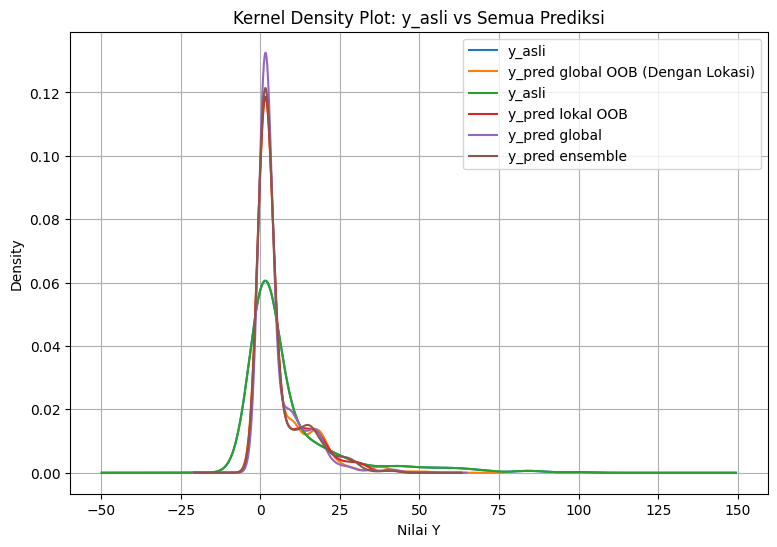

In [ ]:
LMResults = pd.read_excel("/content/LMResults_GWXGB_Log_Bisquare_Maret.xlsx")
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

# ambil tabel prediksi
GlobalResults = global_oob_log['Prediction']

plt.figure(figsize=(9, 6))

GlobalResults['y_asli'].plot(
    kind='kde',
    label='y_asli'
)

GlobalResults['yGhat'].plot(
    kind='kde',
    label='y_pred global OOB (Dengan Lokasi)'
)

LMResults['y_asli'].plot(kind='kde', label='y_asli')
LMResults['LM_yOOB'].plot(kind='kde', label='y_pred lokal OOB')
LMResults['yGhat'].plot(kind='kde', label='y_pred global')
LMResults['y_ensemble'].plot(kind='kde', label='y_pred ensemble')


plt.xlabel('Nilai Y')
plt.ylabel('Density')
plt.title('Kernel Density Plot: y_asli vs Semua Prediksi')
plt.legend()
plt.grid(True)
plt.show()

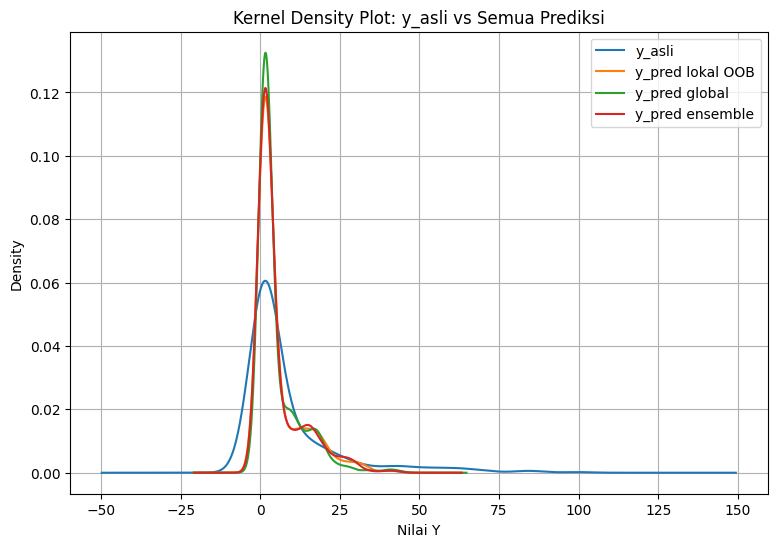

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

LMResults['y_asli'].plot(kind='kde', label='y_asli')
LMResults['LM_yOOB'].plot(kind='kde', label='y_pred lokal OOB')
LMResults['yGhat'].plot(kind='kde', label='y_pred global')
LMResults['y_ensemble'].plot(kind='kde', label='y_pred ensemble')

plt.xlabel('Nilai Y')
plt.ylabel('Density')
plt.title('Kernel Density Plot: y_asli vs Semua Prediksi')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
LMResults.to_excel(
    'LMResults_GWXGB_Log_Bisquare_Maret.xlsx',
    index=False
)

##### Pengecekan Autokorelasi Residual Spasial

In [ ]:
LMResults['Res_ensemble'] = (
    LMResults['y_asli'] - LMResults['y_ensemble']
)

In [ ]:
## XGBoost Global OOB
from libpysal.weights import KNN
from esda.moran import Moran
np.random.seed(7)

# residual ensemble
residual33 = LMResults['y_asli'] - LMResults['yGhat']

# koordinat
coords = list(zip(Coords.iloc[:, 0], Coords.iloc[:, 1]))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

# Moran's I
mi = Moran(residual33, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : 0.15649935260460862
p-value   : 0.001
z-score   : 5.7995692349855945


In [ ]:
## XGBoost Lokal
from libpysal.weights import KNN
from esda.moran import Moran
np.random.seed(7)

# residual lokal OOB
residual = LMResults['LM_ResOOB']

# koordinat
coords = list(zip(Coords.iloc[:, 0], Coords.iloc[:, 1]))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

# Moran's I
mi = Moran(residual, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : 0.09775577820341938
p-value   : 0.001
z-score   : 3.6484159789964266


In [ ]:
## XGBoost Esemble
from libpysal.weights import KNN
from esda.moran import Moran
np.random.seed(7)

# residual ensemble
residual22 = LMResults['y_asli'] - LMResults['y_ensemble']

# koordinat
coords = list(zip(Coords.iloc[:, 0], Coords.iloc[:, 1]))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

# Moran's I
mi = Moran(residual22, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : 0.11152548685754964
p-value   : 0.001
z-score   : 4.169073447406374


##### Prediksi Titik Baru

In [ ]:
def predict_new_gwxgboost(
    X_train, y_train, Coords_train,
    X_new, Coords_new,
    BW_opt, params,
    Kernel='Adaptive',
    KernelFunction='Bisquare',
    spatial_weights=True,
    feat_importance='gain',
    alpha_wt=0.5,
    alpha_wt_type='varying',
    random_state=42,
    path_save=False
):
    import os
    import numpy as np
    import pandas as pd
    from scipy.spatial import distance_matrix
    from xgboost import XGBRegressor

    # ======================================================
    # Validasi dan persiapan data
    # ======================================================
    X_train = pd.DataFrame(X_train).reset_index(drop=True).copy()
    y_train = pd.Series(np.ravel(y_train), name='y_asli').reset_index(drop=True)
    Coords_train = pd.DataFrame(Coords_train).reset_index(drop=True).copy()

    X_new = pd.DataFrame(X_new).reset_index(drop=True).copy()
    Coords_new = pd.DataFrame(Coords_new).reset_index(drop=True).copy()

    X_new.columns = X_train.columns

    if len(X_train) != len(y_train) or len(X_train) != len(Coords_train):
        raise ValueError("Panjang X_train, y_train, dan Coords_train harus sama.")

    if len(X_new) != len(Coords_new):
        raise ValueError("Panjang X_new dan Coords_new harus sama.")

    if (y_train < 0).any():
        raise ValueError("Semua nilai y_train harus >= 0 untuk transformasi log(y + 1).")

    if Kernel not in ['Adaptive', 'Fixed']:
        raise ValueError("Kernel harus 'Adaptive' atau 'Fixed'.")

    if KernelFunction not in ['Bisquare', 'Gaussian']:
        raise ValueError("KernelFunction harus 'Bisquare' atau 'Gaussian'.")

    if alpha_wt_type not in ['fixed', 'varying']:
        raise ValueError("alpha_wt_type harus 'fixed' atau 'varying'.")

    # ======================================================
    # Persiapan alpha weight
    # ======================================================
    if alpha_wt_type == 'fixed':
        Alpha_Fixed = float(alpha_wt)

        if Alpha_Fixed < 0 or Alpha_Fixed > 1:
            raise ValueError("alpha_wt harus berada antara 0 dan 1.")

        Alpha_wtDF = None

    else:
        # Untuk varying, alpha_wt harus berisi alpha per titik training
        if isinstance(alpha_wt, dict) and 'alpha_wt' in alpha_wt:
            alpha_raw = alpha_wt['alpha_wt']

        elif isinstance(alpha_wt, pd.DataFrame):
            if 'alpha_wt' in alpha_wt.columns:
                alpha_raw = alpha_wt['alpha_wt']
            else:
                alpha_raw = alpha_wt.iloc[:, 0]

        else:
            alpha_raw = alpha_wt

        Alpha_wtDF = pd.Series(
            np.ravel(alpha_raw),
            name='alpha_wt'
        ).reset_index(drop=True)

        if len(Alpha_wtDF) != len(X_train):
            raise ValueError(
                "Untuk alpha_wt_type='varying', panjang alpha_wt harus sama "
                "dengan jumlah data training."
            )

        if ((Alpha_wtDF < 0) | (Alpha_wtDF > 1)).any():
            raise ValueError("Semua nilai alpha_wt varying harus berada antara 0 dan 1.")

        Alpha_Fixed = None

    # ======================================================
    # Transformasi y training
    # ======================================================
    y_train_log = pd.Series(np.log1p(y_train), name='y_log')

    # ======================================================
    # Parameter XGBoost
    # ======================================================
    params = params.copy()
    params['objective'] = 'reg:squarederror'
    params['random_state'] = random_state

    # ======================================================
    # Fungsi bobot spasial
    # ======================================================
    def calc_spatial_weights(dist_series, h):
        dist_series = pd.Series(dist_series).astype(float)
        h = max(float(h), 1e-12)

        if KernelFunction == 'Bisquare':
            w = (1 - (dist_series.pow(2) / (h ** 2))).pow(2)
            w[dist_series >= h] = 0.0

        elif KernelFunction == 'Gaussian':
            w = np.exp(-0.5 * (dist_series / h) ** 2)

        return np.asarray(w, dtype=float)

    # ======================================================
    # Fungsi feature importance per lokasi
    # ======================================================
    def get_feature_importance_df(model, feature_names, ids_new, importance_type='gain'):
        booster = model.get_booster()
        score = booster.get_score(importance_type=importance_type)

        importance_df = pd.DataFrame({
            'IDS_new': ids_new,
            'Feature': feature_names,
            'Importance': [score.get(f, 0.0) for f in feature_names]
        })

        total_importance = importance_df['Importance'].sum()

        if total_importance > 0:
            importance_df['Importance_Relative'] = (
                importance_df['Importance'] / total_importance
            )
        else:
            importance_df['Importance_Relative'] = 0.0

        importance_df['Rank'] = importance_df['Importance'].rank(
            ascending=False,
            method='dense'
        ).astype(int)

        importance_df = importance_df.sort_values(
            by=['IDS_new', 'Rank', 'Importance'],
            ascending=[True, True, False]
        ).reset_index(drop=True)

        return importance_df

    # ======================================================
    # Model global
    # ======================================================
    global_model = XGBRegressor(
        **params,
        importance_type=feat_importance
    )

    global_model.fit(X_train, y_train_log)

    # ======================================================
    # Distance matrix: titik baru ke titik training
    # ======================================================
    DistanceMatrix_NewTrain = pd.DataFrame(
        distance_matrix(Coords_new, Coords_train)
    )

    results = []
    local_models_new = []
    feature_importance_all = []

    print("================= Predict New Data GWXGBoost =================")

    # ======================================================
    # Loop setiap titik baru
    # ======================================================
    for i in range(len(X_new)):

        print(f"Predicting new location {i + 1} of {len(X_new)}")

        dist_i = DistanceMatrix_NewTrain.iloc[i, :].reset_index(drop=True)

        nearest_train_id = int(dist_i.idxmin())

        DataLocal = pd.concat(
            [
                X_train,
                y_train.rename('y_asli'),
                y_train_log,
                pd.Series(dist_i, name='Distance')
            ],
            axis=1
        )

        DataLocalSorted = DataLocal.sort_values(
            by='Distance'
        ).reset_index(drop=True)

        # ==================================================
        # Ambil data lokal berdasarkan bandwidth
        # ==================================================
        if Kernel == 'Adaptive':
            knn = int(BW_opt)

            if knn < 2:
                raise ValueError("BW_opt Adaptive minimal harus 2.")

            LocalData = DataLocalSorted.iloc[:knn, :].copy()
            h = float(LocalData['Distance'].max())

        else:
            bw = float(BW_opt)

            LocalData = DataLocalSorted[
                DataLocalSorted['Distance'] < bw
            ].copy()

            h = bw

        if LocalData.shape[0] < 2:
            raise ValueError(
                f"Jumlah data lokal untuk titik baru ke-{i} terlalu sedikit."
            )

        h = max(h, 1e-12)

        LocalX = LocalData.iloc[:, :-3]
        LocalY_log = LocalData['y_log']

        LocalX.columns = X_train.columns

        # ==================================================
        # Bobot spasial
        # ==================================================
        if spatial_weights:
            SpatialWeights = calc_spatial_weights(
                LocalData['Distance'], h
            )
        else:
            SpatialWeights = None

        # ==================================================
        # Model lokal untuk titik baru
        # ==================================================
        local_model = XGBRegressor(
            **params,
            importance_type=feat_importance
        )

        if spatial_weights:
            local_model.fit(
                LocalX,
                LocalY_log,
                sample_weight=SpatialWeights
            )
        else:
            local_model.fit(LocalX, LocalY_log)

        local_models_new.append(local_model)

        # ==================================================
        # Feature importance lokal untuk titik baru
        # ==================================================
        imp_i = get_feature_importance_df(
            model=local_model,
            feature_names=list(X_train.columns),
            ids_new=i,
            importance_type=feat_importance
        )

        feature_importance_all.append(imp_i)

        top_features = (
            imp_i.sort_values(
                by='Importance_Relative',
                ascending=False
            )
            .head(5)['Feature']
            .tolist()
        )

        # ==================================================
        # Prediksi lokal pada skala asli
        # ==================================================
        y_local_log = float(local_model.predict(X_new.iloc[[i]])[0])
        y_local = float(np.expm1(y_local_log))
        y_local = max(y_local, 0.0)

        # ==================================================
        # Prediksi global pada skala asli
        # ==================================================
        y_global_log = float(global_model.predict(X_new.iloc[[i]])[0])
        y_global = float(np.expm1(y_global_log))
        y_global = max(y_global, 0.0)

        # ==================================================
        # Alpha weight fixed atau varying
        # ==================================================
        if alpha_wt_type == 'fixed':
            Alpha_wt = Alpha_Fixed
            Alpha_Source = 'fixed'

        else:
            Alpha_wt = float(Alpha_wtDF.iloc[nearest_train_id])
            Alpha_Source = f'nearest_train_id_{nearest_train_id}'

        Beta_wt = 1 - Alpha_wt

        # ==================================================
        # Ensemble local + global
        # ==================================================
        y_ensemble = Alpha_wt * y_local + Beta_wt * y_global
        y_ensemble = max(float(y_ensemble), 0.0)

        results.append({
            'IDS_new': i,
            'Nearest_Train_ID': nearest_train_id,
            'Distance_to_Nearest': float(dist_i.min()),
            'Local_Pred': y_local,
            'Global_Pred': y_global,
            'alpha_wt_type': alpha_wt_type,
            'alpha_source': Alpha_Source,
            'alpha_wt': Alpha_wt,
            'beta_wt': Beta_wt,
            'Ensemble_Pred': y_ensemble,
            'Top_Features': ', '.join(top_features)
        })

    Prediction_New = pd.DataFrame(results)

    Feature_Importance_New = pd.concat(
        feature_importance_all,
        ignore_index=True
    )

    # ======================================================
    # Simpan hasil
    # ======================================================
    if path_save:
        os.makedirs(path_save, exist_ok=True)

        Prediction_New.to_csv(
            os.path.join(path_save, 'Prediction_New_GWXGBoost.csv'),
            index=False
        )

        Feature_Importance_New.to_csv(
            os.path.join(path_save, 'Feature_Importance_New_GWXGBoost.csv'),
            index=False
        )

    output = {
        'Prediction_New': Prediction_New,
        'Feature_Importance_New': Feature_Importance_New,
        'local_models_new': local_models_new,
        'global_model': global_model
    }

    return output

In [ ]:
# 1) Baca Excel (sheet pertama)
prediksi = pd.read_excel("/content/data_prediksi_mar-mei.xlsx")
prediksi.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         165 non-null    int64  
 1   left       165 non-null    float64
 2   top        165 non-null    float64
 3   right      165 non-null    float64
 4   bottom     165 non-null    float64
 5   row_index  165 non-null    int64  
 6   col_index  165 non-null    int64  
 7   Longitude  165 non-null    float64
 8   Latitude   165 non-null    float64
 9   periode    165 non-null    object 
 10  so         165 non-null    float64
 11  thetao     165 non-null    float64
 12  zos        165 non-null    float64
 13  uo         165 non-null    float64
 14  vo         165 non-null    float64
 15  chl        165 non-null    float64
 16  o2         165 non-null    float64
 17  mlotst     165 non-null    float64
 18  nppv       165 non-null    float64
dtypes: float64(15), int64(3), object(1)
memory usage: 

In [ ]:
Coords_baru = prediksi[['Longitude', 'Latitude']]
X_baru = prediksi[['so', 'thetao', 'zos','uo', 'vo', 'chl', 'o2', 'mlotst', 'nppv']]
VarNames = X.columns[:]

In [ ]:
# ======================================================
# 5. Prediksi titik baru
# ======================================================
hasil_prediksi_baru = predict_new_gwxgboost(
    X_train=X,
    y_train=y,
    Coords_train=Coords,
    X_new=X_baru,
    Coords_new=Coords_baru,
    BW_opt=50,
    params=xgb_params,
    Kernel='Adaptive',
    KernelFunction='Bisquare',
    spatial_weights=True,
    alpha_wt=output_model['alpha_wt'],
    alpha_wt_type='varying',
    random_state=42,
    path_save='hasil_prediksi_baru'
)

================= Predict New Data GWXGBoost =================
Predicting new location 1 of 165
Predicting new location 2 of 165
Predicting new location 3 of 165
Predicting new location 4 of 165
Predicting new location 5 of 165
Predicting new location 6 of 165
Predicting new location 7 of 165
Predicting new location 8 of 165
Predicting new location 9 of 165
Predicting new location 10 of 165
Predicting new location 11 of 165
Predicting new location 12 of 165
Predicting new location 13 of 165
Predicting new location 14 of 165
Predicting new location 15 of 165
Predicting new location 16 of 165
Predicting new location 17 of 165
Predicting new location 18 of 165
Predicting new location 19 of 165
Predicting new location 20 of 165
Predicting new location 21 of 165
Predicting new location 22 of 165
Predicting new location 23 of 165
Predicting new location 24 of 165
Predicting new location 25 of 165
Predicting new location 26 of 165
Predicting new location 27 of 165
Predicting new location 28 o

In [ ]:
# ======================================================
# 6. Lihat hasil prediksi
# ======================================================
hasil_prediksi_baru['Prediction_New']

,IDS_new,Nearest_Train_ID,Distance_to_Nearest,Local_Pred,Global_Pred,alpha_wt_type,alpha_source,alpha_wt,beta_wt,Ensemble_Pred,Top_Features
0,0,203,0.500000,0.341483,0.961874,varying,nearest_train_id_203,1.0,0.0,0.341483,"uo, nppv, chl, zos, o2"
1,1,204,0.500000,0.363027,0.862470,varying,nearest_train_id_204,1.0,0.0,0.363027,"o2, uo, chl, so, thetao"
2,2,205,0.500000,0.396125,0.786600,varying,nearest_train_id_205,1.0,0.0,0.396125,"vo, thetao, zos, uo, so"
3,3,207,0.707107,0.478523,0.997068,varying,nearest_train_id_207,1.0,0.0,0.478523,"so, thetao, zos, uo, vo"
4,4,207,0.500000,0.543940,1.057109,varying,nearest_train_id_207,1.0,0.0,0.543940,"so, thetao, zos, uo, vo"
...,...,...,...,...,...,...,...,...,...,...,...
160,160,188,0.500000,0.660091,2.044844,varying,nearest_train_id_188,1.0,0.0,0.660091,"so, thetao, zos, uo, vo"
161,161,181,0.500000,0.636752,0.658275,varying,nearest_train_id_181,1.0,0.0,0.636752,"chl, thetao, uo, o2, mlotst"
162,162,177,0.500000,0.384220,0.846540,varying,nearest_train_id_177,1.0,0.0,0.384220,"uo, zos, chl, nppv, thetao"
163,163,198,0.500000,0.727891,1.499478,varying,nearest_train_id_198,1.0,0.0,0.727891,"thetao, uo, so, zos, chl"


In [ ]:
# ======================================================
# 6. Lihat hasil prediksi
# ======================================================
Feature_Importance_New = hasil_prediksi_baru['Feature_Importance_New']

In [ ]:
# Gabungkan hasil prediksi ke data_baru
prediksi['Pred_Local'] = hasil_prediksi_baru['Prediction_New']['Local_Pred']
prediksi['Pred_Global'] = hasil_prediksi_baru['Prediction_New']['Global_Pred']
prediksi['Pred_Ensemble'] = hasil_prediksi_baru['Prediction_New']['Ensemble_Pred']

# Simpan ke Excel
prediksi.to_excel(
    'hasil_prediksi_data_baru_Mar.xlsx',
    index=False
)

In [ ]:
# Simpan ke Excel
Feature_Importance_New.to_excel(
    'Feature_Importance_New_Bisquare_Mar.xlsx',
    index=False
)

#### Adaptive Gaussian

In [ ]:
output_model2 = build_local_gwxgboost(
    X=X,
    y=y,
    Coords=Coords,
    BW_opt=134,
    params=xgb_params,
    Kernel='Adaptive',
    KernelFunction='Gaussian',
    spatial_weights=True,
    n_splits=3,
    feat_importance='gain',
    alpha_wt_type='varying',
    alpha_wt=0.5,
    random_state=42,
    path_save='hasil_gwxgb_log_squarederror'
)

================= Building Local GWXGBoost Log-Squarederror =================
Calculating local model 1 of 445
Calculating local model 2 of 445
Calculating local model 3 of 445
Calculating local model 4 of 445
Calculating local model 5 of 445
Calculating local model 6 of 445
Calculating local model 7 of 445
Calculating local model 8 of 445
Calculating local model 9 of 445
Calculating local model 10 of 445
Calculating local model 11 of 445
Calculating local model 12 of 445
Calculating local model 13 of 445
Calculating local model 14 of 445
Calculating local model 15 of 445
Calculating local model 16 of 445
Calculating local model 17 of 445
Calculating local model 18 of 445
Calculating local model 19 of 445
Calculating local model 20 of 445
Calculating local model 21 of 445
Calculating local model 22 of 445
Calculating local model 23 of 445
Calculating local model 24 of 445
Calculating local model 25 of 445
Calculating local model 26 of 445
Calculating local model 27 of 445
Calculating l

In [ ]:
LMResults2 = output_model2['Prediction']
Evaluation_Results2 = output_model2['Evaluation']

LMResults2.head()

,IDS,y_asli,LM_yPred,LM_yOOB,LM_ResOOB,LMRsqr,LM_Best_score_MAE,LM_Best_score_RMSE,alpha_wt,yGhat,...,MaxFeatureID,Imp_so,Imp_thetao,Imp_zos,Imp_uo,Imp_vo,Imp_chl,Imp_o2,Imp_mlotst,Imp_nppv
0,0,12.138553,11.992011,17.045992,-4.907439,0.141631,12.502706,19.138215,0.5,13.061107,...,thetao,0.068554,0.249912,0.099588,0.070228,0.107368,0.070427,0.085776,0.087387,0.160760
1,1,8.620704,10.434594,13.163897,-4.543194,0.045194,12.953132,19.471477,0.5,12.835029,...,thetao,0.070667,0.257333,0.101193,0.066929,0.104823,0.066246,0.084432,0.092079,0.156297
2,2,16.722104,19.766813,21.482660,-4.760556,0.119985,12.614455,19.141419,0.5,20.967699,...,thetao,0.079386,0.243507,0.077185,0.069900,0.123152,0.063485,0.091507,0.086434,0.165444
3,3,17.616588,16.209033,12.904402,4.712186,0.057010,13.052149,19.572054,0.5,16.305645,...,thetao,0.076214,0.244074,0.077360,0.069456,0.094919,0.096811,0.094642,0.077730,0.168795
4,4,61.991957,26.760069,18.432346,43.559611,0.125945,12.471475,19.075861,0.5,18.729318,...,thetao,0.062973,0.231339,0.097004,0.085223,0.098158,0.065932,0.088185,0.108813,0.162373


In [ ]:
Evaluation_Results2

,Model,Kolom_Prediksi,R2,MAE,RMSE
0,Local XGBoost Log-Squarederror - Pred,LM_yPred,0.729571,3.246663,8.046979
1,Local XGBoost Log-Squarederror - OOB,LM_yOOB,0.372903,5.676873,12.253873
2,Global XGBoost Log-Squarederror - OOB,yGhat,0.319239,5.852771,12.767426
3,Ensemble Local + Global,y_ensemble,0.392569,5.417622,12.060208


<Figure size 900x600 with 0 Axes>

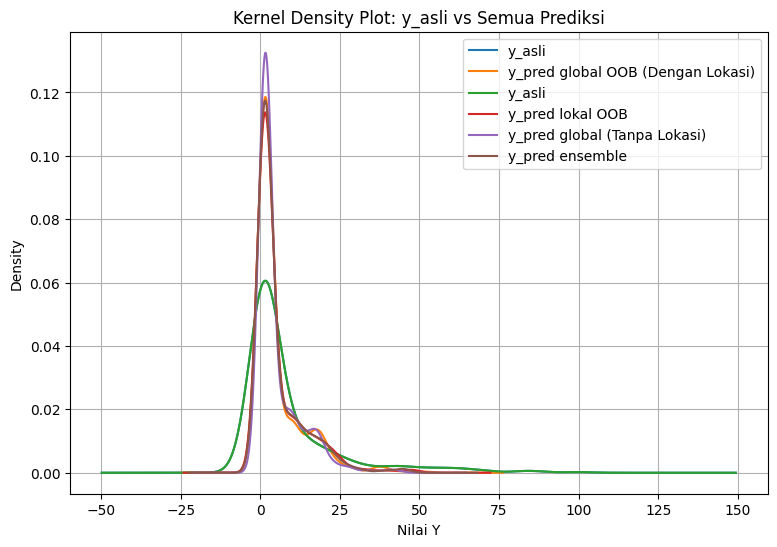

In [ ]:
LMResults = pd.read_excel("/content/LMResults_GWXGB_Log_Gaussian_Maret.xlsx")
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

# ambil tabel prediksi
GlobalResults = global_oob_log['Prediction']

plt.figure(figsize=(9, 6))

GlobalResults['y_asli'].plot(
    kind='kde',
    label='y_asli'
)

GlobalResults['yGhat'].plot(
    kind='kde',
    label='y_pred global OOB (Dengan Lokasi)'
)

LMResults['y_asli'].plot(kind='kde', label='y_asli')
LMResults['LM_yOOB'].plot(kind='kde', label='y_pred lokal OOB')
LMResults['yGhat'].plot(kind='kde', label='y_pred global (Tanpa Lokasi)')
LMResults['y_ensemble'].plot(kind='kde', label='y_pred ensemble')


plt.xlabel('Nilai Y')
plt.ylabel('Density')
plt.title('Kernel Density Plot: y_asli vs Semua Prediksi')
plt.legend()
plt.grid(True)
plt.show()

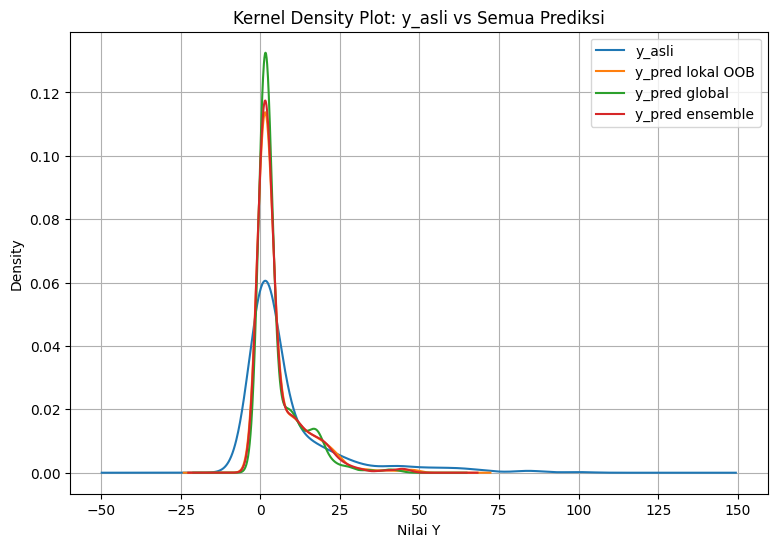

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

LMResults2['y_asli'].plot(kind='kde', label='y_asli')
LMResults2['LM_yOOB'].plot(kind='kde', label='y_pred lokal OOB')
LMResults2['yGhat'].plot(kind='kde', label='y_pred global')
LMResults2['y_ensemble'].plot(kind='kde', label='y_pred ensemble')

plt.xlabel('Nilai Y')
plt.ylabel('Density')
plt.title('Kernel Density Plot: y_asli vs Semua Prediksi')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
LMResults2.to_excel(
    'LMResults_GWXGB_Log_Gaussian_Maret.xlsx',
    index=False
)

##### Pengecekan Autokorelasi

In [ ]:
LMResults2['Res_ensemble'] = (
    LMResults2['y_asli'] - LMResults2['y_ensemble']
)

In [ ]:
## XGBoost Global OOB
from libpysal.weights import KNN
from esda.moran import Moran
np.random.seed(7)

# residual ensemble
residual12 = LMResults2['y_asli'] - LMResults2['yGhat']

# koordinat
coords = list(zip(Coords.iloc[:, 0], Coords.iloc[:, 1]))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

# Moran's I
mi = Moran(residual12, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : 0.15649935260460862
p-value   : 0.001
z-score   : 5.7995692349855945


In [ ]:
## XGBoost Lokal OOB
from libpysal.weights import KNN
from esda.moran import Moran
np.random.seed(7)

# residual lokal OOB
residual23 = LMResults2['LM_ResOOB']

# koordinat
coords = list(zip(Coords.iloc[:, 0], Coords.iloc[:, 1]))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

# Moran's I
mi = Moran(residual23, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : 0.08161621728579839
p-value   : 0.005
z-score   : 3.040899077966172


In [ ]:
## XGBoost Esemble
from libpysal.weights import KNN
from esda.moran import Moran
np.random.seed(7)

# residual ensemble
residual32 = LMResults2['y_asli'] - LMResults2['y_ensemble']

# koordinat
coords = list(zip(Coords.iloc[:, 0], Coords.iloc[:, 1]))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

# Moran's I
mi = Moran(residual32, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : 0.09697344049234256
p-value   : 0.003
z-score   : 3.6068660266646333


##### Prediksi Titik Baru

In [ ]:
# ======================================================
# 5. Prediksi titik baru
# ======================================================
hasil_prediksi_baru = predict_new_gwxgboost(
    X_train=X,
    y_train=y,
    Coords_train=Coords,
    X_new=X_baru,
    Coords_new=Coords_baru,
    BW_opt=134,
    params=xgb_params,
    Kernel='Adaptive',
    KernelFunction='Gaussian',
    spatial_weights=True,
    alpha_wt=output_model2['alpha_wt'],
    alpha_wt_type='varying',
    random_state=42,
    path_save='hasil_prediksi_baru'
)

================= Predict New Data GWXGBoost =================
Predicting new location 1 of 165
Predicting new location 2 of 165
Predicting new location 3 of 165
Predicting new location 4 of 165
Predicting new location 5 of 165
Predicting new location 6 of 165
Predicting new location 7 of 165
Predicting new location 8 of 165
Predicting new location 9 of 165
Predicting new location 10 of 165
Predicting new location 11 of 165
Predicting new location 12 of 165
Predicting new location 13 of 165
Predicting new location 14 of 165
Predicting new location 15 of 165
Predicting new location 16 of 165
Predicting new location 17 of 165
Predicting new location 18 of 165
Predicting new location 19 of 165
Predicting new location 20 of 165
Predicting new location 21 of 165
Predicting new location 22 of 165
Predicting new location 23 of 165
Predicting new location 24 of 165
Predicting new location 25 of 165
Predicting new location 26 of 165
Predicting new location 27 of 165
Predicting new location 28 o

In [ ]:
# ======================================================
# 6. Lihat hasil prediksi
# ======================================================
hasil_prediksi_baru['Prediction_New']

,IDS_new,Nearest_Train_ID,Distance_to_Nearest,Local_Pred,Global_Pred,alpha_wt_type,alpha_source,alpha_wt,beta_wt,Ensemble_Pred,Top_Features
0,0,203,0.500000,0.174436,0.961874,varying,nearest_train_id_203,1.0,0.0,0.174436,"o2, zos, thetao, vo, mlotst"
1,1,204,0.500000,0.239836,0.862470,varying,nearest_train_id_204,1.0,0.0,0.239836,"vo, chl, zos, nppv, mlotst"
2,2,205,0.500000,0.236787,0.786600,varying,nearest_train_id_205,1.0,0.0,0.236787,"chl, nppv, o2, vo, zos"
3,3,207,0.707107,0.143262,0.997068,varying,nearest_train_id_207,1.0,0.0,0.143262,"chl, nppv, o2, vo, uo"
4,4,207,0.500000,0.206211,1.057109,varying,nearest_train_id_207,1.0,0.0,0.206211,"nppv, vo, chl, so, o2"
...,...,...,...,...,...,...,...,...,...,...,...
160,160,188,0.500000,0.761150,2.044844,varying,nearest_train_id_188,1.0,0.0,0.761150,"thetao, o2, nppv, zos, mlotst"
161,161,181,0.500000,0.392676,0.658275,varying,nearest_train_id_181,1.0,0.0,0.392676,"o2, thetao, zos, mlotst, vo"
162,162,177,0.500000,0.503670,0.846540,varying,nearest_train_id_177,1.0,0.0,0.503670,"o2, zos, thetao, chl, vo"
163,163,198,0.500000,0.784851,1.499478,varying,nearest_train_id_198,1.0,0.0,0.784851,"o2, thetao, zos, vo, so"


In [ ]:
# ======================================================
# 6. Lihat hasil prediksi
# ======================================================
Feature_Importance_New = hasil_prediksi_baru['Feature_Importance_New']
# Simpan ke Excel
Feature_Importance_New.to_excel(
    'Feature_Importance_New_Gaussian_Maret.xlsx',
    index=False
)

In [ ]:
# Gabungkan hasil prediksi ke data_baru
prediksi['Pred_Local_Gaussian'] = hasil_prediksi_baru['Prediction_New']['Local_Pred']
prediksi['Pred_Global_Gaussian'] = hasil_prediksi_baru['Prediction_New']['Global_Pred']
prediksi['Pred_Ensemble_Gaussian'] = hasil_prediksi_baru['Prediction_New']['Ensemble_Pred']

# Simpan ke Excel
prediksi.to_excel(
    'hasil_prediksi_data_baru_Maret.xlsx',
    index=False
)

## XGBoost Lokal Tweedie

### Optimasi Bandwith

In [ ]:
def optimize_bw_gw_xgboost_tweedie(
    X, y, Coords, params,
    bw_min, bw_max, step=1,
    Kernel='Adaptive',
    KernelFunction='Bisquare',
    spatial_weights=True,
    n_splits=3,
    max_iter=30,
    tol=1e-3,
    path_save=False
):
    """
    Optimasi bandwidth GWXGBoost Tweedie:
    - Y tidak ditransformasi log
    - Model lokal menggunakan objective='reg:tweedie'
    - Pemilihan bandwidth berdasarkan CV_MAE terkecil pada skala asli
    """

    import os
    import numpy as np
    import pandas as pd
    from scipy.spatial import distance_matrix
    from sklearn.model_selection import KFold, GridSearchCV
    from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
    from xgboost import XGBRegressor

    try:
        from sklearn.metrics import root_mean_squared_error
        def rmse_func(y_true, y_pred):
            return root_mean_squared_error(y_true, y_pred)
    except ImportError:
        def rmse_func(y_true, y_pred):
            return mean_squared_error(y_true, y_pred, squared=False)

    # =========================================================
    # Validasi data
    # =========================================================
    X = pd.DataFrame(X).reset_index(drop=True).copy()
    y = pd.Series(np.ravel(y), name='y_asli').reset_index(drop=True).copy()
    Coords = pd.DataFrame(Coords).reset_index(drop=True).copy()

    if (y < 0).any():
        raise ValueError("Semua nilai y harus >= 0 untuk objective Tweedie.")

    if len(X) != len(y) or len(X) != len(Coords):
        raise ValueError("Panjang X, y, dan Coords harus sama.")

    if Kernel not in ['Adaptive', 'Fixed']:
        raise ValueError("Kernel harus 'Adaptive' atau 'Fixed'.")

    if KernelFunction not in ['Bisquare', 'Gaussian']:
        raise ValueError("KernelFunction harus 'Bisquare' atau 'Gaussian'.")

    # =========================================================
    # Pastikan objective Tweedie digunakan
    # =========================================================
    params = params.copy()
    params['objective'] = 'reg:tweedie'

    if 'tweedie_variance_power' not in params:
        params['tweedie_variance_power'] = 1.5

    # =========================================================
    # Param grid sederhana
    # Bisa diperluas sesuai kebutuhan
    # =========================================================
    param_grid = {
        'reg_alpha': [params.get('reg_alpha', 0)]
    }

    # =========================================================
    # Scoring CV berdasarkan skala asli
    # =========================================================
    def scorer_neg_mae_original(estimator, X_val, y_val):
        y_pred = estimator.predict(X_val)
        y_pred = np.clip(y_pred, a_min=0, a_max=None)
        return -mean_absolute_error(y_val, y_pred)

    def scorer_neg_rmse_original(estimator, X_val, y_val):
        y_pred = estimator.predict(X_val)
        y_pred = np.clip(y_pred, a_min=0, a_max=None)
        return -rmse_func(y_val, y_pred)

    def scorer_r2_original(estimator, X_val, y_val):
        y_pred = estimator.predict(X_val)
        y_pred = np.clip(y_pred, a_min=0, a_max=None)
        return r2_score(y_val, y_pred)

    scoring = {
        'neg_mean_absolute_error_original': scorer_neg_mae_original,
        'neg_root_mean_squared_error_original': scorer_neg_rmse_original,
        'r2_original': scorer_r2_original
    }

    print("================= Optimizing bandwidth =================")
    print(f"Bandwidth mode : {Kernel}")
    print(f"Kernel function: {KernelFunction}")
    print(f"Spatial weights: {spatial_weights}")
    print("Model objective: reg:tweedie")
    print(f"Tweedie variance power: {params['tweedie_variance_power']}")
    print("Selection rule : minimum CV_MAE on original scale")

    num_rows = len(X)
    DistanceMatrix_ij = pd.DataFrame(distance_matrix(Coords, Coords))

    if Kernel == 'Adaptive':
        bw_min = int(bw_min)
        bw_max = min(int(bw_max), num_rows - 1)
        step = int(step)

        if bw_min < 1:
            raise ValueError("Untuk Adaptive, bw_min minimal 1.")
        if bw_min > bw_max:
            raise ValueError("Untuk Adaptive, bw_min harus <= bw_max.")
        if step < 1:
            raise ValueError("Untuk Adaptive, step minimal 1.")

    else:
        bw_min = float(bw_min)
        bw_max = float(bw_max)

        if bw_min <= 0 or bw_max <= 0 or bw_min >= bw_max:
            raise ValueError("Untuk Fixed, pastikan 0 < bw_min < bw_max.")

    results_cache = {}

    # =========================================================
    # Bobot spasial
    # =========================================================
    def calc_spatial_weights(dist_series, h):
        dist_series = pd.Series(dist_series).astype(float)
        h = max(float(h), 1e-12)

        if KernelFunction == 'Bisquare':
            w = (1 - (dist_series.pow(2) / (h ** 2))).pow(2)
            w[dist_series >= h] = 0.0
        elif KernelFunction == 'Gaussian':
            w = np.exp(-0.5 * (dist_series / h) ** 2)
        else:
            raise ValueError("KernelFunction tidak dikenal.")

        return np.asarray(w, dtype=float)

    def bw_key(b):
        if Kernel == 'Adaptive':
            return int(round(b))
        else:
            return round(float(b), 10)

    # =========================================================
    # Evaluasi satu bandwidth
    # =========================================================
    def evaluate_bandwidth(b):
        if Kernel == 'Adaptive':
            b_eval = int(round(b))
            b_eval = max(int(bw_min), min(int(bw_max), b_eval))
            bw_label = f"{b_eval:d}"
        else:
            b_eval = float(b)
            if b_eval <= 0:
                return {
                    'BW': b_eval,
                    'R2_asli': np.nan,
                    'MAE_asli': np.nan,
                    'RMSE_asli': np.nan,
                    'CV_MAE': np.inf,
                    'LMResults': None,
                    'status': 'bw harus > 0'
                }
            bw_label = f"{b_eval:.6f}"

        key = bw_key(b_eval)
        if key in results_cache:
            return results_cache[key]

        listIDs = []
        yt_asli = []
        LM_yOOB_asli = []
        LM_ResOOB_asli = []

        failed_reason = None

        for i in range(num_rows):
            Neighbours = pd.DataFrame(DistanceMatrix_ij.iloc[:, i])
            Neighbours.columns = ['Distance']

            Data = pd.concat([X, y, Neighbours], axis=1)
            DataSorted = Data.sort_values(by='Distance').reset_index(drop=True)

            # Titik pusat sebagai OOB
            XcentralOOB = pd.DataFrame(DataSorted.iloc[0, :-2]).T
            YcentralOOB_asli = float(DataSorted.iloc[0, -2])

            if Kernel == 'Adaptive':
                knn = int(b_eval)
                LocalData = DataSorted.iloc[1:knn + 1, :].copy()

                if LocalData.shape[0] < n_splits:
                    failed_reason = (
                        f"bw={b_eval} gagal: jumlah data lokal < n_splits "
                        f"pada lokasi ke-{i}"
                    )
                    break

                h = float(LocalData['Distance'].max())

            else:
                LocalData = DataSorted[DataSorted.Distance < b_eval].copy()
                LocalData = LocalData.iloc[1:, :]

                if LocalData.shape[0] < n_splits:
                    failed_reason = (
                        f"bw={b_eval:.6f} gagal: jumlah data lokal < n_splits "
                        f"pada lokasi ke-{i}"
                    )
                    break

                h = float(b_eval)

            h = max(h, 1e-12)

            LocalX = LocalData.iloc[:, :-2]
            LocalY = LocalData.iloc[:, -2]

            if spatial_weights:
                SpatialWeights = calc_spatial_weights(LocalData['Distance'], h)
            else:
                SpatialWeights = None

            model = XGBRegressor(**params)

            kfold = KFold(
                n_splits=n_splits,
                shuffle=True,
                random_state=7
            )

            grid_search = GridSearchCV(
                estimator=model,
                param_grid=param_grid,
                scoring=scoring,
                refit='neg_mean_absolute_error_original',
                return_train_score=True,
                n_jobs=-1,
                cv=kfold
            )

            try:
                if spatial_weights:
                    grid_result = grid_search.fit(
                        LocalX,
                        LocalY,
                        sample_weight=SpatialWeights
                    )
                else:
                    grid_result = grid_search.fit(LocalX, LocalY)

                best_model = grid_result.best_estimator_

                yOOB_asli = float(best_model.predict(XcentralOOB)[0])
                yOOB_asli = max(yOOB_asli, 0.0)

            except Exception as e:
                failed_reason = f"bw={bw_label} gagal pada lokasi ke-{i}: {str(e)}"
                break

            listIDs.append(i)
            yt_asli.append(YcentralOOB_asli)
            LM_yOOB_asli.append(yOOB_asli)
            LM_ResOOB_asli.append(YcentralOOB_asli - yOOB_asli)

        if failed_reason is not None:
            result = {
                'BW': b_eval,
                'R2_asli': np.nan,
                'MAE_asli': np.nan,
                'RMSE_asli': np.nan,
                'CV_MAE': np.inf,
                'LMResults': None,
                'status': failed_reason
            }

            results_cache[key] = result
            print(f"bw={bw_label}, CV_MAE=inf")
            print(f"   alasan: {failed_reason}")
            return result

        LMResults = pd.DataFrame({
            'IDS': listIDs,
            'y_asli': yt_asli,
            'LM_yOOB_asli': LM_yOOB_asli,
            'LM_ResOOB_asli': LM_ResOOB_asli
        })

        y_true_asli = LMResults['y_asli']
        y_pred_asli = LMResults['LM_yOOB_asli']

        R2_asli = r2_score(y_true_asli, y_pred_asli)
        MAE_asli = mean_absolute_error(y_true_asli, y_pred_asli)
        RMSE_asli = rmse_func(y_true_asli, y_pred_asli)

        CV_MAE = MAE_asli

        result = {
            'BW': b_eval,
            'R2_asli': R2_asli,
            'MAE_asli': MAE_asli,
            'RMSE_asli': RMSE_asli,
            'CV_MAE': CV_MAE,
            'LMResults': LMResults,
            'status': 'ok'
        }

        results_cache[key] = result

        print(
            f"bw={bw_label}, "
            f"CV_MAE={CV_MAE:.6f}, "
            f"R2={R2_asli:.6f}, "
            f"RMSE={RMSE_asli:.6f}"
        )

        return result

    # =========================================================
    # Adaptive: Grid Search
    # =========================================================
    def optimize_adaptive_grid():
        bw_candidates = list(range(int(bw_min), int(bw_max) + 1, int(step)))

        if len(bw_candidates) == 0:
            raise ValueError("Tidak ada kandidat bandwidth adaptive.")

        print("Optimization method: Grid Search (Adaptive)")

        for bw in bw_candidates:
            evaluate_bandwidth(bw)

    # =========================================================
    # Fixed: Golden Section Ratio
    # =========================================================
    def optimize_fixed_golden():
        a = float(bw_min)
        b = float(bw_max)

        phi = (1 + np.sqrt(5)) / 2
        invphi = 1 / phi

        c = b - (b - a) * invphi
        d = a + (b - a) * invphi

        fc = evaluate_bandwidth(c)['CV_MAE']
        fd = evaluate_bandwidth(d)['CV_MAE']

        iter_count = 0

        print("Optimization method: Golden Section Ratio (Fixed)")

        while abs(b - a) > tol and iter_count < max_iter:
            if fc <= fd:
                b = d
                d = c
                fd = fc
                c = b - (b - a) * invphi
                fc = evaluate_bandwidth(c)['CV_MAE']
            else:
                a = c
                c = d
                fc = fd
                d = a + (b - a) * invphi
                fd = evaluate_bandwidth(d)['CV_MAE']

            iter_count += 1
            print(f"[Golden iter {iter_count}] interval bw = [{a:.6f}, {b:.6f}]")

        mid = (a + b) / 2.0
        refine_points = np.unique([a, c, mid, d, b])

        for bw_val in refine_points:
            evaluate_bandwidth(float(bw_val))

    # =========================================================
    # Jalankan optimasi
    # =========================================================
    if Kernel == 'Adaptive':
        optimize_adaptive_grid()
    else:
        optimize_fixed_golden()

    # =========================================================
    # Rekap hasil bandwidth
    # =========================================================
    BW_results = pd.DataFrame([
        {
            'BW': v['BW'],
            'R2_asli': v['R2_asli'],
            'MAE_asli': v['MAE_asli'],
            'RMSE_asli': v['RMSE_asli'],
            'CV_MAE': v['CV_MAE'],
            'status': v['status']
        }
        for v in results_cache.values()
    ]).sort_values(by='BW').reset_index(drop=True)

    BW_results_valid = (
        BW_results
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=['CV_MAE'])
    )

    if BW_results_valid.empty:
        raise ValueError("Semua kandidat bandwidth gagal dievaluasi. Coba perbesar bandwidth.")

    idx_best = BW_results_valid['CV_MAE'].idxmin()
    BW_opt = BW_results_valid.loc[idx_best, 'BW']
    CV_MAE_min = float(BW_results_valid.loc[idx_best, 'CV_MAE'])

    if Kernel == 'Adaptive':
        BW_opt = int(round(BW_opt))
    else:
        BW_opt = float(BW_opt)

    best_result = evaluate_bandwidth(BW_opt)
    best_LMResults = best_result['LMResults']

    print("=========================================================================")

    if Kernel == 'Adaptive':
        print(f"Best bandwidth        : {BW_opt}")
    else:
        print(f"Best bandwidth        : {BW_opt:.6f}")

    print(f"Best CV_MAE           : {CV_MAE_min:.6f}")
    print(f"R2 terbaik            : {best_result['R2_asli']:.6f}")
    print(f"MAE terbaik           : {best_result['MAE_asli']:.6f}")
    print(f"RMSE terbaik          : {best_result['RMSE_asli']:.6f}")
    print("=========================================================================")

    # =========================================================
    # Simpan hasil
    # =========================================================
    if not path_save:
        bw_path = 'BW_results_tweedie.csv'
        lm_path = 'LMResults_best_bw_tweedie.csv'
    else:
        os.makedirs(path_save, exist_ok=True)
        bw_path = os.path.join(path_save, 'BW_results_tweedie.csv')
        lm_path = os.path.join(path_save, 'LMResults_best_bw_tweedie.csv')

    BW_results.to_csv(bw_path, index=False)

    if best_LMResults is not None:
        best_LMResults.to_csv(lm_path, index=False)

    return BW_opt, BW_results, best_LMResults

In [ ]:
Coords = data[['Longitude', 'Latitude']]

In [ ]:
X = data[['so', 'thetao', 'zos','uo', 'vo', 'chl', 'o2', 'mlotst', 'nppv']]
y = data['cpue_new']
VarNames = X.columns[:]

In [ ]:
xgb_params2 = {
    "objective": "reg:tweedie",
    'tweedie_variance_power': 1.1311610724532972,
    "n_estimators": 50,
    "learning_rate": 0.1,
    "max_depth": 2,
    "subsample": 0.9,
    "colsample_bytree": 0.7,
    'gamma': 0.3,
    'reg_alpha': 1,
    'reg_lambda': 2,
    'min_child_weight': 5,
     "random_state": 42
}

#### Adaptive Bisquare

In [ ]:
BW_opt3, BW_results3, best_LMResults3 = optimize_bw_gw_xgboost_tweedie(
    X=X,
    y=y,
    Coords=Coords,
    params=xgb_params2,
    bw_min=50,
    bw_max=150,
    step=2,
    Kernel='Adaptive',
    KernelFunction='Bisquare',
    spatial_weights=True,
    n_splits=3
)

================= Optimizing bandwidth =================
Bandwidth mode : Adaptive
Kernel function: Bisquare
Spatial weights: True
Model objective: reg:tweedie
Tweedie variance power: 1.1311610724532972
Selection rule : minimum CV_MAE on original scale
Optimization method: Grid Search (Adaptive)
bw=50, CV_MAE=5.523196, R2=0.440952, RMSE=11.569931
bw=52, CV_MAE=5.516884, R2=0.447353, RMSE=11.503504
bw=54, CV_MAE=5.554203, R2=0.451479, RMSE=11.460480
bw=56, CV_MAE=5.552129, R2=0.448977, RMSE=11.486584
bw=58, CV_MAE=5.567299, R2=0.442037, RMSE=11.558702
bw=60, CV_MAE=5.598093, R2=0.442091, RMSE=11.558137
bw=62, CV_MAE=5.560761, R2=0.454708, RMSE=11.426693
bw=64, CV_MAE=5.553760, R2=0.452836, RMSE=11.446293
bw=66, CV_MAE=5.555290, R2=0.450523, RMSE=11.470463
bw=68, CV_MAE=5.530413, R2=0.455664, RMSE=11.416675
bw=70, CV_MAE=5.520396, R2=0.456845, RMSE=11.404284
bw=72, CV_MAE=5.574014, R2=0.447743, RMSE=11.499442
bw=74, CV_MAE=5.511738, R2=0.460517, RMSE=11.365674
bw=76, CV_MAE=5.517204, R2=

#### Adaptive Gaussian

In [ ]:
BW_opt4, BW_results4, best_LMResults4 = optimize_bw_gw_xgboost_tweedie(
    X=X,
    y=y,
    Coords=Coords,
    params=xgb_params2,
    bw_min=50,
    bw_max=150,
    step=2,
    Kernel='Adaptive',
    KernelFunction='Gaussian',
    spatial_weights=True,
    n_splits=3
)

================= Optimizing bandwidth =================
Bandwidth mode : Adaptive
Kernel function: Gaussian
Spatial weights: True
Model objective: reg:tweedie
Tweedie variance power: 1.1311610724532972
Selection rule : minimum CV_MAE on original scale
Optimization method: Grid Search (Adaptive)
bw=50, CV_MAE=5.565116, R2=0.461634, RMSE=11.353901
bw=52, CV_MAE=5.586536, R2=0.450034, RMSE=11.475570
bw=54, CV_MAE=5.575356, R2=0.455814, RMSE=11.415102
bw=56, CV_MAE=5.619462, R2=0.461315, RMSE=11.357262
bw=58, CV_MAE=5.598446, R2=0.461368, RMSE=11.356700
bw=60, CV_MAE=5.551215, R2=0.473451, RMSE=11.228603
bw=62, CV_MAE=5.578262, R2=0.470131, RMSE=11.263942
bw=64, CV_MAE=5.483090, R2=0.482793, RMSE=11.128547
bw=66, CV_MAE=5.522506, R2=0.475626, RMSE=11.205380
bw=68, CV_MAE=5.536765, R2=0.468610, RMSE=11.280098
bw=70, CV_MAE=5.536977, R2=0.490354, RMSE=11.046903
bw=72, CV_MAE=5.544402, R2=0.480710, RMSE=11.150931
bw=74, CV_MAE=5.514580, R2=0.485663, RMSE=11.097622
bw=76, CV_MAE=5.510054, R2=

### Pemodelan XGBoost Lokal

In [ ]:
def build_local_gwxgboost_tweedie(
    X, y, Coords, BW_opt, params,
    Kernel='Adaptive',
    KernelFunction='Bisquare',
    spatial_weights=True,
    n_splits=3,
    feat_importance='gain',
    alpha_wt_type='varying',
    alpha_wt=0.5,
    random_state=42,
    path_save=False
):
    import os
    import numpy as np
    import pandas as pd

    from scipy.spatial import distance_matrix
    from sklearn.model_selection import KFold, cross_validate
    from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
    from xgboost import XGBRegressor

    try:
        from sklearn.metrics import root_mean_squared_error

        def rmse_func(y_true, y_pred):
            return root_mean_squared_error(y_true, y_pred)

    except ImportError:

        def rmse_func(y_true, y_pred):
            return mean_squared_error(y_true, y_pred, squared=False)

    # ======================================================
    # Validasi data
    # ======================================================
    X = pd.DataFrame(X).reset_index(drop=True).copy()
    y = pd.Series(np.ravel(y), name='y_asli').reset_index(drop=True).copy()
    Coords = pd.DataFrame(Coords).reset_index(drop=True).copy()

    if (y < 0).any():
        raise ValueError("Semua nilai y harus >= 0 untuk objective Tweedie.")

    if len(X) != len(y) or len(X) != len(Coords):
        raise ValueError("Panjang X, y, dan Coords harus sama.")

    if Kernel not in ['Adaptive', 'Fixed']:
        raise ValueError("Kernel harus 'Adaptive' atau 'Fixed'.")

    if KernelFunction not in ['Bisquare', 'Gaussian']:
        raise ValueError("KernelFunction harus 'Bisquare' atau 'Gaussian'.")

    if alpha_wt_type not in ['fixed', 'varying']:
        raise ValueError("alpha_wt_type harus 'fixed' atau 'varying'.")

    if alpha_wt < 0 or alpha_wt > 1:
        raise ValueError("alpha_wt harus berada antara 0 dan 1.")

    # ======================================================
    # Parameter Tweedie
    # ======================================================
    params = params.copy()
    params['objective'] = 'reg:tweedie'

    if 'tweedie_variance_power' not in params:
        params['tweedie_variance_power'] = 1.5

    params['random_state'] = random_state

    num_rows = len(X)
    feature_names = list(X.columns)

    DistanceMatrix_ij = pd.DataFrame(distance_matrix(Coords, Coords))

    # ======================================================
    # Model global penuh untuk peubah penting global
    # Berdasarkan nilai gain
    # ======================================================
    global_model_full = XGBRegressor(
        **params,
        importance_type='gain'
    )

    global_model_full.fit(X, y)

    # Ambil nilai gain dari booster
    global_gain_dict = global_model_full.get_booster().get_score(
        importance_type='gain'
    )

    # Susun semua peubah agar tetap muncul,
    # termasuk peubah yang tidak pernah dipakai split
    GlobalImportance = pd.DataFrame({
        'Feature': feature_names,
        'Gain': [
            float(global_gain_dict.get(feature, 0.0))
            for feature in feature_names
        ]
    })

    # Normalisasi gain agar lebih mudah dibaca sebagai proporsi
    total_gain = GlobalImportance['Gain'].sum()

    if total_gain > 0:
        GlobalImportance['Gain_Normalized'] = (
            GlobalImportance['Gain'] / total_gain
        )
    else:
        GlobalImportance['Gain_Normalized'] = 0.0

    GlobalImportance = GlobalImportance.sort_values(
        by='Gain',
        ascending=False
    ).reset_index(drop=True)

    # ======================================================
    # Scoring CV lokal
    # ======================================================
    def scorer_neg_mae(estimator, X_val, y_val):
        y_pred = estimator.predict(X_val)
        y_pred = np.clip(y_pred, 0, None)
        return -mean_absolute_error(y_val, y_pred)

    def scorer_neg_rmse(estimator, X_val, y_val):
        y_pred = estimator.predict(X_val)
        y_pred = np.clip(y_pred, 0, None)
        return -rmse_func(y_val, y_pred)

    scoring = {
        'neg_mae': scorer_neg_mae,
        'neg_rmse': scorer_neg_rmse,
        'r2': 'r2'
    }

    # ======================================================
    # Bobot spasial
    # ======================================================
    def calc_spatial_weights(dist_series, h):
        dist_series = pd.Series(dist_series).astype(float)
        h = max(float(h), 1e-12)

        if KernelFunction == 'Bisquare':
            w = (1 - (dist_series.pow(2) / (h ** 2))).pow(2)
            w[dist_series >= h] = 0.0

        elif KernelFunction == 'Gaussian':
            w = np.exp(-0.5 * (dist_series / h) ** 2)

        return np.asarray(w, dtype=float)

    results = []
    importance_rows = []
    bestLocalModel = []

    print("================= Building Local GWXGBoost Tweedie =================")
    print("================= Global importance by gain has been calculated =================")

    # ======================================================
    # Loop model lokal
    # ======================================================
    for i in range(num_rows):

        print(f"Calculating local model {i + 1} of {num_rows}")

        Neighbours = pd.DataFrame(DistanceMatrix_ij.iloc[:, i])
        Neighbours.columns = ['Distance']

        Data = pd.concat([X, y, Neighbours], axis=1)
        DataSorted = Data.sort_values(by='Distance').reset_index(drop=True)

        XcentralOOB = pd.DataFrame(DataSorted.iloc[0, :-2]).T
        XcentralOOB.columns = X.columns

        YcentralOOB = float(DataSorted.iloc[0, -2])

        # ==================================================
        # Local data OOB dan full
        # ==================================================
        if Kernel == 'Adaptive':
            knn = int(BW_opt)

            LocalData = DataSorted.iloc[1:knn + 1, :].copy()
            LocalDataFull = DataSorted.iloc[:knn + 1, :].copy()

            if LocalData.shape[0] < n_splits:
                raise ValueError(
                    f"Jumlah data lokal lokasi ke-{i} kurang dari n_splits."
                )

            h = float(LocalData['Distance'].max())

        else:
            bw = float(BW_opt)

            LocalData = DataSorted[DataSorted.Distance < bw].copy()
            LocalData = LocalData.iloc[1:, :].copy()

            LocalDataFull = DataSorted[DataSorted.Distance < bw].copy()

            if LocalData.shape[0] < n_splits:
                raise ValueError(
                    f"Jumlah data lokal lokasi ke-{i} kurang dari n_splits."
                )

            h = bw

        h = max(h, 1e-12)

        LocalX = LocalData.iloc[:, :-2]
        LocalY = LocalData.iloc[:, -2]

        LocalXFull = LocalDataFull.iloc[:, :-2]
        LocalYFull = LocalDataFull.iloc[:, -2]

        LocalX.columns = X.columns
        LocalXFull.columns = X.columns

        if spatial_weights:
            SpatialWeights = calc_spatial_weights(LocalData['Distance'], h)
            SpatialWeightsFull = calc_spatial_weights(LocalDataFull['Distance'], h)
        else:
            SpatialWeights = None
            SpatialWeightsFull = None

        # ==================================================
        # Model lokal OOB
        # ==================================================
        local_model = XGBRegressor(
            **params,
            importance_type=feat_importance
        )

        if spatial_weights:
            local_model.fit(
                LocalX,
                LocalY,
                sample_weight=SpatialWeights
            )
        else:
            local_model.fit(LocalX, LocalY)

        bestLocalModel.append(local_model)

        LM_yOOB = float(local_model.predict(XcentralOOB)[0])
        LM_yOOB = max(LM_yOOB, 0.0)

        LM_ResOOB = YcentralOOB - LM_yOOB

        # ==================================================
        # CV lokal MAE, RMSE, R2
        # ==================================================
        kfold = KFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=random_state
        )

        try:
            if spatial_weights:
                cv_result = cross_validate(
                    local_model,
                    LocalX,
                    LocalY,
                    scoring=scoring,
                    cv=kfold,
                    params={'sample_weight': SpatialWeights},
                    n_jobs=-1
                )
            else:
                cv_result = cross_validate(
                    local_model,
                    LocalX,
                    LocalY,
                    scoring=scoring,
                    cv=kfold,
                    n_jobs=-1
                )

        except TypeError:
            try:
                if spatial_weights:
                    cv_result = cross_validate(
                        local_model,
                        LocalX,
                        LocalY,
                        scoring=scoring,
                        cv=kfold,
                        fit_params={'sample_weight': SpatialWeights},
                        n_jobs=-1
                    )
                else:
                    cv_result = cross_validate(
                        local_model,
                        LocalX,
                        LocalY,
                        scoring=scoring,
                        cv=kfold,
                        n_jobs=-1
                    )

            except TypeError:
                cv_result = cross_validate(
                    local_model,
                    LocalX,
                    LocalY,
                    scoring=scoring,
                    cv=kfold,
                    n_jobs=-1
                )

        LM_Best_score_MAE = -np.mean(cv_result['test_neg_mae'])
        LM_Best_score_RMSE = -np.mean(cv_result['test_neg_rmse'])
        LMRsqr = np.mean(cv_result['test_r2'])

        # ==================================================
        # Model lokal full: including central point
        # ==================================================
        local_model_full = XGBRegressor(
            **params,
            importance_type=feat_importance
        )

        if spatial_weights:
            local_model_full.fit(
                LocalXFull,
                LocalYFull,
                sample_weight=SpatialWeightsFull
            )
        else:
            local_model_full.fit(LocalXFull, LocalYFull)

        LM_yPred = float(local_model_full.predict(XcentralOOB)[0])
        LM_yPred = max(LM_yPred, 0.0)

        # ==================================================
        # Model global excluding central point
        # Global OOB prediction
        # ==================================================
        X_global = X.drop(index=i).reset_index(drop=True)
        y_global = y.drop(index=i).reset_index(drop=True)

        global_model = XGBRegressor(
            **params,
            importance_type=feat_importance
        )

        global_model.fit(X_global, y_global)

        yGhat = float(global_model.predict(X.iloc[[i]])[0])
        yGhat = max(yGhat, 0.0)

        # ==================================================
        # Alpha ensemble mengikuti konsep GeoXGBoost
        # ==================================================
        res_local = YcentralOOB - LM_yOOB
        res_global = YcentralOOB - yGhat

        if alpha_wt_type == 'fixed':
            Alpha_wt = float(alpha_wt)

        elif alpha_wt_type == 'varying':
            if alpha_wt == 1:
                Alpha_wt = 1.0
            else:
                if abs(res_global) > abs(res_local):
                    Alpha_wt = 1.0
                else:
                    Alpha_wt = float(alpha_wt)

        beta_wt = 1 - Alpha_wt

        y_ensemble = Alpha_wt * LM_yOOB + beta_wt * yGhat
        y_ensemble = max(float(y_ensemble), 0.0)

        # ==================================================
        # Feature importance lokal
        # ==================================================
        Imp_ = local_model.feature_importances_

        imp_dict = {
            f'Imp_{feature_names[j]}': float(Imp_[j])
            for j in range(len(feature_names))
        }

        MaxImportance = float(np.max(Imp_))
        MaxFeatureID = feature_names[int(np.argmax(Imp_))]

        importance_rows.append({
            'IDS': i,
            **imp_dict
        })

        results.append({
            'IDS': i,
            'y_asli': YcentralOOB,

            'LM_yPred': LM_yPred,
            'LM_yOOB': LM_yOOB,
            'LM_ResOOB': LM_ResOOB,

            'LMRsqr': LMRsqr,
            'LM_Best_score_MAE': LM_Best_score_MAE,
            'LM_Best_score_RMSE': LM_Best_score_RMSE,

            'alpha_wt': Alpha_wt,
            'yGhat': yGhat,
            'y_ensemble': y_ensemble,

            'MaxImportance': MaxImportance,
            'MaxFeatureID': MaxFeatureID
        })

    # ======================================================
    # Gabungkan hasil lokal
    # ======================================================
    LMResults = pd.DataFrame(results)
    LocalImportance = pd.DataFrame(importance_rows)

    LMResults = LMResults.merge(
        LocalImportance,
        on='IDS',
        how='left'
    )

    # ======================================================
    # Ringkasan peubah penting lokal
    # ======================================================
    local_imp_cols = [
        col for col in LMResults.columns
        if col.startswith('Imp_')
    ]

    LocalImportanceSummary = []

    for col in local_imp_cols:
        feature = col.replace('Imp_', '')

        LocalImportanceSummary.append({
            'Feature': feature,
            'Mean_Local_Importance': LMResults[col].mean(),
            'Median_Local_Importance': LMResults[col].median(),
            'Std_Local_Importance': LMResults[col].std(),
            'Min_Local_Importance': LMResults[col].min(),
            'Max_Local_Importance': LMResults[col].max(),
            'Frequency_As_MaxFeature': (LMResults['MaxFeatureID'] == feature).sum(),
            'Proportion_As_MaxFeature': (
                (LMResults['MaxFeatureID'] == feature).sum() / len(LMResults)
            )
        })

    LocalImportanceSummary = pd.DataFrame(LocalImportanceSummary)

    LocalImportanceSummary = LocalImportanceSummary.sort_values(
        by='Mean_Local_Importance',
        ascending=False
    ).reset_index(drop=True)

    # ======================================================
    # Evaluasi keseluruhan data
    # ======================================================
    y_true = LMResults['y_asli']

    Evaluation_Results = pd.DataFrame({
        'Model': [
            'Local XGBoost Tweedie - Pred',
            'Local XGBoost Tweedie - OOB',
            'Global XGBoost Tweedie - OOB',
            'Ensemble Local + Global'
        ],
        'Kolom_Prediksi': [
            'LM_yPred',
            'LM_yOOB',
            'yGhat',
            'y_ensemble'
        ],
        'R2': [
            r2_score(y_true, LMResults['LM_yPred']),
            r2_score(y_true, LMResults['LM_yOOB']),
            r2_score(y_true, LMResults['yGhat']),
            r2_score(y_true, LMResults['y_ensemble'])
        ],
        'MAE': [
            mean_absolute_error(y_true, LMResults['LM_yPred']),
            mean_absolute_error(y_true, LMResults['LM_yOOB']),
            mean_absolute_error(y_true, LMResults['yGhat']),
            mean_absolute_error(y_true, LMResults['y_ensemble'])
        ],
        'RMSE': [
            rmse_func(y_true, LMResults['LM_yPred']),
            rmse_func(y_true, LMResults['LM_yOOB']),
            rmse_func(y_true, LMResults['yGhat']),
            rmse_func(y_true, LMResults['y_ensemble'])
        ]
    })

    # ======================================================
    # Simpan hasil
    # ======================================================
    if path_save:
        os.makedirs(path_save, exist_ok=True)

        LMResults.to_csv(
            os.path.join(path_save, 'LocalModelResults_GWXGB_Tweedie.csv'),
            index=False
        )

        Evaluation_Results.to_csv(
            os.path.join(path_save, 'Evaluation_GWXGB_Tweedie.csv'),
            index=False
        )

        GlobalImportance.to_csv(
            os.path.join(path_save, 'GlobalImportance_GWXGB_Tweedie_Gain.csv'),
            index=False
        )

        LocalImportanceSummary.to_csv(
            os.path.join(path_save, 'LocalImportanceSummary_GWXGB_Tweedie.csv'),
            index=False
        )

    output = {
        'Prediction': LMResults,
        'Evaluation': Evaluation_Results,
        'GlobalImportance': GlobalImportance,
        'LocalImportanceSummary': LocalImportanceSummary,
        'bestLocalModel': bestLocalModel,
        'globalModelFull': global_model_full,
        'alpha_wt': LMResults['alpha_wt'].tolist()
    }

    return output

#### Adaptive Bisquare

In [ ]:
output_model3 = build_local_gwxgboost_tweedie(
    X=X,
    y=y,
    Coords=Coords,
    BW_opt=102,
    params=xgb_params2,
    Kernel='Adaptive',
    KernelFunction='Bisquare',
    spatial_weights=True,
    n_splits=3,
    feat_importance='gain',
    alpha_wt_type='varying',
    alpha_wt=0.5,
    random_state=42,
    path_save='hasil_model_lokal'
)

================= Building Local GWXGBoost Tweedie =================
================= Global importance by gain has been calculated =================
Calculating local model 1 of 445
Calculating local model 2 of 445
Calculating local model 3 of 445
Calculating local model 4 of 445
Calculating local model 5 of 445
Calculating local model 6 of 445
Calculating local model 7 of 445
Calculating local model 8 of 445
Calculating local model 9 of 445
Calculating local model 10 of 445
Calculating local model 11 of 445
Calculating local model 12 of 445
Calculating local model 13 of 445
Calculating local model 14 of 445
Calculating local model 15 of 445
Calculating local model 16 of 445
Calculating local model 17 of 445
Calculating local model 18 of 445
Calculating local model 19 of 445
Calculating local model 20 of 445
Calculating local model 21 of 445
Calculating local model 22 of 445
Calculating local model 23 of 445
Calculating local model 24 of 445
Calculating local model 25 of 445
Calculat

In [ ]:
LMResults3 = output_model3['Prediction']
Evaluation_Results3 = output_model3['Evaluation']

LMResults3.head(450)

,IDS,y_asli,LM_yPred,LM_yOOB,LM_ResOOB,LMRsqr,LM_Best_score_MAE,LM_Best_score_RMSE,alpha_wt,yGhat,...,MaxFeatureID,Imp_so,Imp_thetao,Imp_zos,Imp_uo,Imp_vo,Imp_chl,Imp_o2,Imp_mlotst,Imp_nppv
0,0,12.138553,16.041876,28.762239,-16.623686,-0.153677,17.203011,22.675673,0.5,20.302206,...,nppv,0.034115,0.114845,0.068815,0.087953,0.122271,0.079173,0.098409,0.167590,0.226829
1,1,8.620704,12.920063,23.343779,-14.723075,-0.049001,15.660014,20.619431,0.5,16.364553,...,vo,0.040823,0.125795,0.084532,0.095929,0.193034,0.077062,0.116247,0.077256,0.189322
2,2,16.722104,21.854036,36.048519,-19.326415,-0.156725,17.821981,22.112822,0.5,24.645378,...,nppv,0.058369,0.131993,0.071308,0.093283,0.115485,0.102372,0.159505,0.064599,0.203086
3,3,17.616588,16.401556,14.672732,2.943856,0.161809,14.992046,19.442905,0.5,18.717808,...,nppv,0.054579,0.104097,0.094734,0.090623,0.115297,0.088927,0.138287,0.135913,0.177541
4,4,61.991957,45.229401,28.318314,33.673643,0.139406,15.174257,19.470545,0.5,29.678280,...,nppv,0.029085,0.184347,0.072555,0.101165,0.131393,0.074768,0.129484,0.066424,0.210779
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440,440,19.300079,16.788036,3.198880,16.101198,-0.348162,3.282944,5.645107,0.5,3.533219,...,vo,0.052750,0.101591,0.106655,0.196954,0.197451,0.053160,0.081959,0.080394,0.129087
441,441,0.690572,2.480351,8.521957,-7.831385,-0.141449,3.271684,5.720759,0.5,3.613706,...,thetao,0.094585,0.140676,0.116229,0.103032,0.128575,0.123282,0.137446,0.067869,0.088306
442,442,2.059131,3.481396,5.285348,-3.226218,-0.137417,3.198597,5.517268,1.0,5.752718,...,uo,0.075893,0.080329,0.105785,0.195839,0.097838,0.155262,0.138049,0.047695,0.103308
443,443,9.879915,9.718193,8.975554,0.904361,-0.182729,3.160545,5.706215,1.0,26.074131,...,o2,0.048672,0.138894,0.103544,0.135721,0.101173,0.095125,0.213732,0.060978,0.102160


In [ ]:
LMResults3.to_excel(
    'LMResults_GWXGB_Tweedie_Bisquare_Maret.xlsx',
    index=False
)

In [ ]:
Evaluation_Results3

,Model,Kolom_Prediksi,R2,MAE,RMSE
0,Local XGBoost Tweedie - Pred,LM_yPred,0.937136,2.107597,3.879789
1,Local XGBoost Tweedie - OOB,LM_yOOB,0.474852,5.507776,11.213650
2,Global XGBoost Tweedie - OOB,yGhat,0.413655,6.373073,11.849032
3,Ensemble Local + Global,y_ensemble,0.538201,5.025485,10.515568


<Figure size 900x600 with 0 Axes>

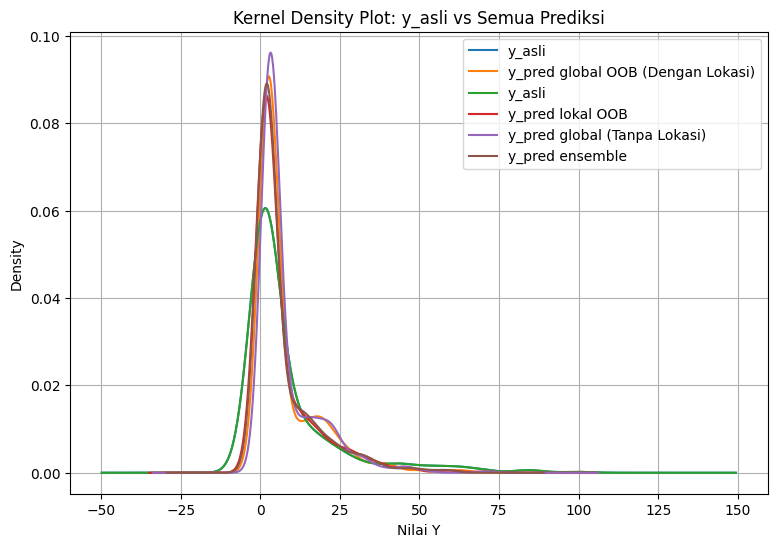

In [ ]:
LMResults = pd.read_excel("/content/LMResults_GWXGB_Tweedie_Bisquare_Maret.xlsx")
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

# ambil tabel prediksi
GlobalResults = global_oob_tweedie['Prediction']

plt.figure(figsize=(9, 6))

GlobalResults['y_asli'].plot(
    kind='kde',
    label='y_asli'
)

GlobalResults['yGhat'].plot(
    kind='kde',
    label='y_pred global OOB (Dengan Lokasi)'
)

LMResults['y_asli'].plot(kind='kde', label='y_asli')
LMResults['LM_yOOB'].plot(kind='kde', label='y_pred lokal OOB')
LMResults['yGhat'].plot(kind='kde', label='y_pred global (Tanpa Lokasi)')
LMResults['y_ensemble'].plot(kind='kde', label='y_pred ensemble')


plt.xlabel('Nilai Y')
plt.ylabel('Density')
plt.title('Kernel Density Plot: y_asli vs Semua Prediksi')
plt.legend()
plt.grid(True)
plt.show()

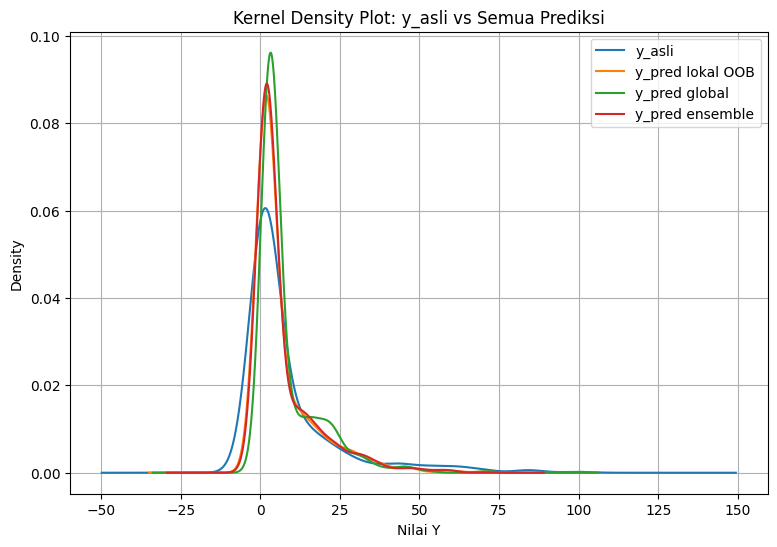

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

LMResults3['y_asli'].plot(kind='kde', label='y_asli')
LMResults3['LM_yOOB'].plot(kind='kde', label='y_pred lokal OOB')
LMResults3['yGhat'].plot(kind='kde', label='y_pred global')
LMResults3['y_ensemble'].plot(kind='kde', label='y_pred ensemble')

plt.xlabel('Nilai Y')
plt.ylabel('Density')
plt.title('Kernel Density Plot: y_asli vs Semua Prediksi')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
LMResults3['Res_ensemble'] = (
    LMResults3['y_asli'] - LMResults3['y_ensemble']
)

##### Pengecekan Efek Spasial Autokorelasi Residual

In [ ]:
## XGBoost Global OOB
from libpysal.weights import KNN
from esda.moran import Moran
np.random.seed(7)

# residual ensemble
residual_tweedie_B2 = LMResults3['y_asli'] - LMResults3['yGhat']

# koordinat
coords = list(zip(Coords.iloc[:, 0], Coords.iloc[:, 1]))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

# Moran's I
mi = Moran(residual_tweedie_B2, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : 0.10004541605850106
p-value   : 0.001
z-score   : 3.7737614465305636


In [ ]:
## XGBoost Lokal
from libpysal.weights import KNN
from esda.moran import Moran
np.random.seed(7)

# residual lokal OOB
residual_tweedie_B22 = LMResults3['LM_ResOOB']

# koordinat
coords = list(zip(Coords.iloc[:, 0], Coords.iloc[:, 1]))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

# Moran's I
mi = Moran(residual_tweedie_B22, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : -0.04721592401046602
p-value   : 0.035
z-score   : -1.6740564744299904


In [ ]:
## XGBoost esemble
from libpysal.weights import KNN
from esda.moran import Moran
np.random.seed(7)

# residual ensemble
residual_tweedie_B2 = LMResults3['y_asli'] - LMResults3['y_ensemble']

# koordinat
coords = list(zip(Coords.iloc[:, 0], Coords.iloc[:, 1]))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

# Moran's I
mi = Moran(residual_tweedie_B2, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : 0.021292634691200175
p-value   : 0.209
z-score   : 0.8631867838965721


##### Prediksi Titik Baru

In [ ]:
def predict_new_gwxgboost_tweedie(
    X_train, y_train, Coords_train,
    X_new, Coords_new,
    BW_opt, params,
    Kernel='Adaptive',
    KernelFunction='Bisquare',
    spatial_weights=True,
    feat_importance='gain',
    alpha_wt=0.5,
    alpha_wt_type='varying',
    random_state=42,
    path_save=False
):
    import os
    import numpy as np
    import pandas as pd
    from scipy.spatial import distance_matrix
    from xgboost import XGBRegressor

    # ======================================================
    # Validasi dan persiapan data
    # ======================================================
    X_train = pd.DataFrame(X_train).reset_index(drop=True).copy()
    y_train = pd.Series(np.ravel(y_train), name='y_asli').reset_index(drop=True)
    Coords_train = pd.DataFrame(Coords_train).reset_index(drop=True).copy()

    X_new = pd.DataFrame(X_new).reset_index(drop=True).copy()
    Coords_new = pd.DataFrame(Coords_new).reset_index(drop=True).copy()

    X_new.columns = X_train.columns

    if len(X_train) != len(y_train) or len(X_train) != len(Coords_train):
        raise ValueError("Panjang X_train, y_train, dan Coords_train harus sama.")

    if len(X_new) != len(Coords_new):
        raise ValueError("Panjang X_new dan Coords_new harus sama.")

    if (y_train < 0).any():
        raise ValueError("Semua nilai y_train harus >= 0 untuk objective Tweedie.")

    if Kernel not in ['Adaptive', 'Fixed']:
        raise ValueError("Kernel harus 'Adaptive' atau 'Fixed'.")

    if KernelFunction not in ['Bisquare', 'Gaussian']:
        raise ValueError("KernelFunction harus 'Bisquare' atau 'Gaussian'.")

    if alpha_wt_type not in ['fixed', 'varying']:
        raise ValueError("alpha_wt_type harus 'fixed' atau 'varying'.")

    # ======================================================
    # Persiapan alpha weight
    # ======================================================
    if alpha_wt_type == 'fixed':
        Alpha_Fixed = float(alpha_wt)

        if Alpha_Fixed < 0 or Alpha_Fixed > 1:
            raise ValueError("alpha_wt harus berada antara 0 dan 1.")

        Alpha_wtDF = None

    else:
        # Untuk varying, alpha_wt harus berisi alpha per titik training
        if isinstance(alpha_wt, dict) and 'alpha_wt' in alpha_wt:
            alpha_raw = alpha_wt['alpha_wt']

        elif isinstance(alpha_wt, pd.DataFrame):
            if 'alpha_wt' in alpha_wt.columns:
                alpha_raw = alpha_wt['alpha_wt']
            else:
                alpha_raw = alpha_wt.iloc[:, 0]

        else:
            alpha_raw = alpha_wt

        Alpha_wtDF = pd.Series(
            np.ravel(alpha_raw),
            name='alpha_wt'
        ).reset_index(drop=True)

        if len(Alpha_wtDF) != len(X_train):
            raise ValueError(
                "Untuk alpha_wt_type='varying', panjang alpha_wt harus sama "
                "dengan jumlah data training."
            )

        if ((Alpha_wtDF < 0) | (Alpha_wtDF > 1)).any():
            raise ValueError("Semua nilai alpha_wt varying harus berada antara 0 dan 1.")

        Alpha_Fixed = None

    # ======================================================
    # Parameter XGBoost Tweedie
    # ======================================================
    params = params.copy()
    params['objective'] = 'reg:tweedie'
    params['tweedie_variance_power'] = params.get(
        'tweedie_variance_power', 1.5
    )
    params['random_state'] = random_state

    # ======================================================
    # Fungsi bobot spasial
    # ======================================================
    def calc_spatial_weights(dist_series, h):
        dist_series = pd.Series(dist_series).astype(float)
        h = max(float(h), 1e-12)

        if KernelFunction == 'Bisquare':
            w = (1 - (dist_series.pow(2) / (h ** 2))).pow(2)
            w[dist_series >= h] = 0.0

        elif KernelFunction == 'Gaussian':
            w = np.exp(-0.5 * (dist_series / h) ** 2)

        return np.asarray(w, dtype=float)

    # ======================================================
    # Fungsi feature importance per lokasi
    # ======================================================
    def get_feature_importance_df(
        model,
        feature_names,
        ids_new,
        importance_type='gain'
    ):
        booster = model.get_booster()
        score = booster.get_score(importance_type=importance_type)

        importance_df = pd.DataFrame({
            'IDS_new': ids_new,
            'Feature': feature_names,
            'Importance': [
                score.get(feature, 0.0)
                for feature in feature_names
            ]
        })

        total_importance = importance_df['Importance'].sum()

        if total_importance > 0:
            importance_df['Importance_Relative'] = (
                importance_df['Importance'] / total_importance
            )
        else:
            importance_df['Importance_Relative'] = 0.0

        importance_df['Rank'] = importance_df['Importance'].rank(
            ascending=False,
            method='dense'
        ).astype(int)

        importance_df = importance_df.sort_values(
            by=['IDS_new', 'Rank', 'Importance'],
            ascending=[True, True, False]
        ).reset_index(drop=True)

        return importance_df

    # ======================================================
    # Model global Tweedie
    # ======================================================
    global_model = XGBRegressor(
        **params,
        importance_type=feat_importance
    )

    global_model.fit(X_train, y_train)

    # ======================================================
    # Distance matrix: titik baru ke titik training
    # ======================================================
    DistanceMatrix_NewTrain = pd.DataFrame(
        distance_matrix(Coords_new, Coords_train)
    )

    results = []
    local_models_new = []
    feature_importance_all = []

    print("================= Predict New Data GWXGBoost Tweedie =================")

    # ======================================================
    # Loop setiap titik baru
    # ======================================================
    for i in range(len(X_new)):

        print(f"Predicting new location {i + 1} of {len(X_new)}")

        dist_i = DistanceMatrix_NewTrain.iloc[i, :].reset_index(drop=True)

        nearest_train_id = int(dist_i.idxmin())

        DataLocal = pd.concat(
            [
                X_train,
                y_train.rename('y_asli'),
                pd.Series(dist_i, name='Distance')
            ],
            axis=1
        )

        DataLocalSorted = DataLocal.sort_values(
            by='Distance'
        ).reset_index(drop=True)

        # ==================================================
        # Ambil data lokal berdasarkan bandwidth
        # ==================================================
        if Kernel == 'Adaptive':
            knn = int(BW_opt)

            if knn < 2:
                raise ValueError("BW_opt Adaptive minimal harus 2.")

            LocalData = DataLocalSorted.iloc[:knn, :].copy()
            h = float(LocalData['Distance'].max())

        else:
            bw = float(BW_opt)

            LocalData = DataLocalSorted[
                DataLocalSorted['Distance'] < bw
            ].copy()

            h = bw

        if LocalData.shape[0] < 2:
            raise ValueError(
                f"Jumlah data lokal untuk titik baru ke-{i} terlalu sedikit."
            )

        h = max(h, 1e-12)

        LocalX = LocalData.iloc[:, :-2]
        LocalY = LocalData['y_asli']

        LocalX.columns = X_train.columns

        # ==================================================
        # Bobot spasial
        # ==================================================
        if spatial_weights:
            SpatialWeights = calc_spatial_weights(
                LocalData['Distance'], h
            )
        else:
            SpatialWeights = None

        # ==================================================
        # Model lokal Tweedie untuk titik baru
        # ==================================================
        local_model = XGBRegressor(
            **params,
            importance_type=feat_importance
        )

        if spatial_weights:
            local_model.fit(
                LocalX,
                LocalY,
                sample_weight=SpatialWeights
            )
        else:
            local_model.fit(LocalX, LocalY)

        local_models_new.append(local_model)

        # ==================================================
        # Feature importance lokal per lokasi baru
        # ==================================================
        imp_i = get_feature_importance_df(
            model=local_model,
            feature_names=list(X_train.columns),
            ids_new=i,
            importance_type=feat_importance
        )

        feature_importance_all.append(imp_i)

        top_features = (
            imp_i
            .sort_values('Importance_Relative', ascending=False)
            .head(5)['Feature']
            .tolist()
        )

        # ==================================================
        # Prediksi lokal langsung skala asli Tweedie
        # ==================================================
        y_local = float(local_model.predict(X_new.iloc[[i]])[0])
        y_local = max(y_local, 0.0)

        # ==================================================
        # Prediksi global langsung skala asli Tweedie
        # ==================================================
        y_global = float(global_model.predict(X_new.iloc[[i]])[0])
        y_global = max(y_global, 0.0)

        # ==================================================
        # Alpha weight fixed atau varying
        # ==================================================
        if alpha_wt_type == 'fixed':
            Alpha_wt = Alpha_Fixed
            Alpha_Source = 'fixed'

        else:
            Alpha_wt = float(Alpha_wtDF.iloc[nearest_train_id])
            Alpha_Source = f'nearest_train_id_{nearest_train_id}'

        Beta_wt = 1 - Alpha_wt

        # ==================================================
        # Ensemble local + global
        # ==================================================
        y_ensemble = Alpha_wt * y_local + Beta_wt * y_global
        y_ensemble = max(float(y_ensemble), 0.0)

        results.append({
            'IDS_new': i,
            'Nearest_Train_ID': nearest_train_id,
            'Distance_to_Nearest': float(dist_i.min()),
            'Local_Pred': y_local,
            'Global_Pred': y_global,
            'alpha_wt_type': alpha_wt_type,
            'alpha_source': Alpha_Source,
            'alpha_wt': Alpha_wt,
            'beta_wt': Beta_wt,
            'Ensemble_Pred': y_ensemble,
            'Top_Features': ', '.join(top_features)
        })

    Prediction_New = pd.DataFrame(results)

    Feature_Importance_New = pd.concat(
        feature_importance_all,
        ignore_index=True
    )

    # ======================================================
    # Simpan hasil
    # ======================================================
    if path_save:
        os.makedirs(path_save, exist_ok=True)

        Prediction_New.to_csv(
            os.path.join(path_save, 'Prediction_New_GWXGBoost_Tweedie.csv'),
            index=False
        )

        Feature_Importance_New.to_csv(
            os.path.join(path_save, 'Feature_Importance_New_GWXGBoost_Tweedie.csv'),
            index=False
        )

    output = {
        'Prediction_New': Prediction_New,
        'Feature_Importance_New': Feature_Importance_New,
        'local_models_new': local_models_new,
        'global_model': global_model
    }

    return output

In [ ]:
# 1) Baca Excel (sheet pertama)
prediksi = pd.read_excel("/content/data_prediksi_mar-mei.xlsx")
prediksi.info()
Coords_baru = prediksi[['Longitude', 'Latitude']]
X_baru = prediksi[['so', 'thetao', 'zos','uo', 'vo', 'chl', 'o2', 'mlotst', 'nppv']]
VarNames = X.columns[:]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         165 non-null    int64  
 1   left       165 non-null    float64
 2   top        165 non-null    float64
 3   right      165 non-null    float64
 4   bottom     165 non-null    float64
 5   row_index  165 non-null    int64  
 6   col_index  165 non-null    int64  
 7   Longitude  165 non-null    float64
 8   Latitude   165 non-null    float64
 9   periode    165 non-null    object 
 10  so         165 non-null    float64
 11  thetao     165 non-null    float64
 12  zos        165 non-null    float64
 13  uo         165 non-null    float64
 14  vo         165 non-null    float64
 15  chl        165 non-null    float64
 16  o2         165 non-null    float64
 17  mlotst     165 non-null    float64
 18  nppv       165 non-null    float64
dtypes: float64(15), int64(3), object(1)
memory usage: 

In [ ]:
# ======================================================
# 5. Prediksi titik baru
# ======================================================
hasil_prediksi_Tweedie_B = predict_new_gwxgboost_tweedie(
    X_train=X,
    y_train=y,
    Coords_train=Coords,
    X_new=X_baru,
    Coords_new=Coords_baru,
    BW_opt=102,
    params=xgb_params2,
    Kernel='Adaptive',
    KernelFunction='Bisquare',
    spatial_weights=True,
    alpha_wt=output_model3['alpha_wt'],
    alpha_wt_type='varying',
    random_state=42,
    path_save='hasil_prediksi_baru'
)

================= Predict New Data GWXGBoost Tweedie =================
Predicting new location 1 of 165
Predicting new location 2 of 165
Predicting new location 3 of 165
Predicting new location 4 of 165
Predicting new location 5 of 165
Predicting new location 6 of 165
Predicting new location 7 of 165
Predicting new location 8 of 165
Predicting new location 9 of 165
Predicting new location 10 of 165
Predicting new location 11 of 165
Predicting new location 12 of 165
Predicting new location 13 of 165
Predicting new location 14 of 165
Predicting new location 15 of 165
Predicting new location 16 of 165
Predicting new location 17 of 165
Predicting new location 18 of 165
Predicting new location 19 of 165
Predicting new location 20 of 165
Predicting new location 21 of 165
Predicting new location 22 of 165
Predicting new location 23 of 165
Predicting new location 24 of 165
Predicting new location 25 of 165
Predicting new location 26 of 165
Predicting new location 27 of 165
Predicting new locat

In [ ]:
# ======================================================
# 6. Lihat hasil prediksi
# ======================================================
hasil_prediksi_Tweedie_B['Prediction_New']

,IDS_new,Nearest_Train_ID,Distance_to_Nearest,Local_Pred,Global_Pred,alpha_wt_type,alpha_source,alpha_wt,beta_wt,Ensemble_Pred,Top_Features
0,0,203,0.500000,0.359683,3.730189,varying,nearest_train_id_203,1.0,0.0,0.359683,"zos, mlotst, nppv, vo, so"
1,1,204,0.500000,0.351508,3.341461,varying,nearest_train_id_204,1.0,0.0,0.351508,"zos, nppv, mlotst, chl, vo"
2,2,205,0.500000,0.280223,3.175966,varying,nearest_train_id_205,1.0,0.0,0.280223,"zos, vo, so, chl, thetao"
3,3,207,0.707107,0.233364,3.319140,varying,nearest_train_id_207,1.0,0.0,0.233364,"zos, so, o2, thetao, vo"
4,4,207,0.500000,0.311713,3.319140,varying,nearest_train_id_207,1.0,0.0,0.311713,"zos, so, vo, uo, thetao"
...,...,...,...,...,...,...,...,...,...,...,...
160,160,188,0.500000,0.422172,6.790561,varying,nearest_train_id_188,1.0,0.0,0.422172,"nppv, o2, so, thetao, mlotst"
161,161,181,0.500000,0.665527,1.810314,varying,nearest_train_id_181,1.0,0.0,0.665527,"nppv, vo, chl, so, zos"
162,162,177,0.500000,0.605829,3.102060,varying,nearest_train_id_177,1.0,0.0,0.605829,"nppv, mlotst, vo, zos, so"
163,163,198,0.500000,0.501187,4.029080,varying,nearest_train_id_198,1.0,0.0,0.501187,"nppv, vo, zos, chl, so"


In [ ]:
# ======================================================
# 6. Lihat hasil prediksi
# ======================================================
Feature_Importance_New = hasil_prediksi_Tweedie_B['Feature_Importance_New']
# Simpan ke Excel
Feature_Importance_New.to_excel(
    'Feature_Importance_New_Tweedie_Maret_Bisquare.xlsx',
    index=False
)

In [ ]:
# Gabungkan hasil prediksi ke data_baru
prediksi['Pred_Local_Gaussian'] = hasil_prediksi_Tweedie_B['Prediction_New']['Local_Pred']
prediksi['Pred_Global_Gaussian'] = hasil_prediksi_Tweedie_B['Prediction_New']['Global_Pred']
prediksi['Pred_Ensemble_Gaussian'] = hasil_prediksi_Tweedie_B['Prediction_New']['Ensemble_Pred']

# Simpan ke Excel
prediksi.to_excel(
    'hasil_prediksi_data_Tweedie_Bisquare_Maret.xlsx',
    index=False
)

#### Adaptive Gaussian

In [ ]:
output_model4 = build_local_gwxgboost_tweedie(
    X=X,
    y=y,
    Coords=Coords,
    BW_opt=64,
    params=xgb_params2,
    Kernel='Adaptive',
    KernelFunction='Gaussian',
    spatial_weights=True,
    n_splits=3,
    feat_importance='gain',
    alpha_wt_type='varying',
    alpha_wt=0.5,
    random_state=42,
    path_save='hasil_model_lokal'
)

================= Building Local GWXGBoost Tweedie =================
================= Global importance by gain has been calculated =================
Calculating local model 1 of 445
Calculating local model 2 of 445
Calculating local model 3 of 445
Calculating local model 4 of 445
Calculating local model 5 of 445
Calculating local model 6 of 445
Calculating local model 7 of 445
Calculating local model 8 of 445
Calculating local model 9 of 445
Calculating local model 10 of 445
Calculating local model 11 of 445
Calculating local model 12 of 445
Calculating local model 13 of 445
Calculating local model 14 of 445
Calculating local model 15 of 445
Calculating local model 16 of 445
Calculating local model 17 of 445
Calculating local model 18 of 445
Calculating local model 19 of 445
Calculating local model 20 of 445
Calculating local model 21 of 445
Calculating local model 22 of 445
Calculating local model 23 of 445
Calculating local model 24 of 445
Calculating local model 25 of 445
Calculat

In [ ]:
LMResults4 = output_model4['Prediction']
Evaluation_Results4 = output_model4['Evaluation']

LMResults4.head(450)

,IDS,y_asli,LM_yPred,LM_yOOB,LM_ResOOB,LMRsqr,LM_Best_score_MAE,LM_Best_score_RMSE,alpha_wt,yGhat,...,MaxFeatureID,Imp_so,Imp_thetao,Imp_zos,Imp_uo,Imp_vo,Imp_chl,Imp_o2,Imp_mlotst,Imp_nppv
0,0,12.138553,16.567823,32.758656,-20.620102,-0.169913,18.516439,23.092771,0.5,20.302206,...,nppv,0.108976,0.128068,0.078594,0.084718,0.105457,0.090595,0.130998,0.125670,0.146923
1,1,8.620704,15.293694,22.264023,-13.643319,-0.392722,20.810203,26.718716,0.5,16.364553,...,nppv,0.060913,0.076951,0.104369,0.096193,0.112176,0.093015,0.147531,0.134320,0.174532
2,2,16.722104,23.163939,31.882540,-15.160436,-0.029165,18.414055,23.495889,0.5,24.645378,...,o2,0.045635,0.100031,0.089447,0.097720,0.115179,0.088870,0.182863,0.113587,0.166668
3,3,17.616588,16.420752,16.641993,0.974596,-0.014947,16.667516,22.872873,1.0,18.717808,...,mlotst,0.041151,0.090238,0.074318,0.096791,0.078989,0.126122,0.151103,0.197593,0.143696
4,4,61.991957,49.176811,21.902521,40.089436,-0.078567,18.380190,23.664203,0.5,29.678280,...,nppv,0.054022,0.100772,0.092645,0.073392,0.122283,0.084602,0.134006,0.164293,0.173984
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440,440,19.300079,15.302845,3.039164,16.260915,-1.065794,3.491410,5.939477,0.5,3.533219,...,uo,0.081587,0.100850,0.130175,0.203926,0.181033,0.084312,0.069928,0.064572,0.083617
441,441,0.690572,2.493873,8.747817,-8.057245,-0.411911,3.772176,6.846821,0.5,3.613706,...,chl,0.137188,0.130628,0.095019,0.104950,0.140872,0.161646,0.094332,0.062275,0.073092
442,442,2.059131,3.484742,4.971441,-2.912310,-0.021195,3.207642,6.198422,1.0,5.752718,...,so,0.159270,0.103382,0.117480,0.130128,0.099054,0.092431,0.157039,0.063944,0.077274
443,443,9.879915,9.771535,7.181510,2.698405,-0.225326,3.641473,6.506059,1.0,26.074131,...,o2,0.084567,0.109603,0.105195,0.155310,0.142521,0.101924,0.156804,0.061827,0.082250


In [ ]:
LMResults4.to_excel(
    'LMResults_GWXGB_Tweedie_Gaussian_Maret.xlsx',
    index=False
)

In [ ]:
Evaluation_Results4

,Model,Kolom_Prediksi,R2,MAE,RMSE
0,Local XGBoost Tweedie - Pred,LM_yPred,0.930922,2.185443,4.067006
1,Local XGBoost Tweedie - OOB,LM_yOOB,0.482793,5.483090,11.128547
2,Global XGBoost Tweedie - OOB,yGhat,0.413655,6.373073,11.849032
3,Ensemble Local + Global,y_ensemble,0.543287,4.984882,10.457502


<Figure size 900x600 with 0 Axes>

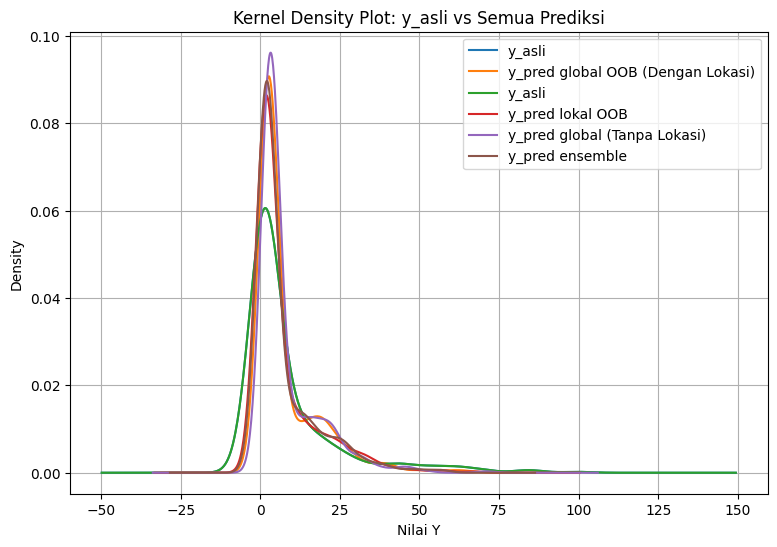

In [ ]:
LMResults = pd.read_excel("/content/LMResults_GWXGB_Tweedie_Gaussian_Maret.xlsx")
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

# ambil tabel prediksi
GlobalResults = global_oob_tweedie['Prediction']

plt.figure(figsize=(9, 6))

GlobalResults['y_asli'].plot(
    kind='kde',
    label='y_asli'
)

GlobalResults['yGhat'].plot(
    kind='kde',
    label='y_pred global OOB (Dengan Lokasi)'
)

LMResults['y_asli'].plot(kind='kde', label='y_asli')
LMResults['LM_yOOB'].plot(kind='kde', label='y_pred lokal OOB')
LMResults['yGhat'].plot(kind='kde', label='y_pred global (Tanpa Lokasi)')
LMResults['y_ensemble'].plot(kind='kde', label='y_pred ensemble')


plt.xlabel('Nilai Y')
plt.ylabel('Density')
plt.title('Kernel Density Plot: y_asli vs Semua Prediksi')
plt.legend()
plt.grid(True)
plt.show()

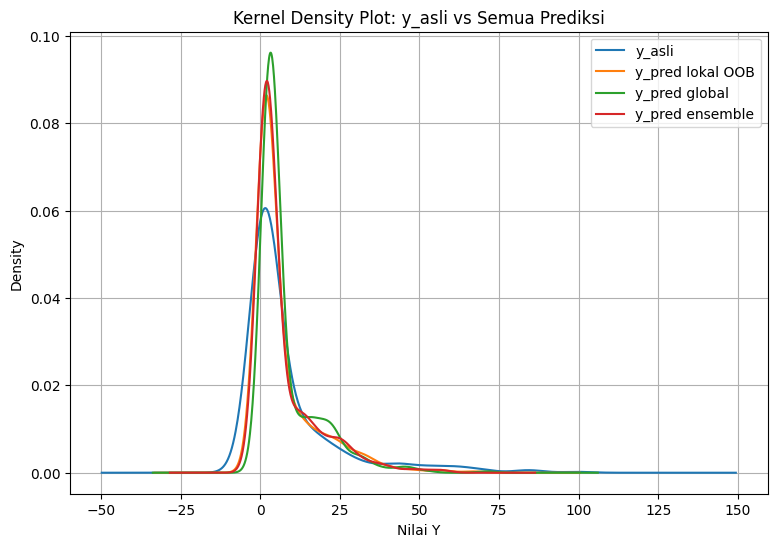

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

LMResults4['y_asli'].plot(kind='kde', label='y_asli')
LMResults4['LM_yOOB'].plot(kind='kde', label='y_pred lokal OOB')
LMResults4['yGhat'].plot(kind='kde', label='y_pred global')
LMResults4['y_ensemble'].plot(kind='kde', label='y_pred ensemble')

plt.xlabel('Nilai Y')
plt.ylabel('Density')
plt.title('Kernel Density Plot: y_asli vs Semua Prediksi')
plt.legend()
plt.grid(True)
plt.show()

##### Pengecekan Autokorelasi Spasial

In [ ]:
LMResults4['Res_ensemble'] = (
    LMResults4['y_asli'] - LMResults4['y_ensemble']
)

In [ ]:
## XGBoost Global
from libpysal.weights import KNN
from esda.moran import Moran
np.random.seed(7)

# residual ensemble
residual_tweedie_G2 = LMResults4['y_asli'] - LMResults4['yGhat']

# koordinat
coords = list(zip(Coords.iloc[:, 0], Coords.iloc[:, 1]))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

# Moran's I
mi = Moran(residual_tweedie_G2, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : 0.10004541605850106
p-value   : 0.001
z-score   : 3.7737614465305636


In [ ]:
## XGBoost Lokal
from libpysal.weights import KNN
from esda.moran import Moran
np.random.seed(7)

# residual lokal OOB
residual_tweedie_G = LMResults4['LM_ResOOB']

# koordinat
coords = list(zip(Coords.iloc[:, 0], Coords.iloc[:, 1]))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

# Moran's I
mi = Moran(residual_tweedie_G, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : -0.04279475415368373
p-value   : 0.059
z-score   : -1.5160532943961849


In [ ]:
## XGBoost Esemble
from libpysal.weights import KNN
from esda.moran import Moran
np.random.seed(7)

# residual ensemble
residual_tweedie_G2 = LMResults4['y_asli'] - LMResults4['y_ensemble']

# koordinat
coords = list(zip(Coords.iloc[:, 0], Coords.iloc[:, 1]))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

# Moran's I
mi = Moran(residual_tweedie_G2, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : 0.02391872219691026
p-value   : 0.184
z-score   : 0.9579617709492514


##### Prediksi Titik Baru

In [ ]:
# ======================================================
# 5. Prediksi titik baru
# ======================================================
hasil_prediksi_Tweedie_G = predict_new_gwxgboost_tweedie(
    X_train=X,
    y_train=y,
    Coords_train=Coords,
    X_new=X_baru,
    Coords_new=Coords_baru,
    BW_opt=64,
    params=xgb_params2,
    Kernel='Adaptive',
    KernelFunction='Gaussian',
    spatial_weights=True,
    alpha_wt=output_model4['alpha_wt'],
    alpha_wt_type='varying',
    random_state=42,
    path_save='hasil_prediksi_baru'
)

================= Predict New Data GWXGBoost Tweedie =================
Predicting new location 1 of 165
Predicting new location 2 of 165
Predicting new location 3 of 165
Predicting new location 4 of 165
Predicting new location 5 of 165
Predicting new location 6 of 165
Predicting new location 7 of 165
Predicting new location 8 of 165
Predicting new location 9 of 165
Predicting new location 10 of 165
Predicting new location 11 of 165
Predicting new location 12 of 165
Predicting new location 13 of 165
Predicting new location 14 of 165
Predicting new location 15 of 165
Predicting new location 16 of 165
Predicting new location 17 of 165
Predicting new location 18 of 165
Predicting new location 19 of 165
Predicting new location 20 of 165
Predicting new location 21 of 165
Predicting new location 22 of 165
Predicting new location 23 of 165
Predicting new location 24 of 165
Predicting new location 25 of 165
Predicting new location 26 of 165
Predicting new location 27 of 165
Predicting new locat

In [ ]:
# ======================================================
# 6. Lihat hasil prediksi
# ======================================================
hasil_prediksi_Tweedie_G['Prediction_New']

,IDS_new,Nearest_Train_ID,Distance_to_Nearest,Local_Pred,Global_Pred,alpha_wt_type,alpha_source,alpha_wt,beta_wt,Ensemble_Pred,Top_Features
0,0,203,0.500000,0.383697,3.730189,varying,nearest_train_id_203,1.0,0.0,0.383697,"zos, mlotst, vo, chl, nppv"
1,1,204,0.500000,0.447483,3.341461,varying,nearest_train_id_204,1.0,0.0,0.447483,"vo, zos, nppv, chl, mlotst"
2,2,205,0.500000,0.275704,3.175966,varying,nearest_train_id_205,1.0,0.0,0.275704,"nppv, zos, vo, mlotst, chl"
3,3,207,0.707107,0.247491,3.319140,varying,nearest_train_id_207,1.0,0.0,0.247491,"zos, nppv, vo, chl, mlotst"
4,4,207,0.500000,0.317978,3.319140,varying,nearest_train_id_207,1.0,0.0,0.317978,"zos, mlotst, nppv, vo, chl"
...,...,...,...,...,...,...,...,...,...,...,...
160,160,188,0.500000,0.441038,6.790561,varying,nearest_train_id_188,1.0,0.0,0.441038,"nppv, o2, so, vo, zos"
161,161,181,0.500000,0.524902,1.810314,varying,nearest_train_id_181,1.0,0.0,0.524902,"nppv, vo, mlotst, o2, so"
162,162,177,0.500000,0.516598,3.102060,varying,nearest_train_id_177,1.0,0.0,0.516598,"nppv, vo, so, mlotst, thetao"
163,163,198,0.500000,0.445989,4.029080,varying,nearest_train_id_198,1.0,0.0,0.445989,"nppv, vo, chl, so, mlotst"


In [ ]:
# ======================================================
# 6. Lihat hasil prediksi
# ======================================================
Feature_Importance_New = hasil_prediksi_Tweedie_G['Feature_Importance_New']
# Simpan ke Excel
Feature_Importance_New.to_excel(
    'Feature_Importance_New_Tweedie_Maret_Gaussian.xlsx',
    index=False
)

In [ ]:
# Gabungkan hasil prediksi ke data_baru
prediksi['Pred_Local_Gaussian'] = hasil_prediksi_Tweedie_G['Prediction_New']['Local_Pred']
prediksi['Pred_Global_Gaussian'] = hasil_prediksi_Tweedie_G['Prediction_New']['Global_Pred']
prediksi['Pred_Ensemble_Gaussian'] = hasil_prediksi_Tweedie_G['Prediction_New']['Ensemble_Pred']

# Simpan ke Excel
prediksi.to_excel(
    'hasil_prediksi_data_Tweedie_Gaussian_Maret.xlsx',
    index=False
)

## Visualisasi Akhir Analisis


### Hasil Prediksi

In [ ]:
# 1) Baca Excel (sheet pertama)
visual2 = pd.read_excel("/content/Visualisasi Hasil Tweedie.xlsx")
visual2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 610 entries, 0 to 609
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Longitude                  610 non-null    float64
 1   Latitude                   610 non-null    float64
 2   Prediksi_Lokal_Gaussian    610 non-null    float64
 3   Prediksi_Global_Gaussian   610 non-null    float64
 4   Prediksi_Esemble_Gaussian  610 non-null    float64
 5   Max_Fitur_Gaussian         610 non-null    object 
dtypes: float64(5), object(1)
memory usage: 28.7+ KB


In [ ]:
visual_mar = pd.merge(
    WPP,
    visual2[['Longitude', 'Latitude', 'Prediksi_Lokal_Gaussian']],
    on=['Longitude', 'Latitude'],
    how='left'
)

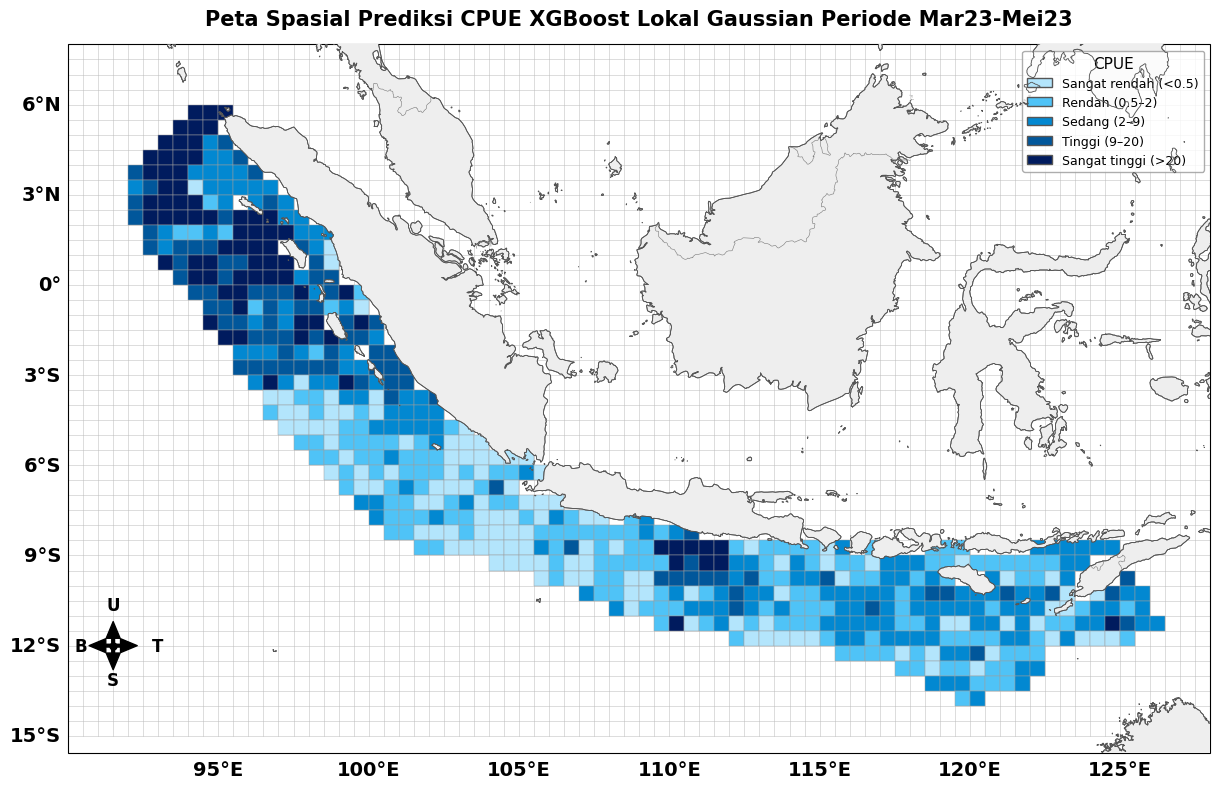

In [ ]:
import matplotlib.colors as mcolors
value_col = 'Prediksi_Lokal_Gaussian'
grid_size = 0.5

lon_min, lon_max = 90, 128
lat_min, lat_max = -15, 8

plot_data = visual_mar.copy()
plot_data[value_col] = pd.to_numeric(plot_data[value_col], errors='coerce')
plot_data['cpue_plot'] = plot_data[value_col].where(plot_data[value_col] > 0)

# Kategori CPUE
bins = [0, 0.5, 2, 9, 20, 100]

labels = [
    'Sangat rendah (<0.5)',
    'Rendah (0.5–2)',
    'Sedang (2–9)',
    'Tinggi (9–20)',
    'Sangat tinggi (>20)'
]

# Warna biru kontras
colors_cpue = [
    '#B3E5FC',
    '#4FC3F7',
    '#0288D1',
    '#01579B',
    '#001B5E'
]

cmap = mcolors.ListedColormap(colors_cpue)
norm = mcolors.BoundaryNorm(bins, cmap.N)

fig = plt.figure(figsize=(13, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([lon_min, lon_max, lat_min, lat_max])
ax.set_facecolor('#ffffff')

# Grid diperjelas
for lon in np.arange(lon_min, lon_max + grid_size, grid_size):
    ax.plot([lon, lon], [lat_min, lat_max],
            color='#bdbdbd', linewidth=0.45, alpha=0.8,
            transform=ccrs.PlateCarree(), zorder=1)

for lat in np.arange(lat_min, lat_max + grid_size, grid_size):
    ax.plot([lon_min, lon_max], [lat, lat],
            color='#bdbdbd', linewidth=0.45, alpha=0.8,
            transform=ccrs.PlateCarree(), zorder=1)

# Plot grid CPUE
for _, row in plot_data.iterrows():
    lon = row['Longitude']
    lat = row['Latitude']
    val = row['cpue_plot']

    if pd.isna(val):
        continue

    if not (lon_min <= lon <= lon_max and lat_min <= lat <= lat_max):
        continue

    val = min(val, 100)

    rect = patches.Rectangle(
        (lon - grid_size/2, lat - grid_size/2),
        grid_size,
        grid_size,
        facecolor=cmap(norm(val)),
        edgecolor='#9e9e9e',
        linewidth=0.35,
        transform=ccrs.PlateCarree(),
        zorder=2
    )
    ax.add_patch(rect)

# Daratan abu-abu samar
land = cfeature.NaturalEarthFeature(
    category='physical',
    name='land',
    scale='10m',
    facecolor='#eeeeee',
    edgecolor='#555555'
)

ax.add_feature(land, linewidth=0.6, zorder=5)
ax.add_feature(cfeature.COASTLINE.with_scale('10m'),
               linewidth=0.6, edgecolor='#555555', zorder=6)
ax.add_feature(cfeature.BORDERS.with_scale('10m'),
               linewidth=0.4, edgecolor='#777777', zorder=6)

# Label koordinat
gl = ax.gridlines(draw_labels=True, linewidth=0, color='none')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 14, 'weight': 'bold'}
gl.ylabel_style = {'size': 14, 'weight': 'bold'}

# Legend
legend_patches = [
    patches.Patch(facecolor=colors_cpue[i],
                  edgecolor='#555555',
                  label=labels[i])
    for i in range(len(labels))
]

ax.legend(handles=legend_patches,
          title='CPUE',
          loc='upper right',
          frameon=True,
          edgecolor='#999999',
          fontsize=9,
          title_fontsize=11)

# Mata angin lengkap
x_c, y_c = 91.5, -12
panjang = 0.8

# titik pusat
ax.scatter(x_c, y_c, color='black', s=25, transform=ccrs.PlateCarree(), zorder=10)

# U
ax.annotate('', xy=(x_c, y_c+panjang), xytext=(x_c, y_c),
            arrowprops=dict(facecolor='black', width=2, headwidth=10),
            xycoords=ccrs.PlateCarree()._as_mpl_transform(ax))
ax.text(x_c, y_c+panjang+0.4, 'U', ha='center', fontsize=12, fontweight='bold',
        transform=ccrs.PlateCarree())

# S
ax.annotate('', xy=(x_c, y_c-panjang), xytext=(x_c, y_c),
            arrowprops=dict(facecolor='black', width=2, headwidth=10),
            xycoords=ccrs.PlateCarree()._as_mpl_transform(ax))
ax.text(x_c, y_c-panjang-0.5, 'S', ha='center', fontsize=12, fontweight='bold',
        transform=ccrs.PlateCarree())

# T
ax.annotate('', xy=(x_c+panjang, y_c), xytext=(x_c, y_c),
            arrowprops=dict(facecolor='black', width=2, headwidth=10),
            xycoords=ccrs.PlateCarree()._as_mpl_transform(ax))
ax.text(x_c+panjang+0.5, y_c, 'T', va='center', fontsize=12, fontweight='bold',
        transform=ccrs.PlateCarree())

# B
ax.annotate('', xy=(x_c-panjang, y_c), xytext=(x_c, y_c),
            arrowprops=dict(facecolor='black', width=2, headwidth=10),
            xycoords=ccrs.PlateCarree()._as_mpl_transform(ax))
ax.text(x_c-panjang-0.5, y_c, 'B', va='center', fontsize=12, fontweight='bold',
        transform=ccrs.PlateCarree())

ax.set_title('Peta Spasial Prediksi CPUE XGBoost Lokal Gaussian Periode Musim peralihan I',
             fontsize=15, fontweight='bold', pad=14)

plt.tight_layout()
plt.show()

In [ ]:
visual_mar2 = pd.merge(
    WPP,
    visual2[['Longitude', 'Latitude', 'Prediksi_Esemble_Gaussian']],
    on=['Longitude', 'Latitude'],
    how='left'
)

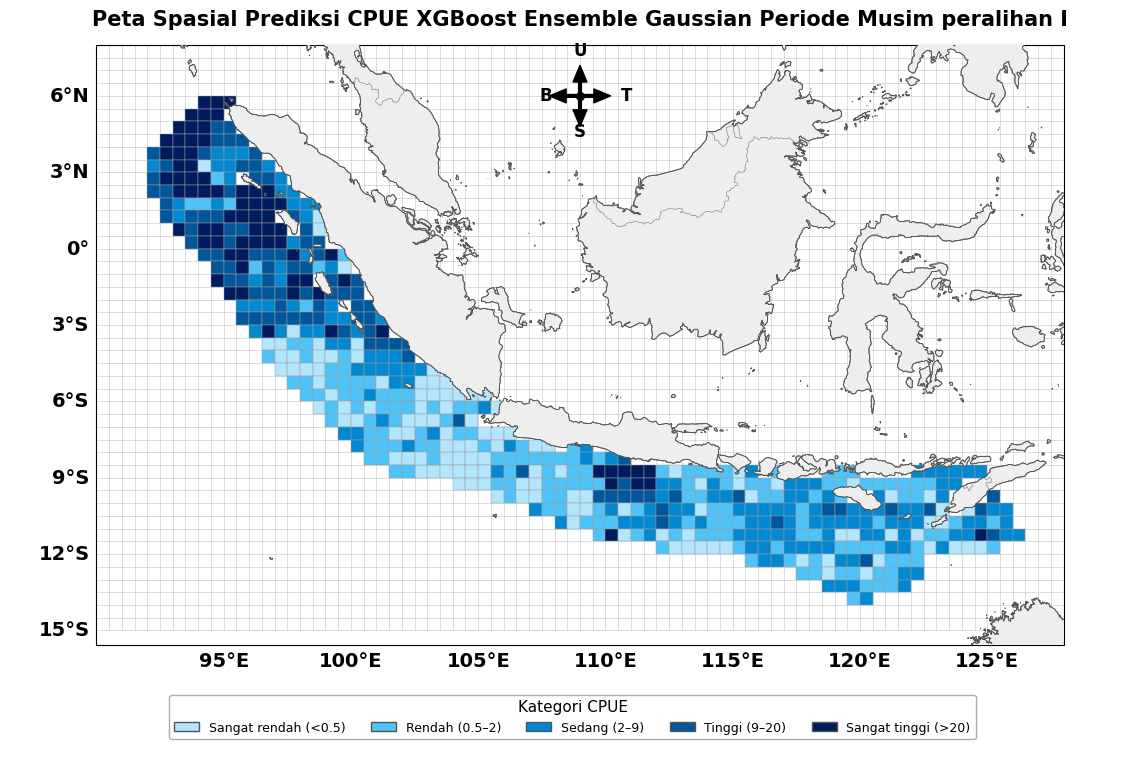

In [ ]:
import matplotlib.colors as mcolors

# =========================
# 1. PARAMETER
# =========================
value_col = 'Prediksi_Esemble_Gaussian'
grid_size = 0.5

lon_min, lon_max = 90, 128
lat_min, lat_max = -15, 8

plot_data = visual_mar2.copy()

plot_data[value_col] = pd.to_numeric(
    plot_data[value_col],
    errors='coerce'
)

plot_data['cpue_plot'] = (
    plot_data[value_col]
    .where(plot_data[value_col] > 0)
)

# =========================
# 2. KATEGORI CPUE
# =========================
bins = [0, 0.5, 2, 9, 20, 100]

labels = [
    'Sangat rendah (<0.5)',
    'Rendah (0.5–2)',
    'Sedang (2–9)',
    'Tinggi (9–20)',
    'Sangat tinggi (>20)'
]

# Warna biru kontras
colors_cpue = [
    '#B3E5FC',
    '#4FC3F7',
    '#0288D1',
    '#01579B',
    '#001B5E'
]

cmap = mcolors.ListedColormap(colors_cpue)
norm = mcolors.BoundaryNorm(bins, cmap.N)

# =========================
# 3. FIGURE
# =========================
fig = plt.figure(figsize=(15, 8))

# Peta utama
ax = fig.add_axes(
    [0.05, 0.15, 0.90, 0.75],
    projection=ccrs.PlateCarree()
)

# Legend horizontal bawah
legend_ax = fig.add_axes([0.12, 0.02, 0.75, 0.08])
legend_ax.axis('off')

ax.set_extent([
    lon_min,
    lon_max,
    lat_min,
    lat_max
])

ax.set_facecolor('#ffffff')

# =========================
# 4. GRID 0.5 DERAJAT
# =========================
for lon in np.arange(
    lon_min,
    lon_max + grid_size,
    grid_size
):
    ax.plot(
        [lon, lon],
        [lat_min, lat_max],
        color='#bdbdbd',
        linewidth=0.45,
        alpha=0.8,
        transform=ccrs.PlateCarree(),
        zorder=1
    )

for lat in np.arange(
    lat_min,
    lat_max + grid_size,
    grid_size
):
    ax.plot(
        [lon_min, lon_max],
        [lat, lat],
        color='#bdbdbd',
        linewidth=0.45,
        alpha=0.8,
        transform=ccrs.PlateCarree(),
        zorder=1
    )

# =========================
# 5. PLOT GRID CPUE
# =========================
for _, row in plot_data.iterrows():

    lon = row['Longitude']
    lat = row['Latitude']
    val = row['cpue_plot']

    if pd.isna(val):
        continue

    if not (
        lon_min <= lon <= lon_max
        and
        lat_min <= lat <= lat_max
    ):
        continue

    val = min(val, 100)

    rect = patches.Rectangle(
        (
            lon - grid_size / 2,
            lat - grid_size / 2
        ),
        grid_size,
        grid_size,
        facecolor=cmap(norm(val)),
        edgecolor='#9e9e9e',
        linewidth=0.35,
        transform=ccrs.PlateCarree(),
        zorder=2
    )

    ax.add_patch(rect)

# =========================
# 6. DARATAN
# =========================
land = cfeature.NaturalEarthFeature(
    category='physical',
    name='land',
    scale='10m',
    facecolor='#eeeeee',
    edgecolor='#555555'
)

ax.add_feature(
    land,
    linewidth=0.6,
    zorder=5
)

ax.add_feature(
    cfeature.COASTLINE.with_scale('10m'),
    linewidth=0.6,
    edgecolor='#555555',
    zorder=6
)

ax.add_feature(
    cfeature.BORDERS.with_scale('10m'),
    linewidth=0.4,
    edgecolor='#777777',
    zorder=6
)

# =========================
# 7. LABEL KOORDINAT
# =========================
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0,
    color='none'
)

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {
    'size': 14,
    'weight': 'bold'
}

gl.ylabel_style = {
    'size': 14,
    'weight': 'bold'
}

# =========================
# 8. LEGENDE HORIZONTAL
# =========================
legend_patches = [
    patches.Patch(
        facecolor=colors_cpue[i],
        edgecolor='#555555',
        label=labels[i]
    )
    for i in range(len(labels))
]

legend_ax.legend(
    handles=legend_patches,
    title='Kategori CPUE',
    loc='center',
    ncol=5,
    frameon=True,
    edgecolor='#999999',
    fontsize=9,
    title_fontsize=11
)

# =========================
# 9. MATA ANGIN TENGAH ATAS
# =========================
x_c = (lon_min + lon_max) / 2
y_c = lat_max - 2

panjang = 1.2

# Titik tengah
ax.scatter(
    x_c,
    y_c,
    color='black',
    s=30,
    transform=ccrs.PlateCarree(),
    zorder=10
)

# Utara
ax.annotate(
    '',
    xy=(x_c, y_c + panjang),
    xytext=(x_c, y_c),
    arrowprops=dict(
        facecolor='black',
        width=2,
        headwidth=10
    ),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax)
)

ax.text(
    x_c,
    y_c + panjang + 0.4,
    'U',
    ha='center',
    fontsize=12,
    fontweight='bold',
    transform=ccrs.PlateCarree()
)

# Selatan
ax.annotate(
    '',
    xy=(x_c, y_c - panjang),
    xytext=(x_c, y_c),
    arrowprops=dict(
        facecolor='black',
        width=2,
        headwidth=10
    ),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax)
)

ax.text(
    x_c,
    y_c - panjang - 0.4,
    'S',
    ha='center',
    fontsize=12,
    fontweight='bold',
    transform=ccrs.PlateCarree()
)

# Timur
ax.annotate(
    '',
    xy=(x_c + panjang, y_c),
    xytext=(x_c, y_c),
    arrowprops=dict(
        facecolor='black',
        width=2,
        headwidth=10
    ),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax)
)

ax.text(
    x_c + panjang + 0.4,
    y_c,
    'T',
    va='center',
    fontsize=12,
    fontweight='bold',
    transform=ccrs.PlateCarree()
)

# Barat
ax.annotate(
    '',
    xy=(x_c - panjang, y_c),
    xytext=(x_c, y_c),
    arrowprops=dict(
        facecolor='black',
        width=2,
        headwidth=10
    ),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax)
)

ax.text(
    x_c - panjang - 0.4,
    y_c,
    'B',
    va='center',
    fontsize=12,
    fontweight='bold',
    transform=ccrs.PlateCarree()
)

# =========================
# 10. JUDUL
# =========================
ax.set_title(
    'Peta Spasial Prediksi CPUE XGBoost Ensemble Gaussian Periode Musim peralihan I',
    fontsize=15,
    fontweight='bold',
    pad=14
)

plt.show()

### Fitur Penting

#### Fitur Penting Global

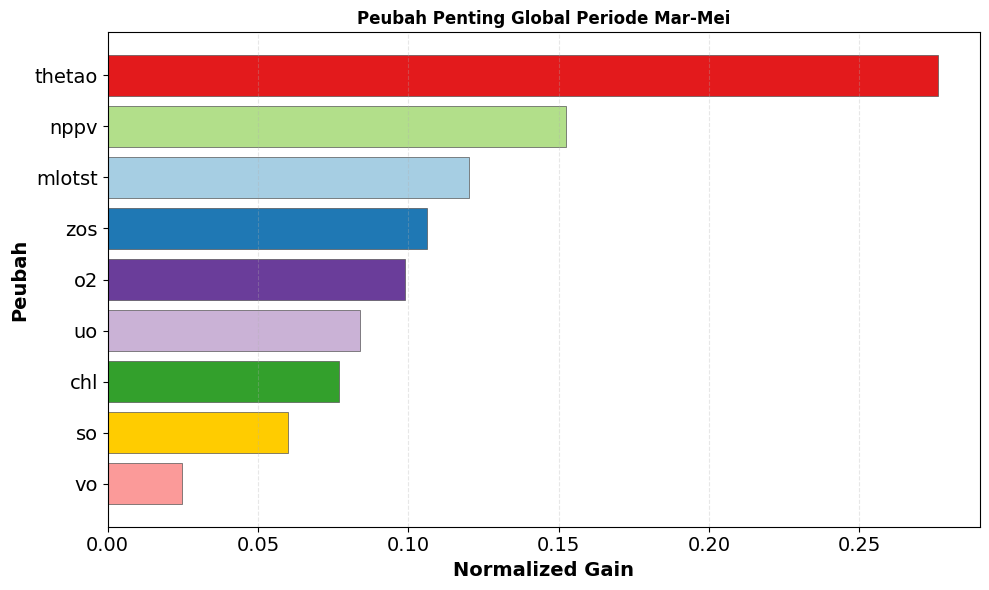

In [ ]:
import matplotlib.pyplot as plt

global_imp = output_model4['GlobalImportance'].copy()

global_imp = global_imp.sort_values(
    by='Gain_Normalized',
    ascending=False
).reset_index(drop=True)

# Mapping warna fitur
colors_feature = {
    'zos': '#1f78b4',
    'thetao': '#e31a1c',
    'chl': '#33a02c',
    'o2': '#6a3d9a',
    'nppv': '#b2df8a',
    'mlotst': '#a6cee3',
    'vo': '#fb9a99',
    'uo': '#cab2d6',
    'so': '#ffcc00'
}

# Warna bar sesuai nama Feature
bar_colors = [
    colors_feature.get(feature, '#bdbdbd')
    for feature in global_imp['Feature']
]

plt.figure(figsize=(10, 6))

plt.barh(
    global_imp['Feature'],
    global_imp['Gain_Normalized'],
    color=bar_colors,
    edgecolor='#555555',
    linewidth=0.5
)

plt.gca().invert_yaxis()

plt.xlabel('Normalized Gain', fontsize=14, fontweight='bold')
plt.ylabel('Peubah', fontsize=14, fontweight='bold')
plt.title('Peubah Penting Global Periode Mar-Mei', fontweight='bold')
plt.tick_params(
    axis='both',
    labelsize=14   # ini yang mengatur angka sumbu
)
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

#### Fitur Penting Lokal

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# daftar unik fitur
fitur_unik = visual2['Max_Fitur_Gaussian'].unique()

# colormap
cmap = plt.cm.get_cmap('tab10', len(fitur_unik))

# mapping warna
color_map = {fitur: cmap(i) for i, fitur in enumerate(fitur_unik)}

# buat kolom warna
visual2['color'] = visual2['Max_Fitur_Gaussian'].map(color_map)

/tmp/ipykernel_1053/1240998469.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(fitur_unik))


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


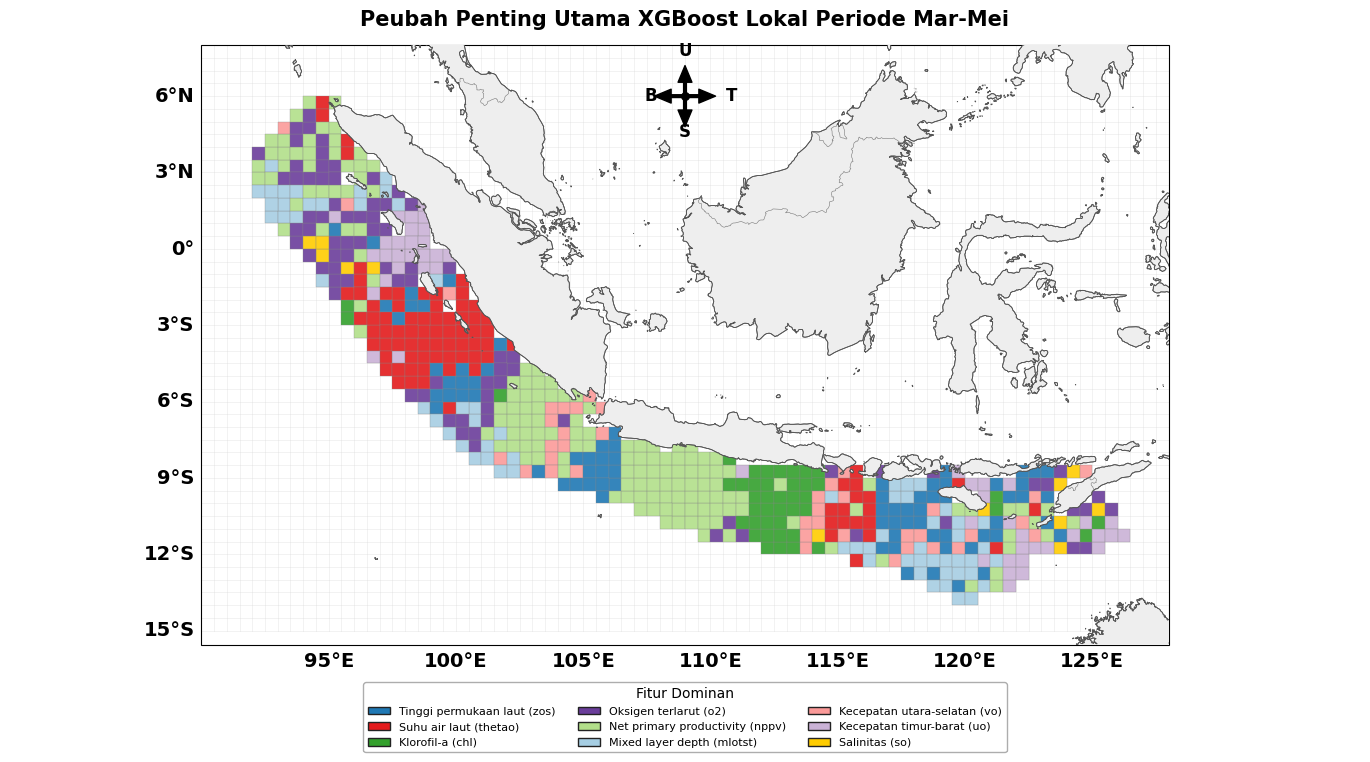

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# =========================
# 1. PARAMETER PETA
# =========================
feature_col = 'Max_Fitur_Gaussian'
grid_size = 0.5

lon_min, lon_max = 90, 128
lat_min, lat_max = -15, 8

plot_data = visual2.copy()

plot_data['Longitude'] = pd.to_numeric(
    plot_data['Longitude'],
    errors='coerce'
)

plot_data['Latitude'] = pd.to_numeric(
    plot_data['Latitude'],
    errors='coerce'
)

plot_data = plot_data.dropna(
    subset=['Longitude', 'Latitude', feature_col]
)

# =========================
# 2. WARNA FITUR DOMINAN
# =========================
colors_feature = {
    'zos': '#1f78b4',
    'thetao': '#e31a1c',
    'chl': '#33a02c',
    'o2': '#6a3d9a',
    'nppv': '#b2df8a',
    'mlotst': '#a6cee3',
    'vo': '#fb9a99',
    'uo': '#cab2d6',
    'so': '#ffcc00'
}

# =========================
# 3. LABEL FITUR
# =========================
feature_labels = {
    'zos': 'Tinggi permukaan laut (zos)',
    'thetao': 'Suhu air laut (thetao)',
    'chl': 'Klorofil-a (chl)',
    'o2': 'Oksigen terlarut (o2)',
    'nppv': 'Net primary productivity (nppv)',
    'mlotst': 'Mixed layer depth (mlotst)',
    'vo': 'Kecepatan utara-selatan (vo)',
    'uo': 'Kecepatan timur-barat (uo)',
    'so': 'Salinitas (so)'
}

feature_order = [
    'zos',
    'thetao',
    'chl',
    'o2',
    'nppv',
    'mlotst',
    'vo',
    'uo',
    'so'
]

plot_data['color'] = (
    plot_data[feature_col]
    .map(colors_feature)
    .fillna('#bdbdbd')
)

# =========================
# 4. FIGURE
# =========================
fig = plt.figure(figsize=(15, 8))

# Peta utama
ax = fig.add_axes(
    [0.05, 0.15, 0.90, 0.75],
    projection=ccrs.PlateCarree()
)

# Legend horizontal bawah
legend_ax = fig.add_axes([0.05, 0.02, 0.90, 0.08])
legend_ax.axis('off')

ax.set_extent([
    lon_min,
    lon_max,
    lat_min,
    lat_max
])

ax.set_facecolor('#ffffff')

# =========================
# 5. GRID 0.5 DERAJAT
# =========================
for lon in np.arange(
    lon_min,
    lon_max + grid_size,
    grid_size
):
    ax.plot(
        [lon, lon],
        [lat_min, lat_max],
        color='#d6d6d6',
        linewidth=0.45,
        alpha=0.5,
        transform=ccrs.PlateCarree(),
        zorder=1
    )

for lat in np.arange(
    lat_min,
    lat_max + grid_size,
    grid_size
):
    ax.plot(
        [lon_min, lon_max],
        [lat, lat],
        color='#d6d6d6',
        linewidth=0.45,
        alpha=0.5,
        transform=ccrs.PlateCarree(),
        zorder=1
    )

# =========================
# 6. PLOT GRID FITUR DOMINAN
# =========================
for _, row in plot_data.iterrows():

    lon = row['Longitude']
    lat = row['Latitude']
    warna = row['color']

    if not (
        lon_min <= lon <= lon_max
        and
        lat_min <= lat <= lat_max
    ):
        continue

    rect = patches.Rectangle(
        (
            lon - grid_size / 2,
            lat - grid_size / 2
        ),
        grid_size,
        grid_size,
        facecolor=warna,
        edgecolor='#8a8a8a',
        linewidth=0.25,
        alpha=0.9,
        transform=ccrs.PlateCarree(),
        zorder=2
    )

    ax.add_patch(rect)

# =========================
# 7. DARATAN DAN BATAS
# =========================
land = cfeature.NaturalEarthFeature(
    category='physical',
    name='land',
    scale='10m',
    facecolor='#eeeeee',
    edgecolor='#555555'
)

ax.add_feature(
    land,
    linewidth=0.6,
    zorder=5
)

ax.add_feature(
    cfeature.COASTLINE.with_scale('10m'),
    linewidth=0.6,
    edgecolor='#555555',
    zorder=6
)

ax.add_feature(
    cfeature.BORDERS.with_scale('10m'),
    linewidth=0.4,
    edgecolor='#777777',
    zorder=6
)

# =========================
# 8. LABEL KOORDINAT
# =========================
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0,
    color='none'
)

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {
    'size': 14,
    'weight': 'bold'
}

gl.ylabel_style = {
    'size': 14,
    'weight': 'bold'
}

# =========================
# 9. LEGENDE HORIZONTAL
# =========================
fitur_ada = plot_data[feature_col].unique()

legend_patches = [
    patches.Patch(
        facecolor=colors_feature.get(fitur, '#bdbdbd'),
        edgecolor='#222222',
        label=feature_labels.get(fitur, fitur)
    )
    for fitur in feature_order
    if fitur in fitur_ada
]

legend_ax.legend(
    handles=legend_patches,
    title='Fitur Dominan',
    loc='center',
    ncol=3,
    frameon=True,
    edgecolor='#999999',
    fontsize=8,
    title_fontsize=10
)

# =========================
# 10. MATA ANGIN TENGAH ATAS
# =========================
x_c = (lon_min + lon_max) / 2
y_c = lat_max - 2

panjang = 1.2

# Titik tengah
ax.scatter(
    x_c,
    y_c,
    color='black',
    s=30,
    transform=ccrs.PlateCarree(),
    zorder=10
)

# Utara
ax.annotate(
    '',
    xy=(x_c, y_c + panjang),
    xytext=(x_c, y_c),
    arrowprops=dict(
        facecolor='black',
        width=2,
        headwidth=10
    ),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax)
)

ax.text(
    x_c,
    y_c + panjang + 0.4,
    'U',
    ha='center',
    fontsize=12,
    fontweight='bold',
    transform=ccrs.PlateCarree()
)

# Selatan
ax.annotate(
    '',
    xy=(x_c, y_c - panjang),
    xytext=(x_c, y_c),
    arrowprops=dict(
        facecolor='black',
        width=2,
        headwidth=10
    ),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax)
)

ax.text(
    x_c,
    y_c - panjang - 0.4,
    'S',
    ha='center',
    fontsize=12,
    fontweight='bold',
    transform=ccrs.PlateCarree()
)

# Timur
ax.annotate(
    '',
    xy=(x_c + panjang, y_c),
    xytext=(x_c, y_c),
    arrowprops=dict(
        facecolor='black',
        width=2,
        headwidth=10
    ),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax)
)

ax.text(
    x_c + panjang + 0.4,
    y_c,
    'T',
    va='center',
    fontsize=12,
    fontweight='bold',
    transform=ccrs.PlateCarree()
)

# Barat
ax.annotate(
    '',
    xy=(x_c - panjang, y_c),
    xytext=(x_c, y_c),
    arrowprops=dict(
        facecolor='black',
        width=2,
        headwidth=10
    ),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax)
)

ax.text(
    x_c - panjang - 0.4,
    y_c,
    'B',
    va='center',
    fontsize=12,
    fontweight='bold',
    transform=ccrs.PlateCarree()
)

# =========================
# 11. JUDUL
# =========================
ax.set_title(
    'Peubah Penting Utama XGBoost Lokal Periode Mar-Mei',
    fontsize=15,
    fontweight='bold',
    pad=14
)

plt.show()

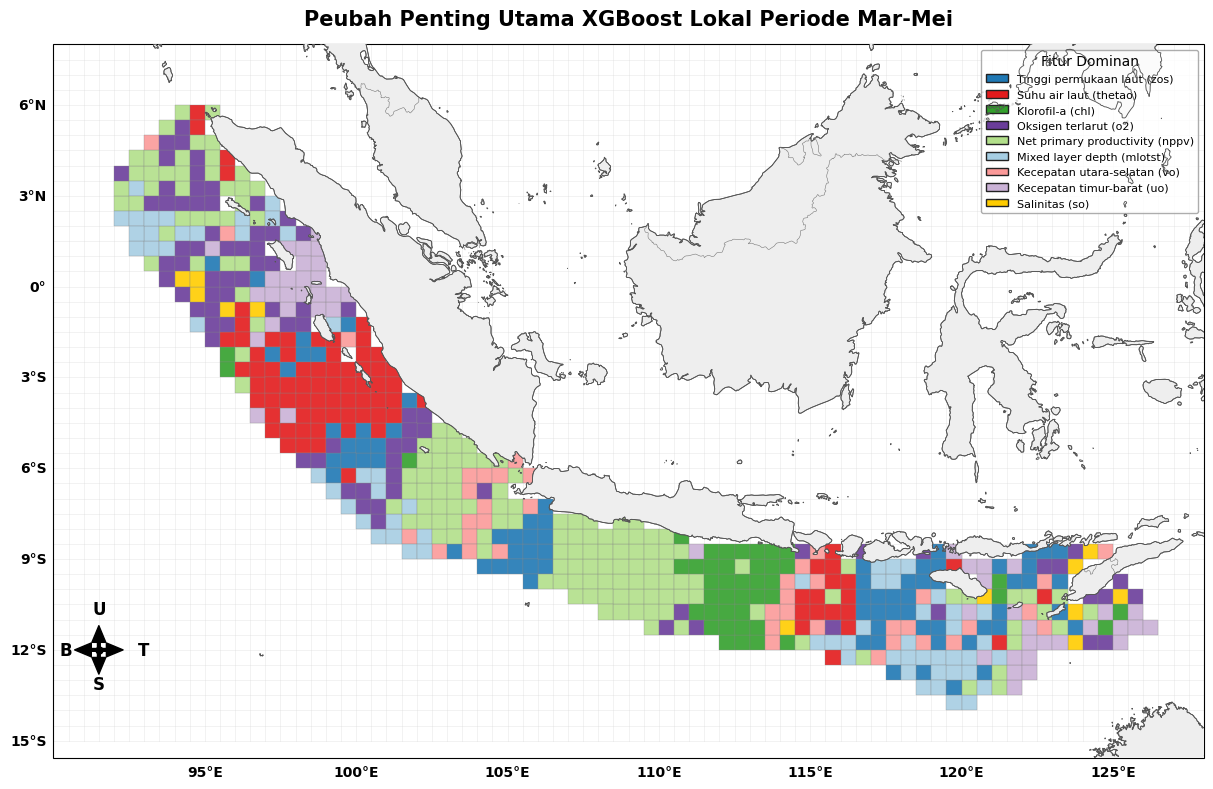

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# =========================
# Parameter peta
# =========================
feature_col = 'Max_Fitur_Gaussian'
grid_size = 0.5

lon_min, lon_max = 90, 128
lat_min, lat_max = -15, 8

plot_data = visual2.copy()

plot_data['Longitude'] = pd.to_numeric(plot_data['Longitude'], errors='coerce')
plot_data['Latitude'] = pd.to_numeric(plot_data['Latitude'], errors='coerce')

plot_data = plot_data.dropna(subset=['Longitude', 'Latitude', feature_col])

# =========================
# Warna fitur dominan
# Tema biru - hijau tosca
# =========================
colors_feature = {
    'zos': '#1f78b4',
    'thetao': '#e31a1c',
    'chl': '#33a02c',
    'o2': '#6a3d9a',
    'nppv': '#b2df8a',
    'mlotst': '#a6cee3',
    'vo': '#fb9a99',
    'uo': '#cab2d6',
    'so': '#ffcc00'
}

# =========================
# Keterangan fitur
# =========================
feature_labels = {
    'zos': 'Tinggi permukaan laut (zos)',
    'thetao': 'Suhu air laut (thetao)',
    'chl': 'Klorofil-a (chl)',
    'o2': 'Oksigen terlarut (o2)',
    'nppv': 'Net primary productivity (nppv)',
    'mlotst': 'Mixed layer depth (mlotst)',
    'vo': 'Kecepatan utara-selatan (vo)',
    'uo': 'Kecepatan timur-barat (uo)',
    'so': 'Salinitas (so)'
}

feature_order = ['zos', 'thetao', 'chl', 'o2', 'nppv', 'mlotst', 'vo', 'uo', 'so']

plot_data['color'] = plot_data[feature_col].map(colors_feature).fillna('#bdbdbd')

# =========================
# Membuat peta
# =========================
fig = plt.figure(figsize=(13, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([lon_min, lon_max, lat_min, lat_max])
ax.set_facecolor('#ffffff')

# =========================
# Grid 0.5 derajat
# =========================
for lon in np.arange(lon_min, lon_max + grid_size, grid_size):
    ax.plot(
        [lon, lon], [lat_min, lat_max],
        color='#d6d6d6',
        linewidth=0.45,
        alpha=0.5,
        transform=ccrs.PlateCarree(),
        zorder=1
    )

for lat in np.arange(lat_min, lat_max + grid_size, grid_size):
    ax.plot(
        [lon_min, lon_max], [lat, lat],
        color='#d6d6d6',
        linewidth=0.45,
        alpha=0.5,
        transform=ccrs.PlateCarree(),
        zorder=1
    )

# =========================
# Plot grid fitur dominan
# =========================
for _, row in plot_data.iterrows():
    lon = row['Longitude']
    lat = row['Latitude']
    warna = row['color']

    if not (lon_min <= lon <= lon_max and lat_min <= lat <= lat_max):
        continue

    rect = patches.Rectangle(
        (lon - grid_size / 2, lat - grid_size / 2),
        grid_size,
        grid_size,
        facecolor=warna,
        edgecolor='#8a8a8a',
        linewidth=0.25,
        alpha=0.9,
        transform=ccrs.PlateCarree(),
        zorder=2
    )
    ax.add_patch(rect)

# =========================
# Daratan dan batas wilayah
# =========================
land = cfeature.NaturalEarthFeature(
    category='physical',
    name='land',
    scale='10m',
    facecolor='#eeeeee',
    edgecolor='#555555'
)

ax.add_feature(land, linewidth=0.6, zorder=5)
ax.add_feature(
    cfeature.COASTLINE.with_scale('10m'),
    linewidth=0.6,
    edgecolor='#555555',
    zorder=6
)
ax.add_feature(
    cfeature.BORDERS.with_scale('10m'),
    linewidth=0.4,
    edgecolor='#777777',
    zorder=6
)

# =========================
# Label koordinat
# =========================
gl = ax.gridlines(draw_labels=True, linewidth=0, color='none')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10, 'weight': 'bold'}
gl.ylabel_style = {'size': 10, 'weight': 'bold'}

# =========================
# Legend fitur dominan
# =========================
fitur_ada = plot_data[feature_col].unique()

legend_patches = [
    patches.Patch(
        facecolor=colors_feature.get(fitur, '#bdbdbd'),
        edgecolor='#222222',
        label=feature_labels.get(fitur, fitur)
    )
    for fitur in feature_order
    if fitur in fitur_ada
]

ax.legend(
    handles=legend_patches,
    title='Fitur Dominan',
    loc='upper right',
    frameon=True,
    edgecolor='#999999',
    fontsize=8,
    title_fontsize=10
)

# =========================
# Mata angin lengkap
# =========================
x_c, y_c = 91.5, -12
panjang = 0.8

ax.scatter(
    x_c, y_c,
    color='black',
    s=25,
    transform=ccrs.PlateCarree(),
    zorder=10
)

# Utara
ax.annotate(
    '',
    xy=(x_c, y_c + panjang),
    xytext=(x_c, y_c),
    arrowprops=dict(facecolor='black', width=2, headwidth=10),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax)
)
ax.text(
    x_c, y_c + panjang + 0.4,
    'U',
    ha='center',
    fontsize=12,
    fontweight='bold',
    transform=ccrs.PlateCarree()
)

# Selatan
ax.annotate(
    '',
    xy=(x_c, y_c - panjang),
    xytext=(x_c, y_c),
    arrowprops=dict(facecolor='black', width=2, headwidth=10),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax)
)
ax.text(
    x_c, y_c - panjang - 0.5,
    'S',
    ha='center',
    fontsize=12,
    fontweight='bold',
    transform=ccrs.PlateCarree()
)

# Timur
ax.annotate(
    '',
    xy=(x_c + panjang, y_c),
    xytext=(x_c, y_c),
    arrowprops=dict(facecolor='black', width=2, headwidth=10),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax)
)
ax.text(
    x_c + panjang + 0.5,
    y_c,
    'T',
    va='center',
    fontsize=12,
    fontweight='bold',
    transform=ccrs.PlateCarree()
)

# Barat
ax.annotate(
    '',
    xy=(x_c - panjang, y_c),
    xytext=(x_c, y_c),
    arrowprops=dict(facecolor='black', width=2, headwidth=10),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax)
)
ax.text(
    x_c - panjang - 0.5,
    y_c,
    'B',
    va='center',
    fontsize=12,
    fontweight='bold',
    transform=ccrs.PlateCarree()
)

# =========================
# Judul
# =========================
ax.set_title(
    'Peubah Penting Utama XGBoost Lokal Periode Mar-Mei',
    fontsize=15,
    fontweight='bold',
    pad=14
)

plt.tight_layout()
plt.show()

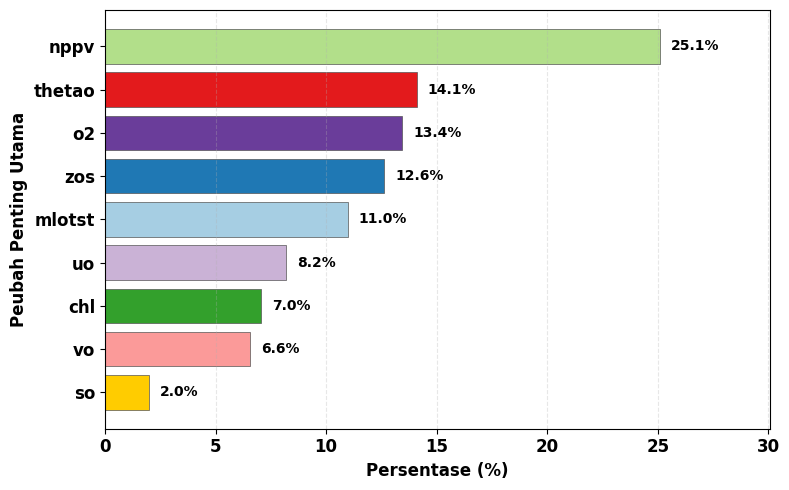

In [ ]:
import matplotlib.pyplot as plt

# 1. Hitung persentase
freq_pct = visual2['Max_Fitur_Gaussian'].value_counts(normalize=True) * 100

# 2. Urutkan (biar terbesar di atas)
freq_pct_sorted = freq_pct.sort_values(ascending=True)

# 3. Gunakan mapping warna yang sama dengan peta
colors_feature = {
    'zos': '#1f78b4',
    'thetao': '#e31a1c',
    'chl': '#33a02c',
    'o2': '#6a3d9a',
    'nppv': '#b2df8a',
    'mlotst': '#a6cee3',
    'vo': '#fb9a99',
    'uo': '#cab2d6',
    'so': '#ffcc00'
}

# Buat list warna sesuai urutan fitur yang sudah diurutkan
bar_colors = [colors_feature.get(feature, '#bdbdbd') for feature in freq_pct_sorted.index]

# 4. Plot
plt.figure(figsize=(8,5))

bars = plt.barh(
    freq_pct_sorted.index,
    freq_pct_sorted.values,
    color=bar_colors,      # Menggunakan mapping warna sinkron
    edgecolor='#555555',
    linewidth=0.5
)

plt.xlabel('Persentase (%)', fontsize = 12, fontweight='bold')
plt.ylabel('Peubah Penting Utama', fontsize=12, fontweight='bold')
plt.setp(plt.gca().get_xticklabels(), fontsize=12, fontweight='bold')
plt.setp(plt.gca().get_yticklabels(), fontsize=12, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.3)

# 5. Label persen di ujung bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.5,
        bar.get_y() + bar.get_height()/2,
        f'{width:.1f}%',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.xlim(0, freq_pct_sorted.max() + 5) # Beri ruang untuk label teks
plt.tight_layout()
plt.show()